In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import workCon
import os
from eval import get_model_from_run
from tqdm import tqdm
import ipdb
import traceback
import random
import math
import generate_dataset
from scipy.integrate import solve_ivp
import pickle
import plotly.graph_objects as go
from IPython.display import HTML

/home/esmith/.conda/envs/icl_ebonye_pendulum/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def mse(theta_model, thetadot_model, theta_rk4, thetadot_rk4):
    """
    Calculates the Mean Squared Error (MSE) between the predicted and true states.

    Args:
        theta_model (np.ndarray or list): Model's predicted theta 
        thetadot_model (np.ndarray or list): Model's predicted thetadot 
        theta_rk4 (np.ndarray or list): True theta using RK4
        thetadot_rk4 (np.ndarray or list): True thetadot using RK4

    Returns:
        float: The computed MSE value, representing the average squared difference between 
        the predicted and true states.
    """
    xs_pred = torch.tensor(np.column_stack((theta_model, thetadot_model)), dtype=torch.float32)
    xs_true = torch.tensor(np.column_stack((theta_rk4, thetadot_rk4)), dtype=torch.float32)
    return (xs_true - xs_pred).pow(2).mean().item()

def load_data(data_path):
    with open(data_path, 'rb') as f:
        data = pickle.load(f)
    return data


In [3]:
# model_run_id = "85b0730e-c9a0-4259-9c32-3c17dda2ce8e" # no lqr noise model
model_run_id = "fc5cb0fe-d4c6-4fba-8196-01a37d611194" # most up-to-date model
# model_run_id = "42ce9ab0-9db7-41c1-b944-59424adef6a7" # no state head model
# model_run_id = "5a28bfa8-c81f-473b-996f-879dfadc62df" # no zero dynamics trained model
step = 5000 
numberpend = 100 #200 #5
mode = "indistr" # "ood" or "indistr"
# data_path = f'inference_run/mse_control_{step}_{model_run_id}/results_maxcontext50_numpends{numberpend}_{mode}_alexcode.pkl'
data_path = f'inference_run/nozerodyntrain_zerodyninf_{step}_{model_run_id}/results_maxcontext50_numpends{numberpend}_{mode}_alexcode.pkl'

# lambda1s, lambda2s, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
# cartmasses, polemasses, polelengths, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
# link_lengths1, link_lengths2, link_masses1, link_masses2, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
# print(f"Loaded data from {data_path}")

In [4]:
# wrap theta to [-pi, pi]
def wrap_to_pi(angle):
    return (angle + math.pi) % (2 * math.pi) - math.pi

def _total_energy(theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2, g=9.81):
    # small helper (matches your conventions)
    c2 = np.cos(theta2)
    D11 = m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2) + I1 + I2
    D12 = m2*(lc2**2 + l1*lc2*c2) + I2
    D22 = m2*lc2**2 + I2
    D = np.array([[D11, D12],[D12, D22]])
    dq = np.array([d1, d2])
    KE = 0.5 * dq @ (D @ dq)
    # T1 = 0.5 * I1 * d1**2
    # T2 = 0.5 * (m2 * l1**2 + I2 + 2*m2 * l1 * lc2 * c2) * d1**2 + 0.5 * I2 * d2**2 + (I2 + m2* l1 * lc2 * c2) * d1 * d2
    # KE = T1 + T2

    # U = -m1 * g * lc1 * np.cos(theta1 - np.pi/2.0) - m2 * g * (l1 * np.cos(theta1 - np.pi/2.0) + lc2 * np.cos(theta1 + theta2 - np.pi/2.0))
    # PE = U  # potential energy (up is negative; consistent with physics)

    # potential energy (up is positive; consistent with gym)
    y1 = lc1 * np.cos(theta1 - np.pi/2.0)
    y_tip = l1 * np.cos(theta1 - np.pi/2.0)
    y2 = y_tip + lc2 * np.cos(theta1 + theta2 - np.pi/2.0)
    PE = m1 * 9.81 * y1 + m2 * 9.81 * y2
    # return KE + PE
    return KE, PE


def _total_energy_batch(theta1, theta2, d1, d2,
                  m1, m2, l1, lc1, lc2, I1, I2, g=9.81):
    """
    Vectorized total energy for acrobot (PyTorch version).
    
    Parameters:
        theta1, theta2, d1, d2 : float or tensor, shape (N,) or scalar
        m1, m2, l1, lc1, lc2, I1, I2 : float or tensor, shape (N,) or scalar
        g : gravity (float)
    
    Returns:
        Total energy (N,) tensor if inputs are batched, else scalar tensor.
    """

    # Convert everything to tensors on the same device/dtype
    device = (theta1.device if isinstance(theta1, torch.Tensor)
              else torch.device("cuda:0"))
    dtype = (theta1.dtype if isinstance(theta1, torch.Tensor)
             else torch.float32)

    def ensure_tensor(x):
        return x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=dtype, device=device)

    theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2 = map(
        ensure_tensor, (theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2)
    )

    # Broadcast to common shape
    theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2 = torch.broadcast_tensors(
        theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2
    )

    # Kinetic energy
    c2 = torch.cos(theta2)
    D11 = m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2) + I1 + I2
    D12 = m2*(lc2**2 + l1*lc2*c2) + I2
    D22 = m2*lc2**2 + I2

    dq = torch.stack([d1, d2], dim=-1)  # (N, 2)
    D = torch.stack([
        torch.stack([D11, D12], dim=-1),
        torch.stack([D12, D22], dim=-1)
    ], dim=-2)  # (N, 2, 2)

    KE = 0.5 * torch.einsum("...i,...ij,...j->...", dq, D, dq)

    

    # Potential energy
    y1 = lc1 * torch.cos(theta1 - torch.pi/2.0)
    y_tip = l1 * torch.cos(theta1 - torch.pi/2.0)
    y2 = y_tip + lc2 * torch.cos(theta1 + theta2 - torch.pi/2.0)

    PE = m1 * g * y1 + m2 * g * y2

    return KE.cpu().numpy(), PE.cpu().numpy()

In [5]:
# def cost_metric()

def stability_metric(states, K=20):
    """
    Computes the stability metric for a given set of states.

    Args:
        states (np.ndarray): Array of shape (T, state_dim) representing the states over time.
        K (int): Number of final time steps to consider for the stability metric.
    Returns:
        float: The computed stability metric, representing the average deviation from goal state of last K steps.
    """
    if states.shape[0] < K + 1:
        raise ValueError("The number of time steps in states must be greater than K.")
    
    # Extract the last K states
    final_states = states[-K:]

    # convert angles to cosine and sine
    final_states = final_states.cpu().numpy() if torch.is_tensor(final_states) else final_states
    xs_cos1 = np.cos(final_states[:, 0])
    xs_sin1 = np.sin(final_states[:, 0])
    xs_cos2 = np.cos(final_states[:, 1])
    xs_sin2 = np.sin(final_states[:, 1])
    xs1dot = final_states[:, 2]
    xs2dot = final_states[:, 3]
    final_states_transformed = np.column_stack((xs_cos1, xs_sin1, xs_cos2, xs_sin2, xs1dot, xs2dot))
    goal_state = np.array([-1, 0, 1, 0, 0, 0]) # [cos(pi), sin(pi), cos(0), sin(0), 0, 0]

    # Compute the Euclidean distance from the goal state for each of the last K states
    distances = np.linalg.norm(final_states_transformed - goal_state, axis=1)
    return np.mean(distances)

def stability_metric_batch(states_batch, K=20):
    """
    Computes the stability metric for a batch of states.

    Args:
        states_batch (np.ndarray or torch.Tensor): Array of shape (N, T, state_dim) representing N sequences of states over time.
        K (int): Number of final time steps to consider for the stability metric.
    Returns:
        np.ndarray: Array of shape (N,) containing the stability metric for each sequence.
    """
    if isinstance(states_batch, torch.Tensor):
        states_batch = states_batch.cpu().numpy()
    
    final_states = states_batch[:, -K:, :]
    xs_cos1 = np.cos(final_states[:, :, 0])
    xs_sin1 = np.sin(final_states[:, :, 0])
    xs_cos2 = np.cos(final_states[:, :, 1])
    xs_sin2 = np.sin(final_states[:, :, 1])
    xs1dot = final_states[:, :, 2]
    xs2dot = final_states[:, :, 3]
    final_states_transformed = np.stack((xs_cos1, xs_sin1, xs_cos2, xs_sin2, xs1dot, xs2dot), axis=-1)

    goal_state = np.array([-1, 0, 1, 0, 0, 0]) # [cos(pi), sin(pi), cos(0), sin(0), 0, 0]
    distances = np.linalg.norm(final_states_transformed - goal_state, axis=-1)
    return np.mean(distances, axis=1)

def swinging_metric_batch(control_labels):
    """
    Computes the swinging metric for a batch of control labels.

    Args:
        control_labels (np.ndarray or torch.Tensor): Array of shape (N, T, control_dim) representing N sequences of control inputs over time.
    Returns:
        np.ndarray: Array of shape (N,) containing the swinging metric for each sequence.
    """
    if isinstance(control_labels, torch.Tensor):
        control_labels = control_labels.cpu().numpy()
    
    # Compute the sum of time steps where controller is in swing-up mode (control label == 0)
    mask = (control_labels == 0)
    swinging_durations = np.sum(mask, axis=1)
    return swinging_durations

def swinging_difference_batch(true_control_labels, predicted_control_labels):
    """
    Compares swinging of true controller versus predicted control sequence.

    Args:
        true_control_labels (np.ndarray or torch.Tensor): Array of shape (N, T, control_dim) representing N sequences of true control inputs over time.
        predicted_control_labels (np.ndarray or torch.Tensor): Array of shape (N, T, control_dim) representing N sequences of predicted control inputs over time.

    """
    if isinstance(true_control_labels, torch.Tensor):
        true_control_labels = true_control_labels.cpu().numpy()
    if isinstance(predicted_control_labels, torch.Tensor):
        predicted_control_labels = predicted_control_labels.cpu().numpy()

    # Compute the difference in swinging durations
    true_swinging = swinging_metric_batch(true_control_labels)
    predicted_swinging = swinging_metric_batch(predicted_control_labels)
    return np.abs(true_swinging - predicted_swinging)

def stability_fraction_batch(predicted_states, K=20, threshold=0.1):
    """
    Computes the fraction of systems that are stable in the last K time steps.
    Args:
        predicted_states (np.ndarray or torch.Tensor): Array of shape (N, T, state_dim) representing N sequences of states over time.
        K (int): Number of final time steps to consider for the stability metric.
        threshold (float): Distance threshold to consider a system as stable.
    Returns:
        float: Fraction of systems that are stable.
    """
    if isinstance(predicted_states, torch.Tensor):
        predicted_states = predicted_states.cpu().numpy()
    
    N = predicted_states.shape[0]
    stable_count = 0
    stable_idxes = []
    # goal_state = np.array([-1, 0, 1, 0, 0, 0]) # [cos(pi), sin(pi), cos(0), sin(0), 0, 0]
    goal_state = np.array([0, 0, 1, 0, 0]) # [0, 0, cos(0), sin(0), 0]
    for i in range(N):
        final_states = predicted_states[i, -K:, :]
        # xs_cos1 = np.cos(final_states[:, 0])
        # xs_sin1 = np.sin(final_states[:, 0])
        # xs_cos2 = np.cos(final_states[:, 1])
        # xs_sin2 = np.sin(final_states[:, 1])
        # xs1dot = final_states[:, 2]
        # xs2dot = final_states[:, 3]
        xs_x = final_states[:, 0]
        xs_xdot = final_states[:, 1]
        xs_costheta = np.cos(final_states[:, 2])
        xs_sintheta = np.sin(final_states[:, 2])
        xs_thetadot = final_states[:, 3]
        final_states_transformed = np.column_stack((xs_x, xs_xdot, xs_costheta, xs_sintheta, xs_thetadot))
        # distances = np.linalg.norm(final_states_transformed - goal_state, axis=1)
        # import pdb; pdb.set_trace()
        # if np.all(distances < threshold):
        # if np.all(np.abs(np.sin(final_states[:,2])) < 0.1) and np.all(np.abs(final_states[:,3]) < 0.3) and np.all(np.cos(final_states[:,2]) > 0):
        theta_wrapped = wrap_to_pi(final_states[:,2])
        conditions_met = np.all(np.abs(theta_wrapped) < 0.1) and np.all(np.abs(final_states[:,3]) < 0.2)
        if conditions_met:
            stable_count += 1
            stable_idxes.append(i)
    return stable_count / N, stable_idxes

def stability_fraction_all_contexts_batch(predicted_states_dict, K=20, threshold=0.1):
    """
    Computes the fraction of systems that are stable in the last K time steps for all attempts.
    Args:
        predicted_states_dict (dict): Dictionary where keys are context identifiers and values are arrays of shape (N, T, state_dim) representing N sequences of states over time for that context.
        K (int): Number of final time steps to consider for the stability metric.
        threshold (float): Distance threshold to consider a system as stable.
    Returns:
        float: Fraction of systems that are stable in at least one context.
    """
    contexts = list(predicted_states_dict.keys())
    N = predicted_states_dict[contexts[0]].shape[0]
    stable_count = 0
    total_count = 0
    goal_state = np.array([-1, 0, 1, 0, 0, 0]) # [cos(pi), sin(pi), cos(0), sin(0), 0, 0]
    for i in range(N):
        is_stable = False
        for context in contexts:
            predicted_states = predicted_states_dict[context].cpu().numpy() if torch.is_tensor(predicted_states_dict[context]) else predicted_states_dict[context]
            final_states = predicted_states[i, -K:, :]
            # xs_cos1 = np.cos(final_states[:, 0])
            # xs_sin1 = np.sin(final_states[:, 0])
            # xs_cos2 = np.cos(final_states[:, 1])
            # xs_sin2 = np.sin(final_states[:, 1])
            # xs1dot = final_states[:, 2]
            # xs2dot = final_states[:, 3]
            xs_x = final_states[:, 0]
            xs_xdot = final_states[:, 1]
            xs_costheta = np.cos(final_states[:, 2])
            xs_sintheta = np.sin(final_states[:, 2])
            xs_thetadot = final_states[:, 3]
            final_states_transformed = np.column_stack((xs_x, xs_xdot, xs_costheta, xs_sintheta, xs_thetadot))
            distances = np.linalg.norm(final_states_transformed - goal_state, axis=1)
            # if np.all(distances < threshold):
            if np.all(np.abs(np.sin(final_states[:,2])) < 0.2) and np.all(np.abs(final_states[:,3]) < 0.2):
                # is_stable = True
                # break
                stable_count += 1
            total_count += 1
        # if is_stable:
            # stable_count += 1
    # return stable_count / N
    print(f"Stable count: {stable_count}, Total count: {total_count}")
    return stable_count / total_count




def energy_metric_batch(true_states_batch, predicted_states_batch, link_lengths1, link_lengths2, link_masses1, link_masses2):
    """
    Computes the difference in total energy for true vs predicted trajectories.
    Args:
        true_states_batch (np.ndarray or torch.Tensor): Array of shape (N, T, state_dim) representing N sequences of true states over time.
        predicted_states_batch (np.ndarray or torch.Tensor): Array of shape (N, T, state_dim) representing N sequences of predicted states over time.
        link_lengths1 (float or np.ndarray): Length(s) of the first link(s).
        link_lengths2 (float or np.ndarray): Length(s) of the second link(s).
        link_masses1 (float or np.ndarray): Mass(es) of the first link(s).
        link_masses2 (float or np.ndarray): Mass(es) of the second link(s).
    Returns:
        np.ndarray: Array of shape (N,) containing the average energy difference for each sequence.
    """
    if isinstance(true_states_batch, torch.Tensor):
        true_states_batch = true_states_batch.cpu().numpy()
    if isinstance(predicted_states_batch, torch.Tensor):
        predicted_states_batch = predicted_states_batch.cpu().numpy()
    
    theta1_true = true_states_batch[:, :, 0]
    theta2_true = true_states_batch[:, :, 1]
    d1_true = true_states_batch[:, :, 2]
    d2_true = true_states_batch[:, :, 3]

    theta1_pred = predicted_states_batch[:, :, 0]
    theta2_pred = predicted_states_batch[:, :, 1]
    d1_pred = predicted_states_batch[:, :, 2]
    d2_pred = predicted_states_batch[:, :, 3]

    # KE_true, PE_true = _total_energy_batch(theta1_true, theta2_true, d1_true, d2_true,
    #                                        link_masses1, link_masses2,
    #                                        link_lengths1, link_lengths1/2, link_lengths2/2,
    #                                        (1/12)*link_masses1*link_lengths1**2,
    #                                        (1/12)*link_masses2*link_lengths2**2)
    # KE_pred, PE_pred = _total_energy_batch(theta1_pred, theta2_pred, d1_pred, d2_pred,
    #                                        link_masses1, link_masses2,
    #                                        link_lengths1, link_lengths1/2, link_lengths2/2,
    #                                        (1/12)*link_masses1*link_lengths1**2,
    #                                        (1/12)*link_masses2*link_lengths2**2)

    for i in range(true_states_batch.shape[1]):
        KE_true, PE_true = _total_energy_batch(theta1_true[:, i], theta2_true[:, i], d1_true[:, i], d2_true[:, i],
                                           link_masses1, link_masses2,
                                           link_lengths1, link_lengths1/2, link_lengths2/2,
                                           (1/12)*link_masses1*link_lengths1**2,
                                           (1/12)*link_masses2*link_lengths2**2)
        KE_pred, PE_pred = _total_energy_batch(theta1_pred[:, i], theta2_pred[:, i], d1_pred[:, i], d2_pred[:, i],
                                           link_masses1, link_masses2,
                                           link_lengths1, link_lengths1/2, link_lengths2/2,
                                           (1/12)*link_masses1*link_lengths1**2,
                                           (1/12)*link_masses2*link_lengths2**2)
        if i == 0:
            KE_true_all = KE_true[:, None]
            PE_true_all = PE_true[:, None]
            KE_pred_all = KE_pred[:, None]
            PE_pred_all = PE_pred[:, None]
        else:
            KE_true_all = np.concatenate((KE_true_all, KE_true[:, None]), axis=1)
            PE_true_all = np.concatenate((PE_true_all, PE_true[:, None]), axis=1)
            KE_pred_all = np.concatenate((KE_pred_all, KE_pred[:, None]), axis=1)
            PE_pred_all = np.concatenate((PE_pred_all, PE_pred[:, None]), axis=1)

    # total_energy_true = KE_true + PE_true
    # total_energy_pred = KE_pred + PE_pred

    # energy_diff = np.abs(total_energy_true - total_energy_pred)
    total_energy_true = KE_true_all + PE_true_all
    total_energy_pred = KE_pred_all + PE_pred_all
    energy_diff = np.abs(total_energy_true - total_energy_pred)
    # import pdb; pdb.set_trace()
    ## do l2 instead of l1
    
    return np.mean(energy_diff, axis=1)

def evaluate_metrics(states_batch, control_labels_batch, K=20):
    """
    Evaluates both stability and swinging metrics for a batch of states and control labels.

    Args:
        states_batch (np.ndarray or torch.Tensor): Array of shape (N, T, state_dim) representing N sequences of states over time.
        control_labels_batch (np.ndarray or torch.Tensor): Array of shape (N, T, control_dim) representing N sequences of control inputs over time.
        K (int): Number of final time steps to consider for the stability metric.
    Returns:
        tuple: Two np.ndarrays of shape (N,) containing the stability and swinging metrics for each sequence.
    """
    stability_metrics = stability_metric_batch(states_batch, K)
    swinging_metrics = swinging_metric_batch(control_labels_batch)
    return stability_metrics, swinging_metrics
    

Contexts:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating metrics for context length: 1


Contexts:  20%|██        | 1/5 [00:01<00:04,  1.05s/it]

Evaluating metrics for context length: 5


Contexts:  40%|████      | 2/5 [00:01<00:02,  1.34it/s]

...

Contexts:  60%|██████    | 3/5 [00:02<00:01,  1.55it/s]

Evaluating metrics for context length: 25


Contexts:  80%|████████  | 4/5 [00:02<00:00,  1.66it/s]

Evaluating metrics for context length: 50


Contexts: 100%|██████████| 5/5 [00:03<00:00,  1.57it/s]


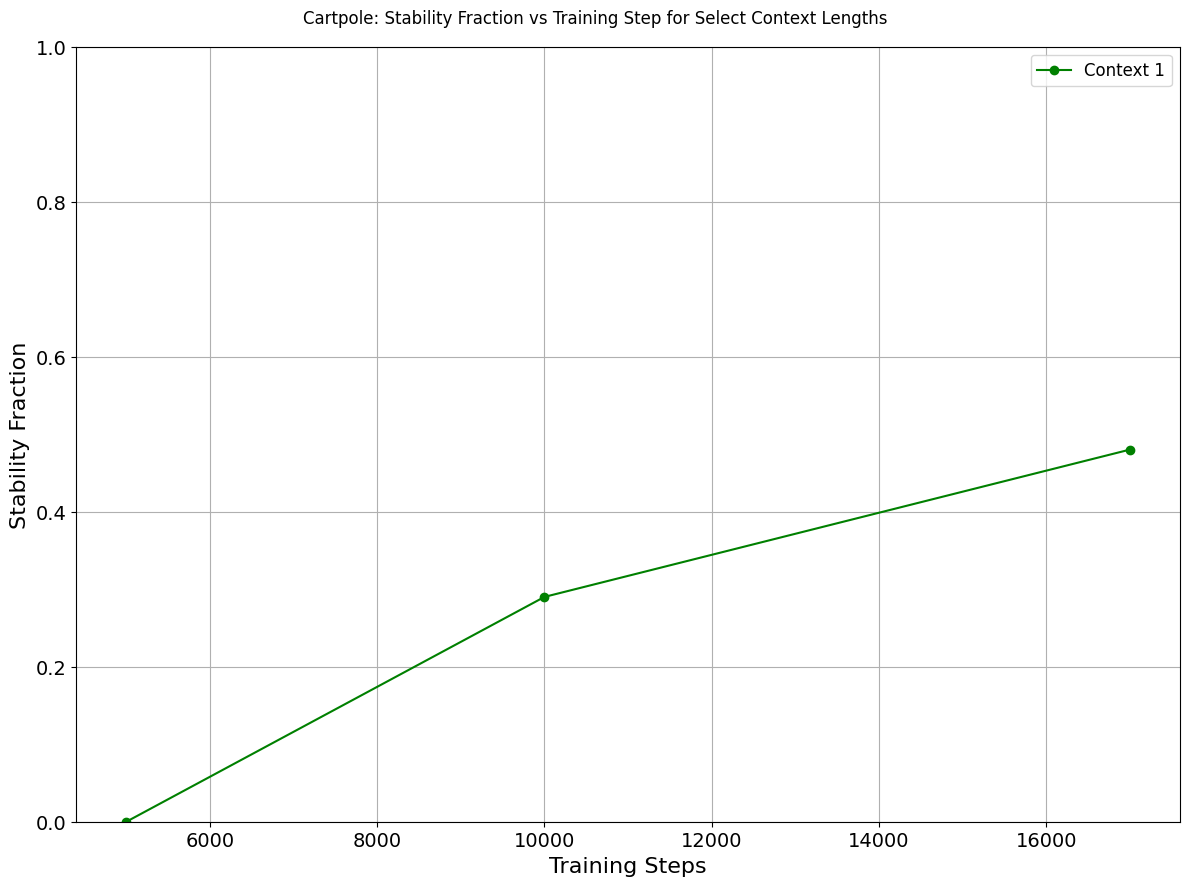

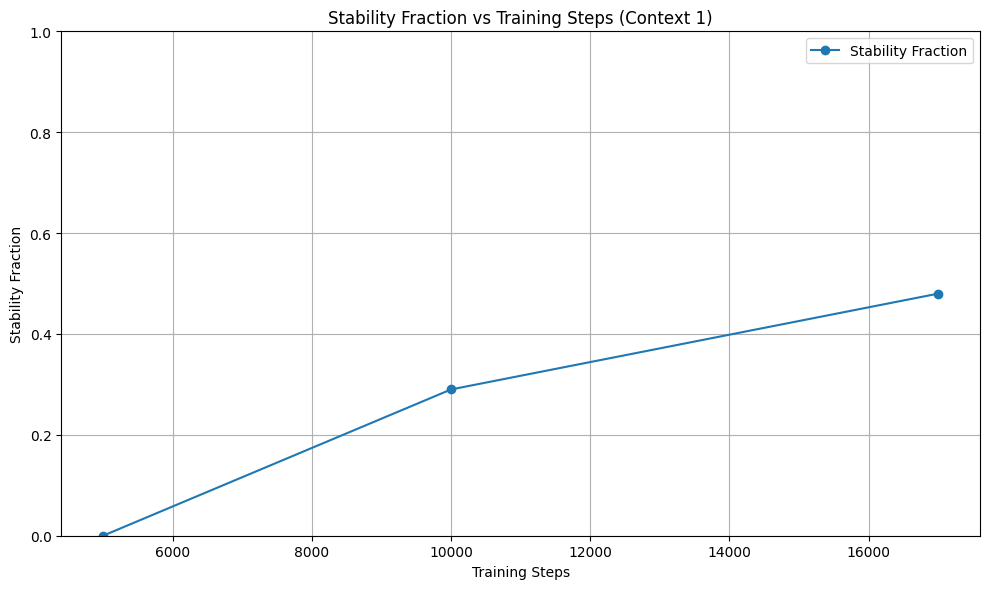

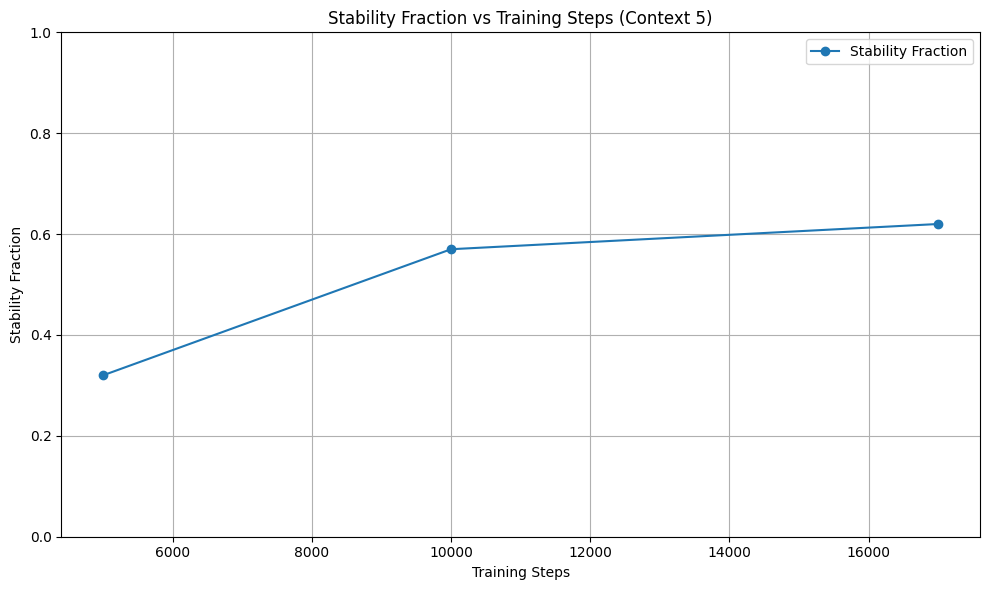

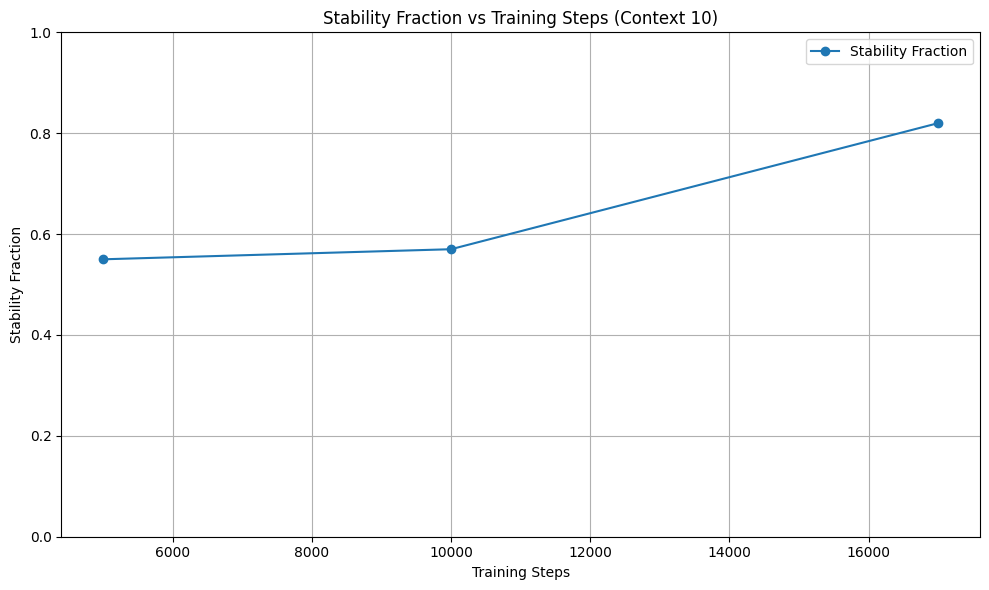

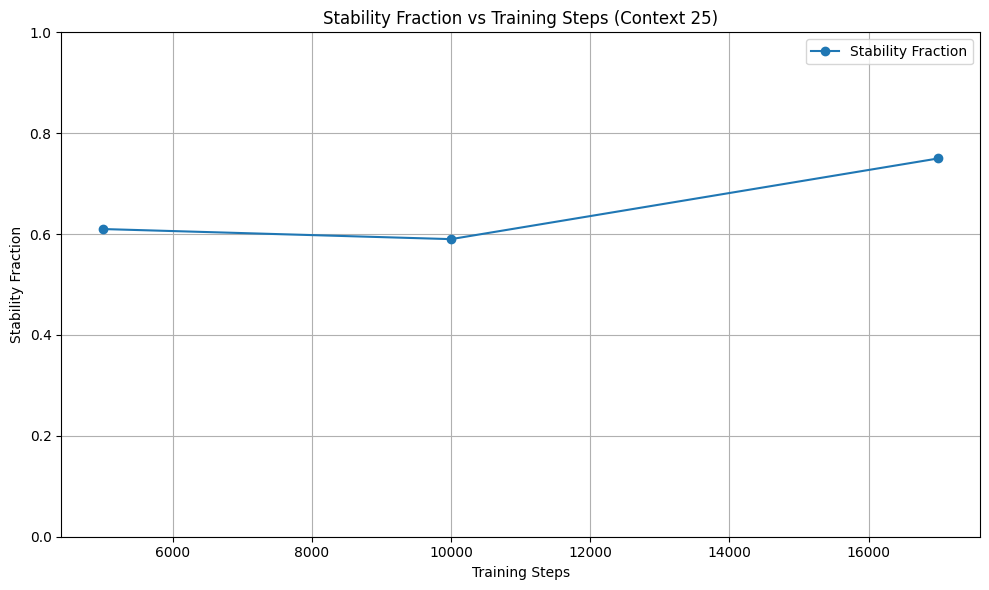

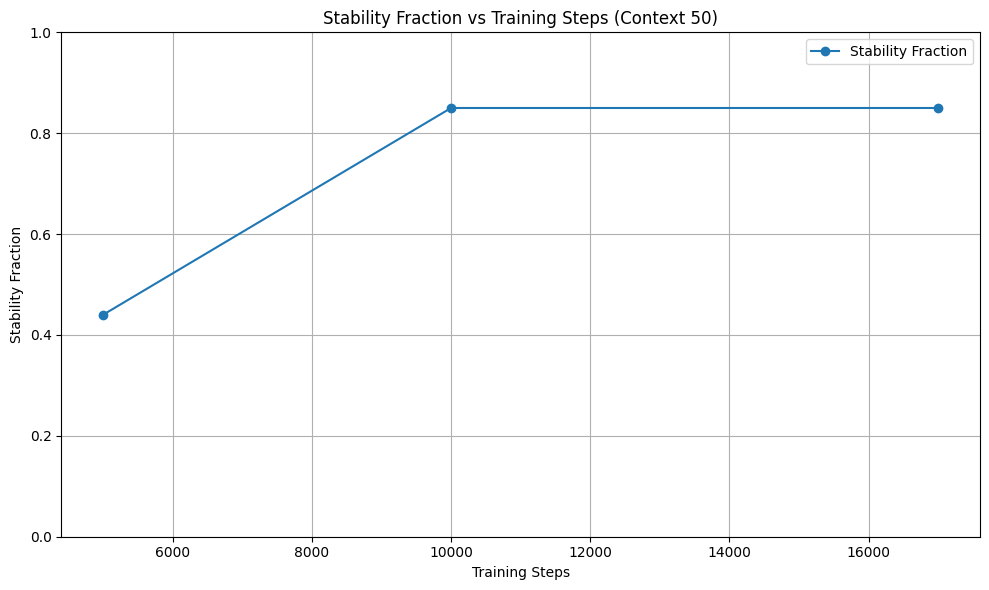

In [6]:
# steps_list = [200, 400, 2000, 5000, 10000, 17000, 30000, 60000, 100000, 200000]
# steps_list = [10000, 17000, 30000, 60000, 100000, 200000]
steps_list = [5000, 10000, 17000]

# context_lengths = [1, 10, 20, 30, 40, 50]
# contexts = [1, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
contexts = [1, 5, 10, 25, 50]
mode = "indistr" # "indistr" or "ood"

# context_lengths = [20]


results = {}
metrics = ['stability', 'swinging', 'energy', 'stability_fraction']
for metric in metrics:
    results[metric] = {}

# # create prediction dictionary
# predicted_states_dict = {step: {} for step in steps_list}
# for step in steps_list:
#     data_path = f'inference_run/mse_control_{step}_{model_run_id}/results_maxcontext50_numpends{numberpend}_indistr_alexcode.pkl'
#     link_lengths1, link_lengths2, link_masses1, link_masses2, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
#     print(f"Loaded data from {data_path}")
#     for context in context_lengths:
#         pred_traj = torch.stack(phase_data[context])
#         predicted_states_dict[step][context] = pred_traj

# print(f"predicted_states_dict keys: {predicted_states_dict.keys()}")
# print(f"predicted_states_dict[{steps_list[0]}] keys: {predicted_states_dict[steps_list[0]].keys()}")


# just context 30 for now
# context = contexts[0]
# for context in contexts:
# count = 0
# fig_select, ax_select = plt.subplots(2, 2, figsize=(12, 9))
fig_select, ax_select = plt.subplots(figsize=(12, 9))
colors = ['green', 'orange', 'purple', 'brown']
# ax_select = ax_select.flatten()
select_contexts = [1, 6, 12, 20]
composite_images = []
from tqdm import tqdm
for context in tqdm(contexts, desc="Contexts"):
    print(f"Evaluating metrics for context length: {context}")
    for step in steps_list:
        data_path = f'inference_run/mse_control_{step}_{model_run_id}/results_maxcontext50_numpends{numberpend}_{mode}_alexcode.pkl'
        # data_path = f'inference_run/nozerodyntrain_zerodyninf_{step}_{model_run_id}/results_maxcontext50_numpends{numberpend}_{mode}_alexcode.pkl'
        cartmasses, polemasses, polelengths, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
        # print(f"Loaded data from {data_path}")

        pred_traj = torch.stack(phase_data[context])
        
        stability_metrics, swinging_metrics = evaluate_metrics(pred_traj, torch.stack(controls_data[context])[:,:,-1], K=100)
        
        ground_truth_data_controls = data_and_controls[0]
        ground_truth_control_labels = [ground_truth_data_controls[i][1][:,1][:-1] for i in range(len(ground_truth_data_controls))]
        true_traj = [ground_truth_data_controls[i][0] for i in range(len(ground_truth_data_controls))]
        true_traj = np.stack(true_traj)
        # import pdb; pdb.set_trace()
        # energy_metric = energy_metric_batch(torch.tensor(true_traj), pred_traj, np.stack(link_lengths1), np.stack(link_lengths2), np.stack(link_masses1), np.stack(link_masses2))
        # import pdb; pdb.set_trace()
        # swinging_compare_metrics = swinging_difference_batch(np.stack(ground_truth_control_labels), torch.stack(controls_data[context])[:,:,-1])

        stability_fraction, stable_idxes = stability_fraction_batch(pred_traj, K=10, threshold=0.3)
        # plot trajs for debugging
        # plt.figure()
        # count = 0
        # for i in range(pred_traj.shape[0]):
        #     if np.all(np.abs(np.sin(pred_traj[i,-10:,0].cpu().numpy())) < 0.2) and np.all(np.abs(np.sin(pred_traj[i,-10:,1].cpu().numpy())) < 0.3):
        #         count += 1
        #         plt.plot(np.sin(pred_traj[i,:,0].cpu().numpy()), label=f'Pred {i}', alpha=0.5, color='blue')
        #     else:
        #         plt.plot(np.sin(pred_traj[i,:,0].cpu().numpy()), label=f'Pred {i}', alpha=0.5, color='red')
            
        # print(f"Number of stable trajectories (context {context}, step {step}): {count} out of {pred_traj.shape[0]}")
        # plt.title(f'Step {step} Predicted Trajectories (Context {context})')
        # plt.show()

        # import pdb; pdb.set_trace()

        median_stability = np.median(stability_metrics)
        mean_stability = np.mean(stability_metrics)
        twentyfifth_percentile = np.percentile(stability_metrics, 25)
        seventyfifth_percentile = np.percentile(stability_metrics, 75)

        median_swinging = np.median(swinging_metrics)
        mean_swinging = np.mean(swinging_metrics)
        twentyfifth_swinging = np.percentile(swinging_metrics, 25)
        seventyfifth_swinging = np.percentile(swinging_metrics, 75)

        # median_energy = np.median(energy_metric)
        # mean_energy = np.mean(energy_metric)
        # twentyfifth_energy = np.percentile(energy_metric, 25)
        # seventyfifth_energy = np.percentile(energy_metric, 75)

        results['stability'][step] = {
            'median': median_stability,
            '25th_percentile': twentyfifth_percentile,
            '75th_percentile': seventyfifth_percentile,
            'mean': mean_stability
        }

        results['swinging'][step] = {
            'median': median_swinging,
            '25th_percentile': twentyfifth_swinging,
            '75th_percentile': seventyfifth_swinging,
            'mean': mean_swinging

        }

        # results['energy'][step] = {
        #     'median': median_energy,
        #     '25th_percentile': twentyfifth_energy,
        #     '75th_percentile': seventyfifth_energy,
        #     'mean': mean_energy
        # }
        results['stability_fraction'][step] = stability_fraction

        # results['swinging_compare'][step] = {
        #     'median': np.median(swinging_compare_metrics),
        #     '25th_percentile': np.percentile(swinging_compare_metrics, 25),
        #     '75th_percentile': np.percentile(swinging_compare_metrics, 75),
        #     'mean': np.mean(swinging_compare_metrics)
        # }

    # visulaize results
    import matplotlib.pyplot as plt
    import pandas as pd

    # prepare data for plotting

    data = []


    for step in steps_list:
        for metric in metrics:
            # print(f"step: {step}, metric: {metric}")
            if metric == 'stability_fraction':
                data.append({
                    'metric': metric,
                    'step': step,
                    'value': results[metric][step]
                })
            else:
                # data.append({
                #     'metric': metric,
                #     'step': step,
                #     'median': results[metric][step]['median'],
                #     'percentile_25': results[metric][step]['25th_percentile'],
                #     'percentile_75': results[metric][step]['75th_percentile'],
                #     'mean': results[metric][step]['mean']

                # })
                pass

    # # visualize results
    # fig1, ax1 = plt.subplots(figsize=(10, 6))
    # fig2, ax2 = plt.subplots(figsize=(10, 6))
    # fig3, ax3 = plt.subplots(figsize=(10, 6))
    # fig4, ax4 = plt.subplots(figsize=(10, 6))
    df = pd.DataFrame(data)
    df = df.sort_values(by='step')

    # for metric, ax in zip(metrics, [ax1, ax2, ax3, ax4]):
    #     metric_data = df[df['metric'] == metric]
    #     if metric == 'stability_fraction':
    #         ax.plot(metric_data['step'], metric_data['value'], label='Stability Fraction', marker='o')
    #         # ax.set_title(f'Stability Fraction vs Training Steps')
    #         ax.set_xlabel('Training Steps', fontsize=16)
    #         ax.set_ylabel('Stability Fraction', fontsize=16)
    #         ax.tick_params(axis='x', labelsize=14)
    #         ax.tick_params(axis='y', labelsize=14)
    #         ax.set_ylim(0, 1)
    #         ax.legend(fontsize=12)
    #         ax.grid(True)
    #         plt.tight_layout()
    #         continue
    #     else:
    #         # ax.plot(metric_data['step'], metric_data['median'], label='Median', marker='o')
    #         # ax.plot(metric_data['step'], metric_data['mean'], label='Mean', marker='*', linestyle='--')
    #         # ax.fill_between(metric_data['step'], metric_data['percentile_25'], metric_data['percentile_75'], color='b', alpha=0.2, label='25th-75th Percentile')
    #         # ax.set_title(f'{metric.capitalize()} Metric over Training Steps')
    #         # ax.set_xlabel('Training Steps')
    #         # ax.set_ylabel(f'{metric.capitalize()} Metric')
    #         # ax.legend()
    #         # ax.grid(True)
    #         # plt.tight_layout()
    #         pass
    # plt.show()

    # create plot with subplots for each metric to save
    # fig_all, ax_all = plt.subplots(1, 4, figsize=(18, 4))
    # fig_all, ax_all = plt.subplots(1, 1, figsize=(20, 5))
    fig = plt.figure(figsize=(10, 6))
    # for metric, ax in zip(metrics, ax_all):
    for metric in metrics:
        metric_data = df[df['metric'] == metric]
        if metric == 'stability_fraction':
            # ax.plot(metric_data['step'], metric_data['value'], label='Stability Fraction', marker='o')
            # ax.set_title(f'Stability Fraction over Training Steps')
            # ax.set_xlabel('Training Steps')
            # ax.set_ylabel('Stability Fraction')
            # ax.set_ylim(0, 1)
            # ax.legend()
            # ax.grid(True)
            # plt.tight_layout()
            plt.plot(metric_data['step'], metric_data['value'], label='Stability Fraction', marker='o')
            plt.title(f'Stability Fraction vs Training Steps (Context {context})')
            plt.xlabel('Training Steps')
            plt.ylabel('Stability Fraction')
            plt.ylim(0, 1)
            plt.legend()
            plt.grid(True)
            plt.tight_layout()

            if context in select_contexts:
                # ax_select[select_contexts.index(context)].plot(metric_data['step'], metric_data['value'], label='Stability Fraction', marker='o')
                ax_select.plot(metric_data['step'], metric_data['value'], label=f'Context {context}', marker='o', color=colors[select_contexts.index(context)])
                # ax_select[select_contexts.index(context)].set_title(f'Stability Fraction vs Training Steps (Context {context})')
                # ax_select[select_contexts.index(context)].set_xlabel('Training Steps')
                # ax_select[select_contexts.index(context)].set_ylabel('Stability Fraction')
                # ax_select[select_contexts.index(context)].set_ylim(0, 1)
                # ax_select[select_contexts.index(context)].legend()
                # ax_select[select_contexts.index(context)].grid(True)
                ax_select.set_xlabel('Training Steps', fontsize=16)
                ax_select.set_ylabel('Stability Fraction', fontsize=16)
                ax_select.set_ylim(0, 1)
                ax_select.tick_params(axis='x', labelsize=14)
                ax_select.tick_params(axis='y', labelsize=14)
                ax_select.legend(fontsize=12)
                ax_select.grid(True)
                plt.tight_layout()

            continue
        else:
            # ax.plot(metric_data['step'], metric_data['median'], label='Median', marker='o')
            # ax.plot(metric_data['step'], metric_data['mean'], label='Mean', marker='*', linestyle='--')
            # ax.fill_between(metric_data['step'], metric_data['percentile_25'], metric_data['percentile_75'], color='b', alpha=0.2, label='25th-75th Percentile')
            # ax.set_title(f'{metric.capitalize()} Metric over Training Steps')
            # ax.set_xlabel('Training Steps')
            # ax.set_ylabel(f'{metric.capitalize()} Metric')
            # ax.legend()
            # ax.grid(True)
            pass
    plt.tight_layout()
    # plt.show()

    fig_select.suptitle('Cartpole: Stability Fraction vs Training Step for Select Context Lengths')
    # fig_select.tight_layout(rect=[0, 0, 1, 0.95])
    fig_select.tight_layout()
    output_dir = f'evaluate_inference_checkpoint_{model_run_id}_100systems_mode{mode}'
    # os.makedirs(output_dir, exist_ok=True)
    # fig_select.savefig(os.path.join(output_dir, f'stability_fraction_select_contexts_100systems_mode{mode}.png'))
    # fig_select.savefig(os.path.join(output_dir, f'stability_fraction_select_contexts_100systems_mode{mode}.pdf'), format='pdf', bbox_inches='tight')
    # plt.close(fig_select)

    ### sanity check, for systems that stabilized, see if considerable amt of time spend in lqr mode
    ### null model: see how ground truth controller performs if small noise is added to swingup as well as lqr (fair model to compare gpt to)

    # if context in select_contexts:
    #     figure, axis = plt.subplots(figsize=(10, 6))
    #     for metric in metrics:
    #         metric_data = df[df['metric'] == metric]
    #         if metric == 'stability_fraction':
    #             axis.plot(metric_data['step'], metric_data['value'], label='Stability Fraction', marker='o')
    #             axis.set_title(f'Stability Fraction over Training Steps (Context {context})')
    #             axis.set_xlabel('Training Steps')
    #             axis.set_ylabel('Stability Fraction')
    #             axis.set_ylim(0, 1)
    #             axis.legend()
    #             axis.grid(True)
    #             plt.tight_layout()
    #     plt.suptitle(f'Stability Fraction across Context Lengths (Context {context})', y=1.02)
    #     plt.tight_layout()
    #     composite_images.append(figure)

    # create folder and save subplots
    # output_dir = f'evaluate_inference_checkpoint_{model_run_id}_100systems'
    os.makedirs(output_dir, exist_ok=True)
    # folder = f"context{context}_100systems"
    # os.makedirs(os.path.join(output_dir, folder), exist_ok=True)
    # fig.savefig(os.path.join(output_dir, f'all_metrics_context{context}_100systems_mode{mode}.png'))
    
    # fig.savefig(os.path.join(output_dir, f'stability_fraction_context{context}_100systems_mode{mode}.pdf'), format='pdf', bbox_inches='tight')



    # ### plot select contexts on same plot for comparison
    # select_contexts = [1, 6, 12, 20]
    # plt.figure(figsize=(10, 6))

    # if context in select_contexts:
    #     plt.subplot(2, 2, select_contexts.index(context)+1)
    #     for metric in metrics:
    #         metric_data = df[df['metric'] == metric]
    #         if metric == 'stability_fraction':
    #             plt.plot(metric_data['step'], metric_data['value'], label='Stability Fraction', marker='o')
    #             plt.title(f'Stability Fraction over Training Steps (Context {context})')
    #             plt.xlabel('Training Steps')
    #             plt.ylabel('Stability Fraction')
    #             plt.ylim(0, 1)
    #             plt.legend()
    #             plt.grid(True)
    #             plt.tight_layout()
    # plt.suptitle('Stability Fraction across Context Lengths', y=1.02)
    # plt.tight_layout()
    # plt.savefig(os.path.join(output_dir, f'stability_fraction_select_contexts_100systems.png'))
    # plt.show()
                


        





In [7]:
# # visulaize results
# import matplotlib.pyplot as plt
# import pandas as pd

# # prepare data for plotting

# data = []


# for step in steps_list:
#     for metric in metrics:
#         # print(f"step: {step}, metric: {metric}")
#         if metric == 'stability_fraction':
#             data.append({
#                 'metric': metric,
#                 'step': step,
#                 'value': results[metric][step]
#             })
#         else:
#             # data.append({
#             #     'metric': metric,
#             #     'step': step,
#             #     'median': results[metric][step]['median'],
#             #     'percentile_25': results[metric][step]['25th_percentile'],
#             #     'percentile_75': results[metric][step]['75th_percentile'],
#             #     'mean': results[metric][step]['mean']

#             # })
#             pass

# # visualize results
# fig1, ax1 = plt.subplots(figsize=(10, 6))
# fig2, ax2 = plt.subplots(figsize=(10, 6))
# fig3, ax3 = plt.subplots(figsize=(10, 6))
# fig4, ax4 = plt.subplots(figsize=(10, 6))
# df = pd.DataFrame(data)
# df = df.sort_values(by='step')

# for metric, ax in zip(metrics, [ax1, ax2, ax3, ax4]):
#     metric_data = df[df['metric'] == metric]
#     if metric == 'stability_fraction':
#         ax.plot(metric_data['step'], metric_data['value'], label='Stability Fraction', marker='o')
#         ax.set_title(f'Stability Fraction over Training Steps')
#         ax.set_xlabel('Training Steps')
#         ax.set_ylabel('Stability Fraction')
#         ax.set_ylim(0, 1)
#         ax.legend()
#         ax.grid(True)
#         plt.tight_layout()
#         continue
#     else:
#         # ax.plot(metric_data['step'], metric_data['median'], label='Median', marker='o')
#         # ax.plot(metric_data['step'], metric_data['mean'], label='Mean', marker='*', linestyle='--')
#         # ax.fill_between(metric_data['step'], metric_data['percentile_25'], metric_data['percentile_75'], color='b', alpha=0.2, label='25th-75th Percentile')
#         # ax.set_title(f'{metric.capitalize()} Metric over Training Steps')
#         # ax.set_xlabel('Training Steps')
#         # ax.set_ylabel(f'{metric.capitalize()} Metric')
#         # ax.legend()
#         # ax.grid(True)
#         # plt.tight_layout()
#         pass
# plt.show()

# # create plot with subplots for each metric to save
# # fig_all, ax_all = plt.subplots(1, 4, figsize=(18, 4))
# # fig_all, ax_all = plt.subplots(1, 1, figsize=(20, 5))
# fig = plt.figure(figsize=(10, 6))
# # for metric, ax in zip(metrics, ax_all):
# for metric in metrics:
#     metric_data = df[df['metric'] == metric]
#     if metric == 'stability_fraction':
#         # ax.plot(metric_data['step'], metric_data['value'], label='Stability Fraction', marker='o')
#         # ax.set_title(f'Stability Fraction over Training Steps')
#         # ax.set_xlabel('Training Steps')
#         # ax.set_ylabel('Stability Fraction')
#         # ax.set_ylim(0, 1)
#         # ax.legend()
#         # ax.grid(True)
#         # plt.tight_layout()
#         plt.plot(metric_data['step'], metric_data['value'], label='Stability Fraction', marker='o')
#         plt.title(f'Stability Fraction over Training Steps (Context {context})')
#         plt.xlabel('Training Steps')
#         plt.ylabel('Stability Fraction')
#         plt.ylim(0, 1)
#         plt.legend()
#         plt.grid(True)
#         plt.tight_layout()
#         continue
#     else:
#         # ax.plot(metric_data['step'], metric_data['median'], label='Median', marker='o')
#         # ax.plot(metric_data['step'], metric_data['mean'], label='Mean', marker='*', linestyle='--')
#         # ax.fill_between(metric_data['step'], metric_data['percentile_25'], metric_data['percentile_75'], color='b', alpha=0.2, label='25th-75th Percentile')
#         # ax.set_title(f'{metric.capitalize()} Metric over Training Steps')
#         # ax.set_xlabel('Training Steps')
#         # ax.set_ylabel(f'{metric.capitalize()} Metric')
#         # ax.legend()
#         # ax.grid(True)
#         pass
# plt.tight_layout()
# plt.show()

# ### sanity check, for systems that stabilized, see if considerable amt of time spend in lqr mode
# ### null model: see how ground truth controller performs if small noise is added to swingup as well as lqr (fair model to compare gpt to)

# # create folder and save subplots
# output_dir = f'evaluate_inference_checkpoint_{model_run_id}_100systems'
# os.makedirs(output_dir, exist_ok=True)
# # folder = f"context{context}_100systems"
# # os.makedirs(os.path.join(output_dir, folder), exist_ok=True)
# fig.savefig(os.path.join(output_dir, f'all_metrics_context{context}_100systems.png'))



In [8]:
# # create prediction dictionary
# predicted_states_dict = {step: {} for step in steps_list}
# # for step in steps_list:
# for step in tqdm(steps_list, desc="Steps"):
#     data_path = f'inference_run/mse_control_{step}_{model_run_id}/results_maxcontext30_numpends{numberpend}_indistr_alexcode.pkl'
#     cartmasses, polemasses, polelengths, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
#     # print(f"Loaded data from {data_path}")
#     # for context in context_lengths:
#     for context in contexts:
#         pred_traj = torch.stack(phase_data[context])
#         predicted_states_dict[step][context] = pred_traj

# print(f"predicted_states_dict keys: {predicted_states_dict.keys()}")
# print(f"predicted_states_dict[{steps_list[0]}] keys: {predicted_states_dict[steps_list[0]].keys()}")

# fracs = {}
# # for step in steps_list:
# for step in tqdm(steps_list, desc="Steps"):
#     # for context in context_lengths:
#     stability_fraction_all_contexts = stability_fraction_all_contexts_batch(predicted_states_dict[step], K=20, threshold=0.3)
#     fracs[step] = stability_fraction_all_contexts
#     # print(f"Step: {step}, Stability Fraction (any context): {stability_fraction_all_contexts}")

In [9]:
# # Plot and save results
# fig_all_contexts = plt.figure(figsize=(10, 6))
# plt.plot(list(fracs.keys()), list(fracs.values()), marker='o')
# plt.title('Stability Fraction (any context) over Training Steps')
# plt.xlabel('Training Steps')
# plt.ylabel('Stability Fraction (any context)')
# plt.ylim(0, 1)
# plt.grid(True)
# plt.tight_layout()
# plt.show()
# fig_all_contexts.savefig(os.path.join(output_dir, f'stability_fraction_any_context_100systems.png'))

In [10]:
# steps_list2 = [1600]
# steps_list2 = [200, 400, 2000, 5000, 10000, 17000, 30000, 60000, 100000, 200000]
# steps_list2 = [10000, 17000, 30000, 60000, 100000, 200000]
steps_list2 = [5000, 10000, 17000]
# contexts = [1, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
contexts = [1, 5, 10, 25, 50]
# mode = "indistr" # "indistr" or "ood"
modes = ["indistr", "ood_hard", "ood_easy"] # "indistr" or "ood_hard"
file_modes = ["indistr"]
# modes = ["indistr", "ood"] # "indistr" or "ood_hard"

results2 = {}
metrics2 = ['stability', 'swinging', 'energy', 'stability_fraction', 'stability_idxes', 'stability_idxes_gt']
for metric in metrics2:
    results2[metric] = {}

# for step in steps_list2:
for step in tqdm(steps_list2, desc="Steps2"):
    # for ctx in context_lengths:
    for ctx in contexts:
        for mode in modes:
            if mode == "indistr" or mode == "ood_hard": # or mode == "ood_easy":
                data_path = f'inference_run/mse_control_{step}_{model_run_id}/results_maxcontext50_numpends{numberpend}_{mode}_alexcode.pkl'
            else:
                data_path = f'inference_run/mse_control_easy_{step}_{model_run_id}/results_maxcontext50_numpends{numberpend}_{mode}_alexcode.pkl'
            
            # ## for nozerodyntrain_zerodyninf
            # data_path = f'inference_run/nozerodyntrain_zerodyninf_{step}_{model_run_id}/results_maxcontext50_numpends{numberpend}_{mode}_alexcode.pkl'
            
            cartmasses, polemasses, polelengths, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
            print(f"Loaded data from {data_path}")
            ground_truth_data_controls = data_and_controls[0]
            gt_trajs = []
            gt_ctrls = []
            for i in range(len(ground_truth_data_controls)):
                gt_trajs.append(ground_truth_data_controls[i][0])
                gt_ctrls.append(ground_truth_data_controls[i][1])
            gt_trajs = np.array(gt_trajs)
            gt_trajs = torch.tensor(gt_trajs, dtype=torch.float32)
            gt_ctrls = np.array(gt_ctrls)
            gt_ctrls = torch.tensor(gt_ctrls, dtype=torch.float32)

            pred_traj = torch.stack(phase_data[ctx])
            
            stability_metrics, swinging_metrics = evaluate_metrics(pred_traj, torch.stack(controls_data[ctx])[:,:,-1], K=100)

            stability_fraction, stable_idxes = stability_fraction_batch(pred_traj, K=10, threshold=0.3)
            stability_fraction_gt, stable_idxes_gt = stability_fraction_batch(gt_trajs, K=10, threshold=0.3)
    
            median_stability = np.median(stability_metrics)
            mean_stability = np.mean(stability_metrics)
            twentyfifth_percentile = np.percentile(stability_metrics, 25)
            seventyfifth_percentile = np.percentile(stability_metrics, 75)

            median_swinging = np.median(swinging_metrics)
            mean_swinging = np.mean(swinging_metrics)
            twentyfifth_swinging = np.percentile(swinging_metrics, 25)
            seventyfifth_swinging = np.percentile(swinging_metrics, 75)

            # results2['stability'][(step, ctx)] = {
            #     'median': median_stability,
            #     '25th_percentile': twentyfifth_percentile,
            #     '75th_percentile': seventyfifth_percentile,
            #     'mean': mean_stability
            # }

            # results2['swinging'][(step, ctx)] = {
            #     'median': median_swinging,
            #     '25th_percentile': twentyfifth_swinging,
            #     '75th_percentile': seventyfifth_swinging,
            #     'mean': mean_swinging
            # }
            results2['stability_fraction'][(step, ctx, mode)] = stability_fraction
            results2['stability_idxes'][(step, ctx, mode)] = stable_idxes
            results2['stability_idxes_gt'][(step, ctx, mode)] = stable_idxes_gt

Steps2:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded data from inference_run/mse_control_5000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_5000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_ood_hard_alexcode.pkl
Loaded data from inference_run/mse_control_easy_5000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_ood_easy_alexcode.pkl
Loaded data from inference_run/mse_control_5000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_5000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_ood_hard_alexcode.pkl
Loaded data from inference_run/mse_control_easy_5000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_ood_easy_alexcode.pkl
Loaded data from inference_run/mse_control_5000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data f

Steps2:  33%|███▎      | 1/3 [00:03<00:06,  3.26s/it]

Loaded data from inference_run/mse_control_easy_5000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_ood_easy_alexcode.pkl
Loaded data from inference_run/mse_control_10000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_10000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_ood_hard_alexcode.pkl
Loaded data from inference_run/mse_control_easy_10000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_ood_easy_alexcode.pkl
Loaded data from inference_run/mse_control_10000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_10000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_ood_hard_alexcode.pkl
Loaded data from inference_run/mse_control_easy_10000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_ood_easy_alexcode.pkl
L

Steps2:  67%|██████▋   | 2/3 [00:06<00:03,  3.14s/it]

Loaded data from inference_run/mse_control_17000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_17000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_ood_hard_alexcode.pkl
Loaded data from inference_run/mse_control_easy_17000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_ood_easy_alexcode.pkl
Loaded data from inference_run/mse_control_17000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_17000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_ood_hard_alexcode.pkl
Loaded data from inference_run/mse_control_easy_17000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_ood_easy_alexcode.pkl
Loaded data from inference_run/mse_control_17000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded

Steps2: 100%|██████████| 3/3 [00:09<00:00,  3.05s/it]

Loaded data from inference_run/mse_control_easy_17000_fc5cb0fe-d4c6-4fba-8196-01a37d611194/results_maxcontext50_numpends100_ood_easy_alexcode.pkl


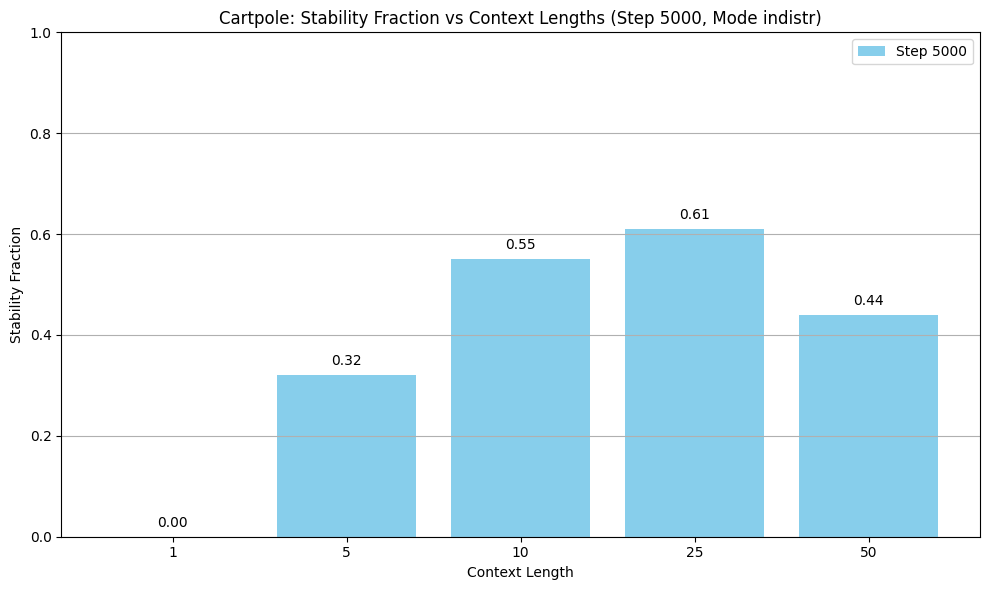

Saved line plot to test_plots_cartpole_temp/stability_fraction_vs_context_length_line_step5000_100systems_modeindistr.png
Saved bar plot to test_plots_cartpole_temp/stability_fraction_vs_context_length_bar_step5000_100systems_modeindistr.png


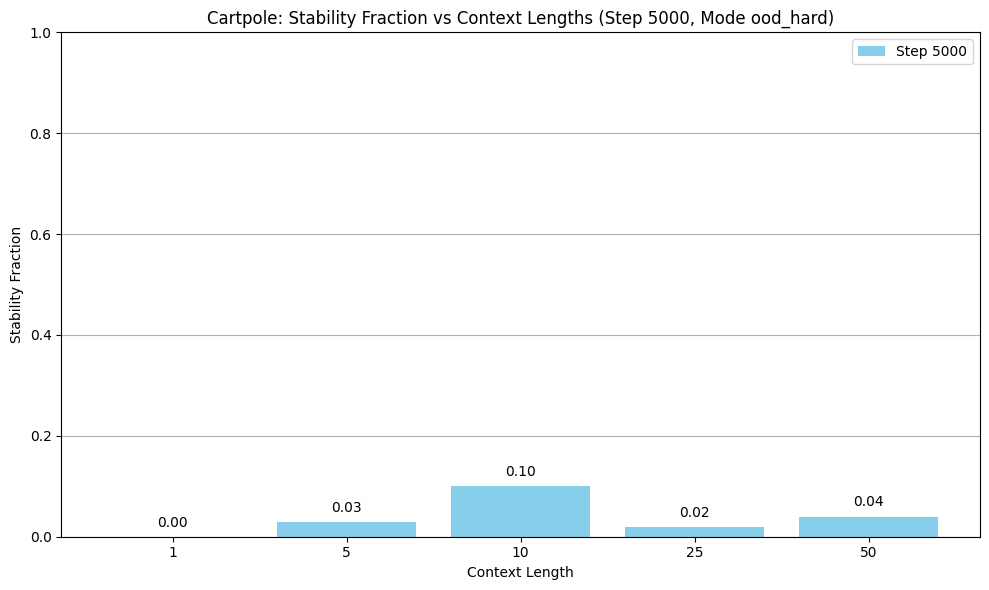

Saved line plot to test_plots_cartpole_temp/stability_fraction_vs_context_length_line_step5000_100systems_modeood_hard.png
Saved bar plot to test_plots_cartpole_temp/stability_fraction_vs_context_length_bar_step5000_100systems_modeood_hard.png


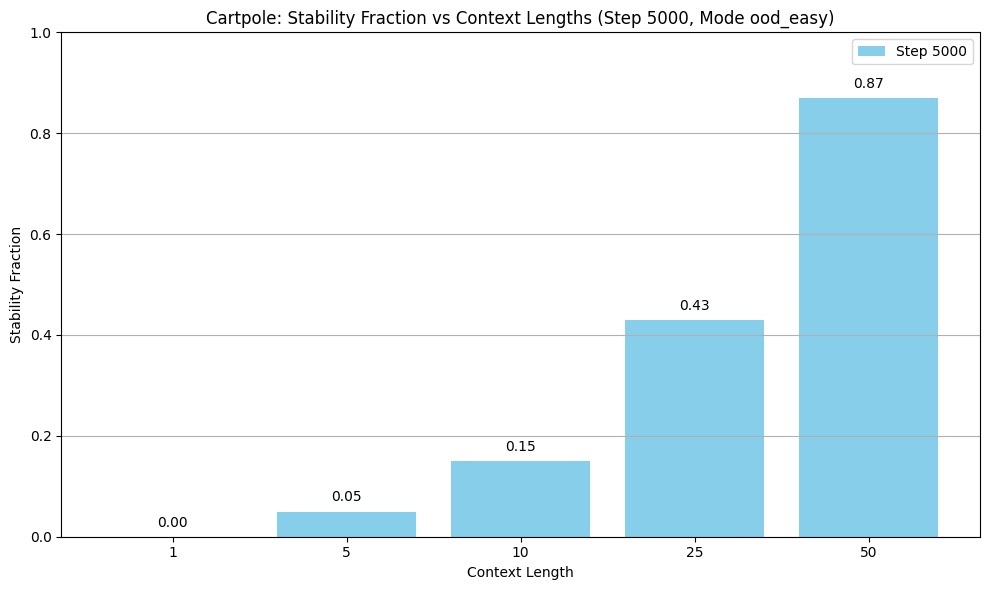

Saved line plot to test_plots_cartpole_temp/stability_fraction_vs_context_length_line_step5000_100systems_modeood_easy.png
Saved bar plot to test_plots_cartpole_temp/stability_fraction_vs_context_length_bar_step5000_100systems_modeood_easy.png


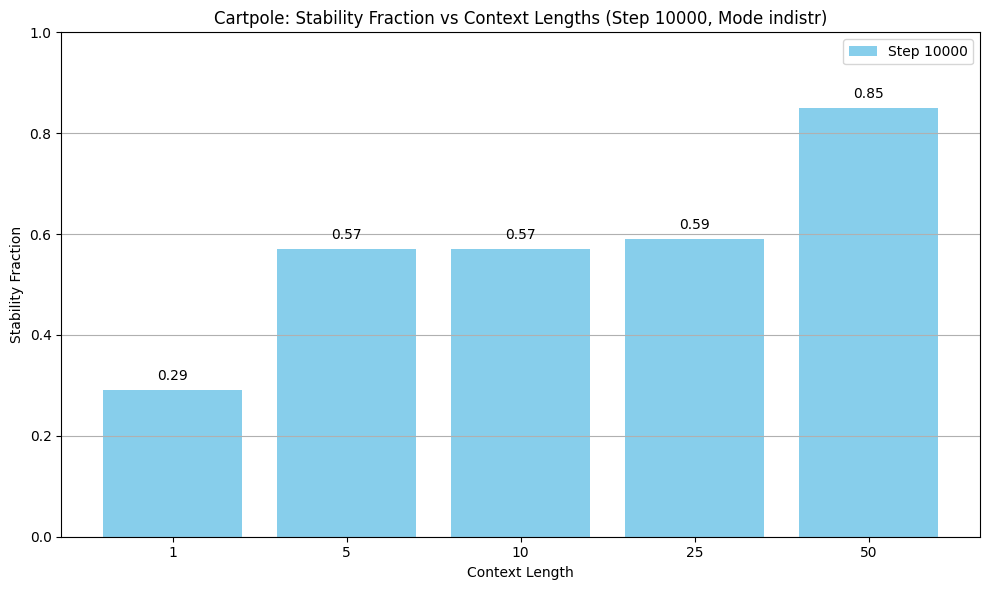

Saved line plot to test_plots_cartpole_temp/stability_fraction_vs_context_length_line_step10000_100systems_modeindistr.png
Saved bar plot to test_plots_cartpole_temp/stability_fraction_vs_context_length_bar_step10000_100systems_modeindistr.png


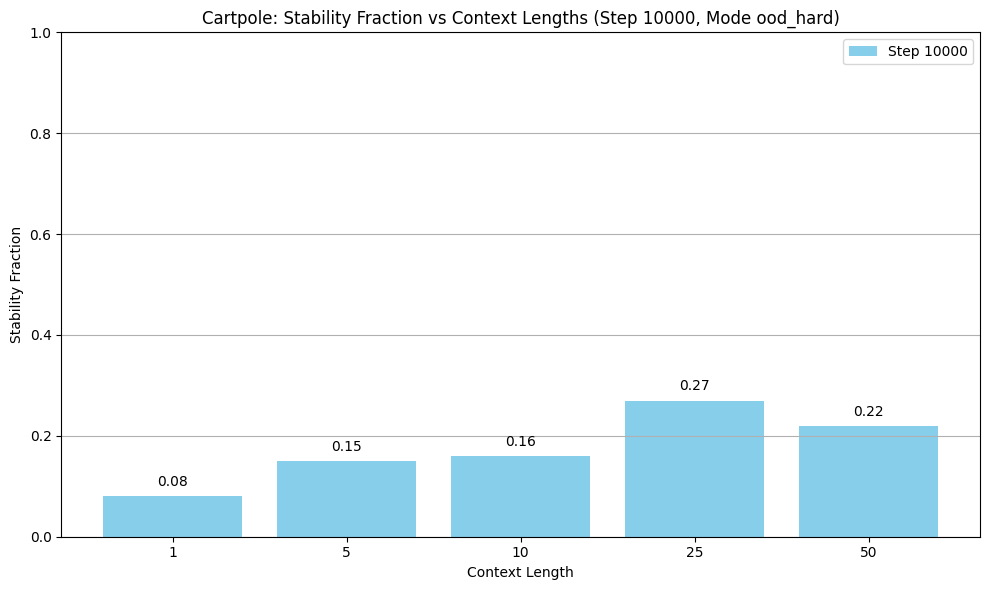

Saved line plot to test_plots_cartpole_temp/stability_fraction_vs_context_length_line_step10000_100systems_modeood_hard.png
Saved bar plot to test_plots_cartpole_temp/stability_fraction_vs_context_length_bar_step10000_100systems_modeood_hard.png


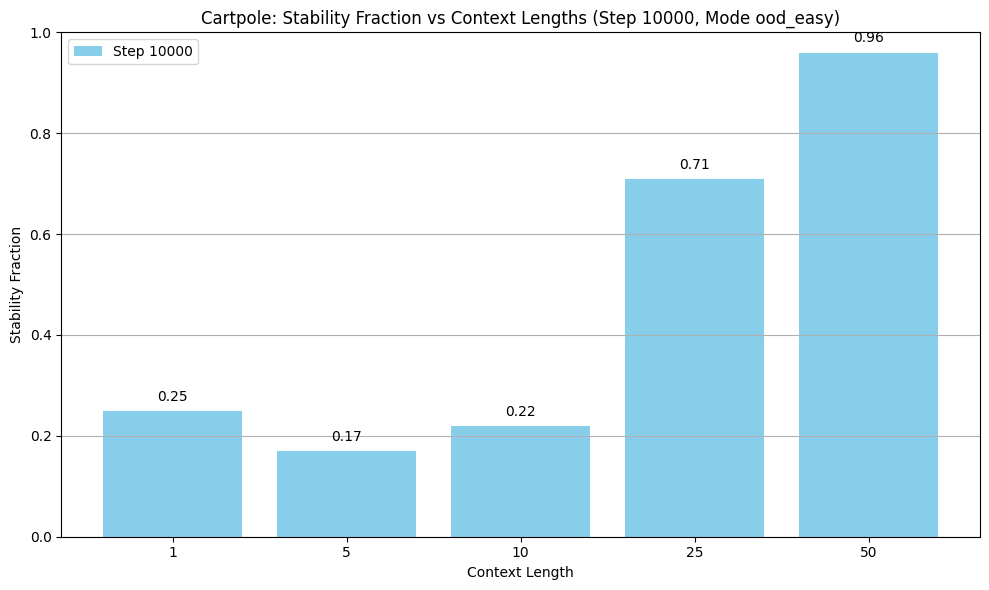

Saved line plot to test_plots_cartpole_temp/stability_fraction_vs_context_length_line_step10000_100systems_modeood_easy.png
Saved bar plot to test_plots_cartpole_temp/stability_fraction_vs_context_length_bar_step10000_100systems_modeood_easy.png


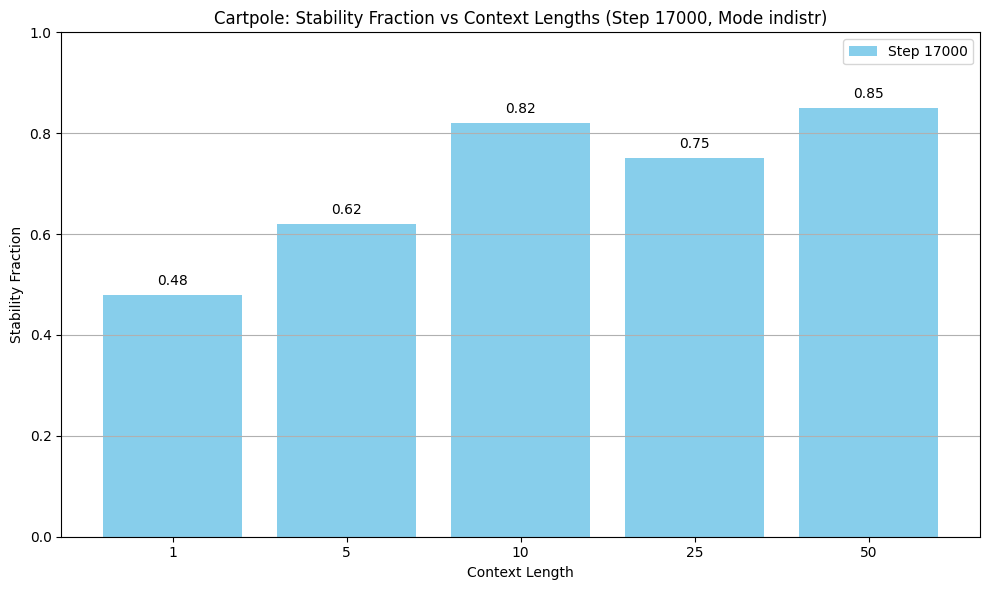

Saved line plot to test_plots_cartpole_temp/stability_fraction_vs_context_length_line_step17000_100systems_modeindistr.png
Saved bar plot to test_plots_cartpole_temp/stability_fraction_vs_context_length_bar_step17000_100systems_modeindistr.png


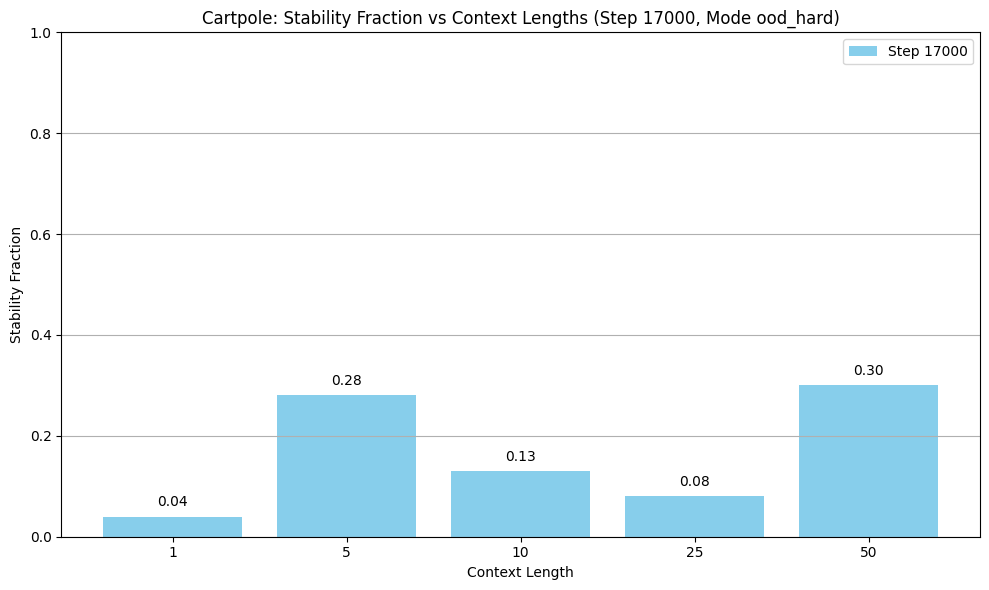

Saved line plot to test_plots_cartpole_temp/stability_fraction_vs_context_length_line_step17000_100systems_modeood_hard.png
Saved bar plot to test_plots_cartpole_temp/stability_fraction_vs_context_length_bar_step17000_100systems_modeood_hard.png


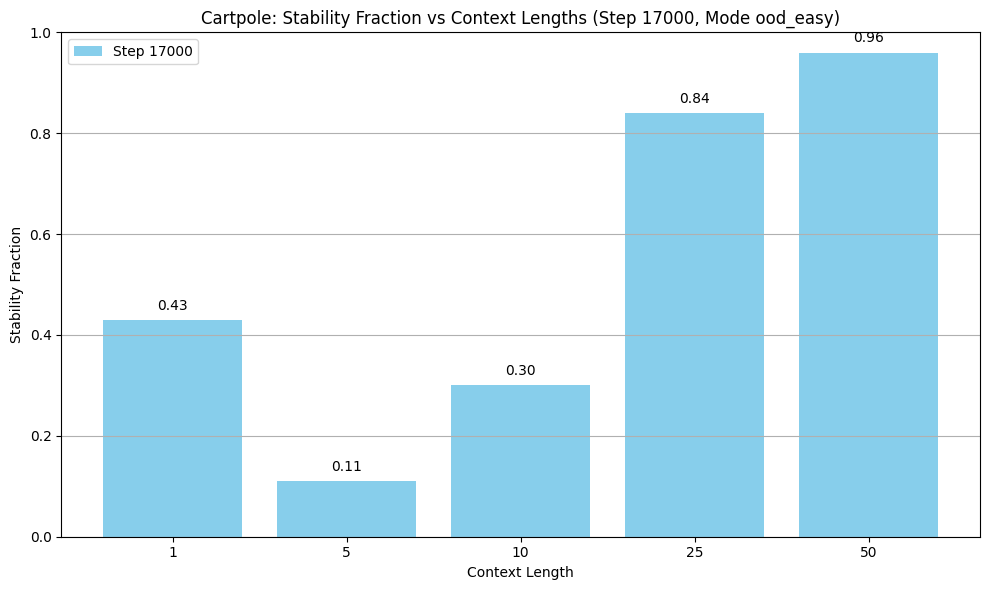

Saved line plot to test_plots_cartpole_temp/stability_fraction_vs_context_length_line_step17000_100systems_modeood_easy.png
Saved bar plot to test_plots_cartpole_temp/stability_fraction_vs_context_length_bar_step17000_100systems_modeood_easy.png


In [11]:
data2 = []
data2_stability_idxes = []
import matplotlib.pyplot as plt
import pandas as pd


for stp in steps_list2:
    for metric in metrics2:
        # print(f"Step: {stp}, Metric: {metric}")
        # for ctx in context_lengths:
        for ctx in contexts:
            for mode in modes:
                if metric == 'stability_fraction':
                    # val = results2[metric][(stp, ctx)]
                    # print(f"  Context: {ctx}, Stability Fraction: {val}")
                    data2.append({
                        'metric': metric,
                        'step': stp,
                        'context': ctx,
                        'mode': mode,
                        'value': results2[metric][(stp, ctx, mode)]
                    })
                elif metric == 'stability_idxes':
                    data2_stability_idxes.append({
                        'metric': metric,
                        'step': stp,
                        'context': ctx,
                        'mode': mode,
                        'value': results2[metric][(stp, ctx, mode)]
                    })
                elif metric == 'stability_idxes_gt':
                    data2_stability_idxes.append({
                        'metric': metric,
                        'step': stp,
                        'context': ctx,
                        'mode': mode,
                        'value': results2[metric][(stp, ctx, mode)]
                    })
                else:
                    pass


# visualize results: fraction over context
# fig_ctx, ax_ctx = plt.subplots(figsize=(10, 6))
df2 = pd.DataFrame(data2)
df2 = df2.sort_values(by='context')

# debugging
# print(f"Data for plotting: {df2.head()}")

metric = 'stability_fraction'
metric_data = df2[df2['metric'] == metric]
# plot stability fraction vs context for each step
for stp in steps_list2:
    for mode in modes:
        # fig_ctx, ax_ctx = plt.subplots(figsize=(10, 6))   # line graph
        # step_metric_data = metric_data[metric_data['step'] == stp]
        step_metric_data = metric_data[(metric_data['step'] == stp) & (metric_data['mode'] == mode)]
        
        # ax_ctx.plot(step_metric_data['context'], step_metric_data['value'], label=f'Step {stp}', marker='o')
        # ax_ctx.set_title(f'Cartpole: Stability Fraction vs Context Lengths (Step {stp})')
        # ax_ctx.set_xlabel('Context Length')
        # ax_ctx.set_ylabel('Stability Fraction')
        # ax_ctx.set_ylim(0, 1)
        # ax_ctx.set_xticks(contexts)
        # ax_ctx.set_xlim(1, max(contexts)+1)
        # ax_ctx.legend()
        # ax_ctx.grid(True)


        fig_ctx2, ax_ctx2 = plt.subplots(figsize=(10, 6))  # bar graph
        x_label_list = step_metric_data['context'].astype(str).tolist()  # Convert context values to strings for x-axis labels
        ax_ctx2.bar(x_label_list, step_metric_data['value'], label=f'Step {stp}', color='skyblue')
        ax_ctx2.set_title(f'Cartpole: Stability Fraction vs Context Lengths (Step {stp}, Mode {mode})')
        ax_ctx2.set_xlabel('Context Length')
        ax_ctx2.set_ylabel('Stability Fraction')
        ax_ctx2.set_ylim(0, 1)
        # ax_ctx2.set_xticks(contexts)
        # ax_ctx2.set_xlim(1, max(contexts)+1)
        ax_ctx2.legend()
        ax_ctx2.grid(True, axis='y')
        # add value labels on top of bars
        for i, v in enumerate(step_metric_data['value']):
            ax_ctx2.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=10)

        

        plt.tight_layout()
        plt.show()

        # create subfolder and save plot
        output_dir = "test_plots_cartpole_temp"
        os.makedirs(output_dir, exist_ok=True)
        file_path_line_plot = os.path.join(output_dir, f'stability_fraction_vs_context_length_line_step{stp}_100systems_mode{mode}.png')
        file_path_bar_plot = os.path.join(output_dir, f'stability_fraction_vs_context_length_bar_step{stp}_100systems_mode{mode}.png')
        # fig_ctx.savefig(file_path_line_plot)
        # fig_ctx2.savefig(file_path_bar_plot)
        print(f"Saved line plot to {file_path_line_plot}")
        print(f"Saved bar plot to {file_path_bar_plot}")
        



# print(f"Data for metric '{metric}': {metric_data.head()}")
# ax_ctx.plot(metric_data['context'], metric_data['value'], label='Stability Fraction', marker='o')
# ax_ctx.set_title(f'Cartpole: Stability Fraction vs Context Lengths (Step {step})')
# ax_ctx.set_xlabel('Context Length')
# ax_ctx.set_ylabel('Stability Fraction')
# ax_ctx.set_ylim(0, 1)
# ax_ctx.set_xticks(contexts)
# ax_ctx.set_xlim(1, max(contexts)+1)
# ax_ctx.legend()
# ax_ctx.grid(True)
# plt.tight_layout()
# plt.show()

# # create subfolder and save plot
# output_dir = f'evaluate_inference_checkpoint_{model_run_id}_100systems_mode{mode}'
# os.makedirs(output_dir, exist_ok=True)
# subfolder = f"contexts_vs_stability_fraction_100systems_mode{mode}"
# os.makedirs(os.path.join(output_dir, subfolder), exist_ok=True)
# # fig_ctx.savefig(os.path.join(output_dir, subfolder, f'stability_fraction_vs_context_length_step{step}_100systems_mode{mode}.png'))
# # fig_ctx.savefig(os.path.join(output_dir, subfolder, f'stability_fraction_vs_context_length_step{step}_100systems_mode{mode}.pdf'), format='pdf', bbox_inches='tight')

In [12]:
df_stability_idxes = pd.DataFrame(data2_stability_idxes)
df_stability_idxes = df_stability_idxes.sort_values(by='context')

window_size = 50

metric = 'stability_idxes'
metric_gt = 'stability_idxes_gt'
metric_data_idxes = df_stability_idxes[df_stability_idxes['metric'] == metric]
metric_data_idxes_gt = df_stability_idxes[df_stability_idxes['metric'] == metric_gt]

## Extract window of stabilization from each trace that stabilized and plot LQR cost during that window
def extract_stabilization_windows(pred_traj, 
                                  control_inputs, 
                                  stable_idxes, 
                                  window_size=10, 
                                  theta_threshold=0.05, 
                                  theta_dot_threshold=0.3):
    """
    Extracts windows of stabilizing predicted trajectories.
    Args:
        pred_traj (torch.Tensor): Tensor of shape (N, T, state_dim) containing predicted trajectories.
        control_inputs (torch.Tensor): Tensor of shape (N, T, action_dim) containing control inputs.
        stable_idxes (list): List of trajectory indices that stabilized.
        window_size (int): Number of time steps to include in the window where stabilization occurs in the middle.
    Returns:
        list: List of tensors of shape (window_size, state_dim) containing the extracted windows of stabilizing trajectories.
    """
    stabilization_windows = []
    control_windows = []

    for idx in stable_idxes:
        traj = pred_traj[idx]  # shape (T, state_dim)
        control = control_inputs[idx]  # shape (T, action_dim)

        theta_wrapped = wrap_to_pi(traj[:, 2])
        theta_dot = traj[:, 3]  # Assuming the pole angular velocity is at index 3
        
        stable_mask = ((torch.abs(theta_wrapped) < theta_threshold) & (torch.abs(theta_dot) < theta_dot_threshold))

        # Find first contiguous stable region of length window_size
        stable_float = stable_mask.float()
        conv = torch.nn.functional.conv1d(
            stable_float.view(1, 1, -1),
            torch.ones(1, 1, window_size, device=traj.device),
        ).squeeze()

        valid_starts = torch.where(conv == window_size)[0]

        if len(valid_starts) == 0:
            continue  # No stable window found

        start_idx = valid_starts[0].item()  # Take the first stable window
        end_idx = start_idx + window_size

        stabilization_window = traj[start_idx:end_idx]
        control_window = control[start_idx:end_idx]
        stabilization_windows.append(stabilization_window)
        control_windows.append(control_window)

    return stabilization_windows, control_windows

    #     stable_time_steps = torch.where(stable_region)[0]
    #     # print(f"Trajectory {idx} stable time steps: {stable_time_steps}")
    #     if len(stable_time_steps) == 0 or len(stable_time_steps) < window_size:
    #         continue  # Skip if no stable time steps found
    #     # print(f"Trajectory {idx} stable time steps: {stable_time_steps}")
    #     # import pdb; pdb.set_trace()     
    #     # first_stable_time_step = stable_time_steps[len()].item()
    #     idxx = len(stable_time_steps) // 2
    #     # print(f"idx: {idxx}")
    #     first_stable_time_step = stable_time_steps[idxx].item()
    #     # Extract a window around the first stable time step
    #     # start_idx = max(0, first_stable_time_step - window_size // 2)
    #     # end_idx = min(traj.shape[0], first_stable_time_step + window_size // 2)
    #     # end_idx = stable_time_steps[-1].item()
    #     # start_idx = end_idx - window_size
    #     # start_idx = stable_time_steps[0].item()  # Start of stable region
    #     # end_idx = start_idx + window_size  # Window of fixed size starting from the first stable time step
    #     # if end_idx > traj.shape[0]:
    #     #     end_idx = traj.shape[0]
    #     #     start_idx = end_idx - window_size
        
    #     # choose window such that all timesteps in window are stable
    #     idxxx = 10
    #     start_idx = stable_time_steps[idxxx].item()  # Start of stable region
    #     end_idx = start_idx + window_size  # Window of fixed size starting from the first
    #     candidate_window = traj[start_idx:end_idx]
    #     candidate_sin_theta = torch.sin(candidate_window[:, 2])
    #     candidate_cos_theta = torch.cos(candidate_window[:, 2])
    #     candidate_theta_dot = candidate_window[:, 3]
    #     candidate_stable_region = (torch.abs(candidate_sin_theta) < 0.05) & (candidate_cos_theta > 0) & (torch.abs(candidate_theta_dot) < 0.3)
    #     if not torch.all(candidate_stable_region):
    #         # If not all time steps in the candidate window are stable, try shifting the window forward until we find a fully stable window
    #         # for shift in range(1, traj.shape[0] - end_idx):
    #         # for new_idxx in range(len(stable_time_steps)):
    #         for candidate_start_idx in stable_time_steps[idxxx:]:
    #             # start_idx_shifted = start_idx + shift
    #             # end_idx_shifted = end_idx + shift
    #             # if end_idx_shifted > traj.shape[0]:
    #                 # break  # No more windows to check
    #             candidate_end_idx = candidate_start_idx + window_size
    #             if candidate_end_idx > traj.shape[0]:
    #                 break
    #             candidate_window = traj[candidate_start_idx:candidate_end_idx]
    #             candidate_sin_theta = torch.sin(candidate_window[:, 2])
    #             candidate_cos_theta = torch.cos(candidate_window[:, 2])
    #             candidate_theta_dot = candidate_window[:, 3]
    #             candidate_stable_region = (torch.abs(candidate_sin_theta) < 0.05) & (candidate_cos_theta > 0) & (torch.abs(candidate_theta_dot) < 0.3)
    #             if torch.all(candidate_stable_region):
    #                 start_idx = candidate_start_idx
    #                 end_idx = candidate_end_idx
    #                 break

    #     # print(f"Trajectory {idx} window: {start_idx} to {end_idx}")
    #     stabilization_window = traj[start_idx:end_idx]
    #     # print(f"Trajectory {idx} stabilization window shape: {stabilization_window.shape}")
    #     if stabilization_window.shape[0] < window_size:
    #         # start_idx = max(0, end_idx - window_size)
    #         start_idx = end_idx - window_size
    #         # print(f"start_idx: {start_idx}, end_idx: {end_idx}")
    #         stabilization_window = traj[start_idx:end_idx]
    #         # print(f"Trajectory {idx} adjusted stabilization window shape: {stabilization_window.shape}")
    #     # print(f"Trajectory {idx} final stabilization window shape: {stabilization_window.shape}")
    #     # assert len(stabilization_window) == window_size, f"Expected window size {window_size}, got {len(stabilization_window)}"
    #     control_window = control[start_idx:end_idx]
    #     stabilization_windows.append(stabilization_window)
    #     control_windows.append(control_window)

    # return stabilization_windows, control_windows

def wrap_angle(angle):
    """Wraps an angle in radians to the range [-pi, pi].

    Args:
        angle: a scalar angle in radians
    Returns:
        wrapped_angle: the angle wrapped to the range [-pi, pi]
    """
    return (angle + math.pi) % (2 * math.pi) - math.pi

def compute_lqr_cost(traj_window_list, control_window_list):
    """
    Computes the LQR cost for each trajectory window in the list.
    Args:
        traj_window_list (list): List of tensors of shape (window_size, state_dim) containing the extracted windows of stabilizing trajectories.
        control_window_list (list): List of tensors of shape (window_size, action_dim) containing the corresponding control inputs.
    Returns:
        list: List of LQR costs for each trajectory window.
    """
    lqr_costs = []
    # Define LQR cost matrices (these can be tuned based on the specific system)
    Q = np.diag([0, 0, 10, 0])  # State cost matrix
    # R = np.eye(1)
    R = 1
    for traj_window, control_window in zip(traj_window_list, control_window_list):
        costs = []
        for state, control in zip(traj_window, control_window):
            # wrap theta to [-pi, pi]
            theta = state[2].item()
            theta = wrap_angle(theta)
            state[2] = theta
            state_cost = state.cpu().numpy().T @ Q @ state.cpu().numpy()
            # print(f"control shape: {control.shape}, R shape: {R.shape}")
            # control_cost = control.cpu().numpy().T @ R @ control.cpu().numpy()
            control_cost = control.cpu().numpy().T * R * control.cpu().numpy()  # Assuming control is 1D
            total_cost = state_cost #+ control_cost
            costs.append(total_cost)
        lqr_costs.append(costs)
    return lqr_costs


# Example usage:
all_costs = {mode: {stp: {} for stp in steps_list2} for mode in modes}
pred_trajs = {mode: {stp: [] for stp in steps_list2} for mode in modes}
for stp in steps_list2:
    for mode in modes:
        step_metric_data_idxes = metric_data_idxes[(metric_data_idxes['step'] == stp) & (metric_data_idxes['mode'] == mode)]
        for _, row in step_metric_data_idxes.iterrows():
            ctx = row['context']
            # print(f"Processing step {stp}, mode {mode}, context {ctx}")
            # import pdb; pdb.set_trace()
            stable_idxes = row['value']
            if mode == "indistr" or mode == "ood_hard":
                data_path = f'inference_run/mse_control_{stp}_{model_run_id}/results_maxcontext50_numpends{numberpend}_{mode}_alexcode.pkl'
            else:
                data_path = f'inference_run/mse_control_easy_{stp}_{model_run_id}/results_maxcontext50_numpends{numberpend}_{mode}_alexcode.pkl'
            cartmasses, polemasses, polelengths, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
            pred_traj = torch.stack(phase_data[ctx])
            pred_trajs[mode][stp].append(pred_traj)
            ctrl_traj = torch.stack(controls_data[ctx])[:,:,0]  # Assuming control input is at index 0
            stabilization_windows, control_windows = extract_stabilization_windows(pred_traj, ctrl_traj, stable_idxes, window_size=window_size, theta_threshold=0.05, theta_dot_threshold=0.1)
            # stabilization_windows = extract_stabilization_windows(pred_traj, stable_idxes, window_size=100)
            lqr_costs = compute_lqr_cost(stabilization_windows, control_windows)
            # cost_array = np.array(lqr_costs)
            if len(lqr_costs) == 0:
                continue

            # all_costs[mode][stp].extend(lqr_costs)
            if ctx not in all_costs[mode][stp]:
                all_costs[mode][stp][ctx] = []
            all_costs[mode][stp][ctx].extend(lqr_costs)
            # print(f"len(all_costs[{mode}][{stp}]): {len(all_costs[mode][stp])}")
            




In [13]:
# Get lqr costs of ground-truth trajectories

all_costs_gt = {mode: {stp: {} for stp in steps_list2} for mode in modes}
true_trajs = {mode: {stp: [] for stp in steps_list2} for mode in modes}

for stp in steps_list2:
    for mode in modes:
        step_metric_data_idxes = metric_data_idxes_gt[(metric_data_idxes_gt['step'] == stp) & (metric_data_idxes_gt['mode'] == mode)]

        for _, row in step_metric_data_idxes.iterrows():
            stable_idxes = row['value']
            ctx = row['context']
            if mode == "indistr" or mode == "ood_hard":
                data_path = f'inference_run/mse_control_{stp}_{model_run_id}/results_maxcontext50_numpends{numberpend}_{mode}_alexcode.pkl'
            else:
                data_path = f'inference_run/mse_control_easy_{stp}_{model_run_id}/results_maxcontext50_numpends{numberpend}_{mode}_alexcode.pkl'
            cartmasses, polemasses, polelengths, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
            ground_truth_data_controls = data_and_controls[0]
            # import pdb; pdb.set_trace()
            trajs = []
            ctrls = []
            for i in range(len(ground_truth_data_controls)):
                trajs.append(ground_truth_data_controls[i][0])
                ctrls.append(ground_truth_data_controls[i][1])
            trajs = np.array(trajs)
            trajs = torch.tensor(trajs, dtype=torch.float32)
            true_trajs[mode][stp].append(trajs)
            ctrls = np.array(ctrls)
            ctrls = torch.tensor(ctrls, dtype=torch.float32)
            stabilization_windows, control_windows = extract_stabilization_windows(trajs, ctrls, stable_idxes, window_size=window_size, theta_threshold=0.05, theta_dot_threshold=0.1)
            lqr_costs = compute_lqr_cost(stabilization_windows, control_windows)
            if len(lqr_costs) == 0:
                continue
            
            if ctx not in all_costs_gt[mode][stp]:
                all_costs_gt[mode][stp][ctx] = []
            all_costs_gt[mode][stp][ctx].extend(lqr_costs)
            # import pdb; pdb.set_trace()

            

In [14]:
# # plot predicted trajectories that stabilized for select contexts
# context_to_plot = 25
# for stp in steps_list2:
#     for mode in modes:
#         # step_metric_data_idxes = metric_data_idxes_gt[(metric_data_idxes_gt['step'] == stp) & (metric_data_idxes_gt['mode'] == mode)]
#         step_metric_data_idxes = metric_data_idxes[(metric_data_idxes['step'] == stp) & (metric_data_idxes['mode'] == mode)]
#         fig_traj, ax_traj = plt.subplots(figsize=(10, 6))
#         fig_ctrl, ax_ctrl = plt.subplots(figsize=(10, 6))
#         for _, row in step_metric_data_idxes.iterrows():
#             ctx = row['context']
#             if ctx != context_to_plot:
#                 continue
#             stable_idxes = row['value']
#             if mode == "indistr" or mode == "ood_hard":
#                 data_path = f'inference_run/mse_control_{stp}_{model_run_id}/results_maxcontext50_numpends{numberpend}_{mode}_alexcode.pkl'
#             else:
#                 data_path = f'inference_run/mse_control_easy_{stp}_{model_run_id}/results_maxcontext50_numpends{numberpend}_{mode}_alexcode.pkl'
#             cartmasses, polemasses, polelengths, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
#             pred_traj = np.stack([phase_data[ctx][idx].cpu().numpy() for idx in stable_idxes])
#             ctrl_traj = np.stack([controls_data[ctx][idx].cpu().numpy() for idx in stable_idxes])
#             ground_truth_data_controls = data_and_controls[0]
#             gt_traj = []
#             for i in range(len(ground_truth_data_controls)):
#                 gt_traj.append(ground_truth_data_controls[i][0])
#             gt_ctrl = []
#             for i in range(len(ground_truth_data_controls)):
#                 gt_ctrl.append(ground_truth_data_controls[i][1])
#             gt_traj = np.stack(gt_traj)
#             gt_ctrl = np.stack(gt_ctrl)
#             # print(f"Plotting {len(pred_traj)} trajectories that stabilized for Step {stp}, Mode {mode}, Context {ctx}")

#             # ax_traj.plot(np.arange(pred_traj.shape[1]), pred_traj[:, 2], label=f'Trajectory (Step {stp}, Mode {mode})')  # Plotting pole angle (index 2)
#             for i in range(pred_traj.shape[0]):
#                 # if i == 70:
#                 # ax_traj.plot(np.arange(pred_traj.shape[1]), wrap_angle(pred_traj[i, :, 2]), label=f'Trajectory {i} (Step {stp}, Mode {mode})')  # Plotting pole angle (index 2)
#                 ax_traj.plot(np.arange(pred_traj.shape[1]), pred_traj[i, :, 1], label=f'Trajectory {i} (Step {stp}, Mode {mode})')  # Plotting pole angle (index 2)
#                 # ax_traj.plot(np.arange(gt_traj.shape[1]), np.cos(wrap_angle(gt_traj[i, :, 2])), label=f'Ground Truth Trajectory {i} (Step {stp}, Mode {mode})')  # Plotting pole angle (index 2)
#                 # ax_traj.plot(np.arange(gt_traj.shape[1]), gt_traj[i, :, 3], label=f'Ground Truth Trajectory {i} (Step {stp}, Mode {mode})')  # Plotting pole angular velocity (index 3)
                    
            
#             for j in range(ctrl_traj.shape[0]):
#                 # ax_ctrl.plot(np.arange(ctrl_traj.shape[1]), ctrl_traj[j], label=f'Control Trajectory {j} (Step {stp}, Mode {mode})')  # Assuming control is 1D
#                 ax_ctrl.plot(np.arange(gt_ctrl.shape[1]), gt_ctrl[j], label=f'Ground Truth Control {j} (Step {stp}, Mode {mode})')  # Assuming control is 1D
#         ax_traj.set_title(f'Cartpole: Predicted Trajectories that Stabilized (Step {stp}, Mode {mode}, Context {context_to_plot})')
#         ax_traj.set_xlabel('Time Steps')
#         ax_traj.set_ylabel('Pole Angle (radians)')
#         # ax_traj.legend()
#         ax_traj.grid(True)

#         ax_ctrl.set_title(f'Cartpole: Control Trajectories that Stabilized (Step {stp}, Mode {mode}, Context {context_to_plot})')
#         ax_ctrl.set_xlabel('Time Steps')
#         ax_ctrl.set_ylabel('Control Input')
#         # ax_ctrl.legend()
#         ax_ctrl.grid(True)
#         plt.tight_layout()
#         plt.show()
            



In [15]:
# import matplotlib.pyplot as plt
# import numpy as np

# n_rows = len(modes)
# n_cols = len(steps_list2)
# context_to_plot = 5

# # Create two master figures
# fig_traj, axes_traj = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
# fig_ctrl, axes_ctrl = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

# # Ensure axes are always 2D
# if n_rows == 1: 
#     axes_traj = np.expand_dims(axes_traj, 0); axes_ctrl = np.expand_dims(axes_ctrl, 0)
# if n_cols == 1: 
#     axes_traj = np.expand_dims(axes_traj, 1); axes_ctrl = np.expand_dims(axes_ctrl, 1)

# for r, mode in enumerate(modes):
#     for c, stp in enumerate(steps_list2):
#         ax_t = axes_traj[r, c]
#         ax_c = axes_ctrl[r, c]
        
#         # Filter data
#         step_metric_data_idxes = metric_data_idxes[(metric_data_idxes['step'] == stp) & (metric_data_idxes['mode'] == mode)]
        
#         for _, row in step_metric_data_idxes.iterrows():
#             ctx = row['context']
#             if ctx != context_to_plot:
#                 continue
            
#             stable_idxes = row['value']
            
#             # Logic for data path
#             folder = "mse_control" if mode in ["indistr", "ood_hard"] else "mse_control_easy"
#             data_path = f'inference_run/{folder}_{stp}_{model_run_id}/results_maxcontext50_numpends{numberpend}_{mode}_alexcode.pkl'
            
#             # Load your data
#             _, _, _, phase_data, controls_data, data_and_controls, _ = load_data(data_path)
            
#             # Prepare arrays
#             pred_traj = np.stack([phase_data[ctx][idx].cpu().numpy() for idx in stable_idxes])
#             ctrl_traj = np.stack([controls_data[ctx][idx].cpu().numpy() for idx in stable_idxes])
#             # Note: you were plotting gt_ctrl in your loop, I'll keep that logic
#             gt_traj = np.stack([data_and_controls[0][i][0] for i in range(len(data_and_controls))])
#             gt_ctrl = np.stack([data_and_controls[0][i][1] for i in range(len(data_and_controls))])

#             # Plot Trajectories on ax_t
#             for i in range(pred_traj.shape[0]):
#                 ax_t.plot(pred_traj[i, :, 2], alpha=0.6, linewidth=1)
            
#             # Plot Controls on ax_c
#             # for j in range(gt_ctrl.shape[0]):
#             #     ax_c.plot(gt_ctrl[j], alpha=0.6, linewidth=1)
#             for j in range(ctrl_traj.shape[0]):
#                 ax_c.plot(ctrl_traj[j], alpha=0.6, linewidth=1)

#         # Formatting Trajectory subplot
#         ax_t.set_title(f'Traj: {mode} | Step {stp}')
#         ax_t.grid(True)
#         if r == n_rows - 1: ax_t.set_xlabel('Time Steps')
#         if c == 0: ax_t.set_ylabel('Pole Angle')

#         # Formatting Control subplot
#         ax_c.set_title(f'Ctrl: {mode} | Step {stp}')
#         ax_c.grid(True)
#         if r == n_rows - 1: ax_c.set_xlabel('Time Steps')
#         if c == 0: ax_c.set_ylabel('Control Input')

# # Final adjustments and display
# fig_traj.suptitle(f'All Predicted Trajectories (Context {context_to_plot})', fontsize=16)
# fig_ctrl.suptitle(f'All Control Trajectories (Context {context_to_plot})', fontsize=16)

# fig_traj.tight_layout(rect=[0, 0.03, 1, 0.95])
# fig_ctrl.tight_layout(rect=[0, 0.03, 1, 0.95])

# plt.show()

Mode indistr, Step 5000, Context 5, N=28
Mode indistr, Step 5000, Context 10, N=49
Mode indistr, Step 5000, Context 25, N=53
Mode indistr, Step 5000, Context 50, N=40
--------------------------------------------------
Mode indistr, Step 10000, Context 1, N=29
Mode indistr, Step 10000, Context 5, N=49
Mode indistr, Step 10000, Context 10, N=51
Mode indistr, Step 10000, Context 25, N=54
Mode indistr, Step 10000, Context 50, N=78
--------------------------------------------------
Mode indistr, Step 17000, Context 1, N=46
Mode indistr, Step 17000, Context 5, N=55
Mode indistr, Step 17000, Context 10, N=74
Mode indistr, Step 17000, Context 25, N=70
Mode indistr, Step 17000, Context 50, N=80
--------------------------------------------------
Mode ood_hard, Step 5000, Context 5, N=2
Mode ood_hard, Step 5000, Context 10, N=1
Mode ood_hard, Step 5000, Context 25, N=1
Mode ood_hard, Step 5000, Context 50, N=1
--------------------------------------------------
Mode ood_hard, Step 10000, Context 1

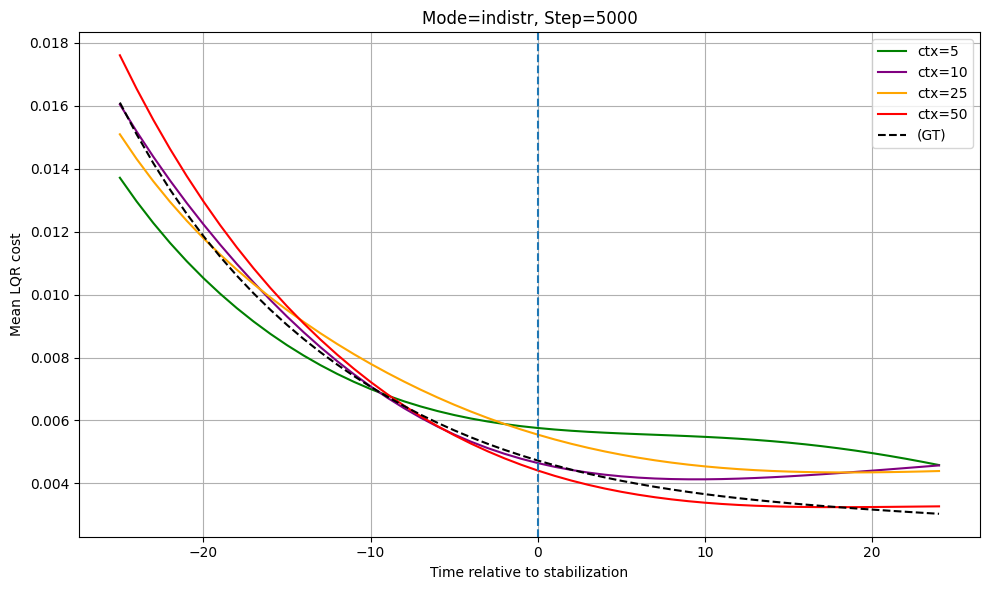

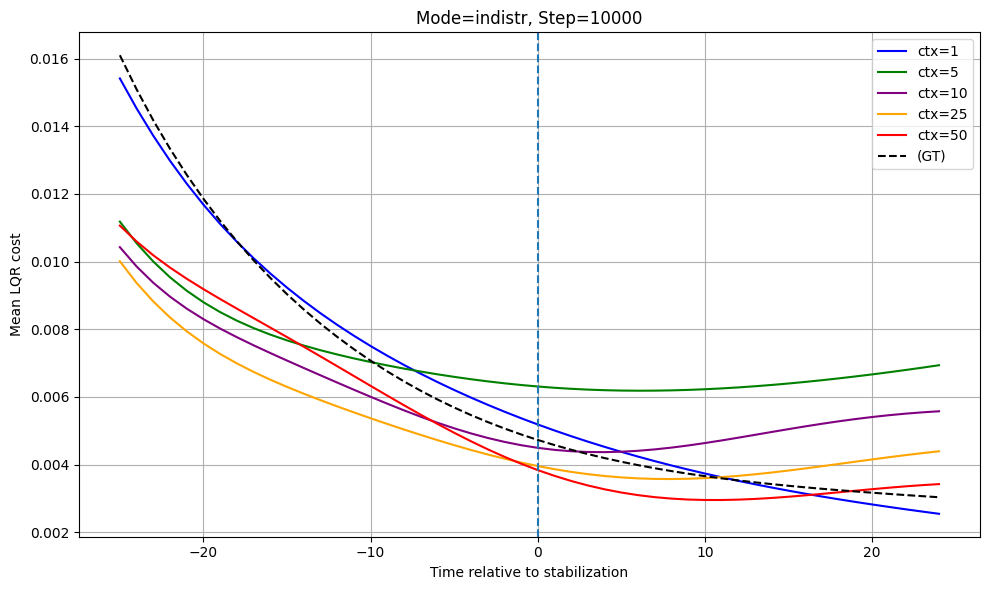

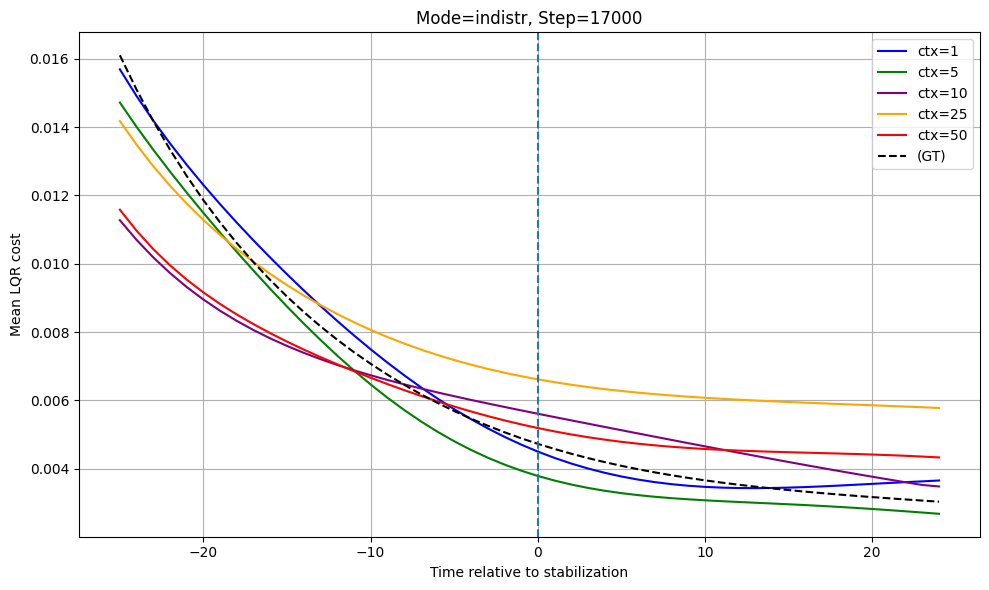

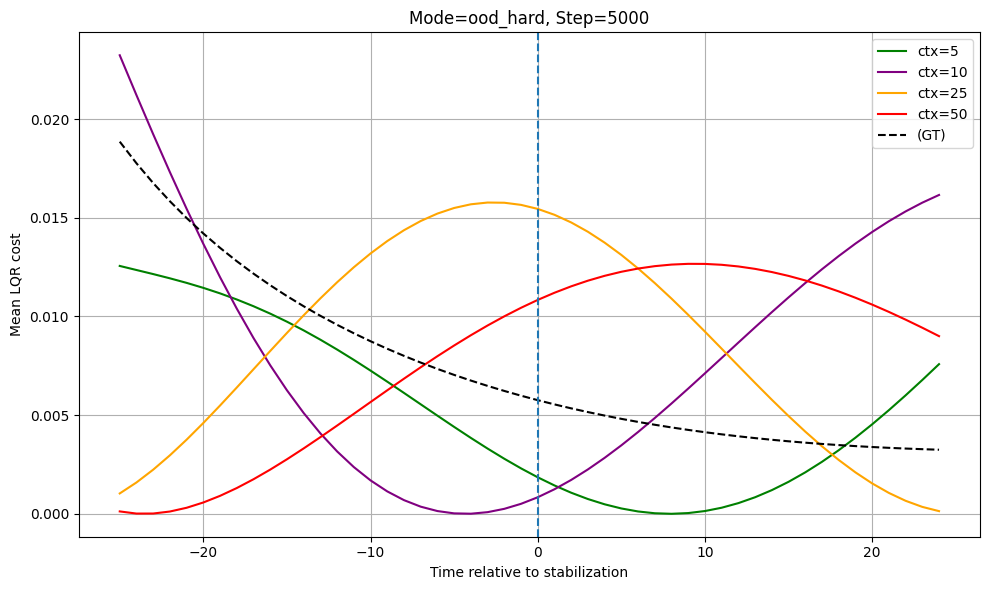

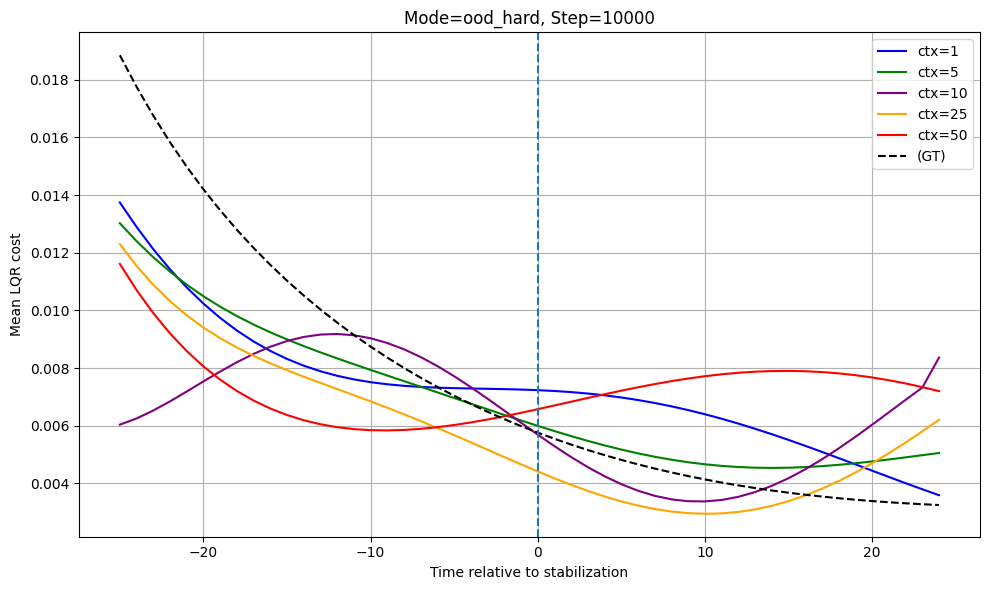

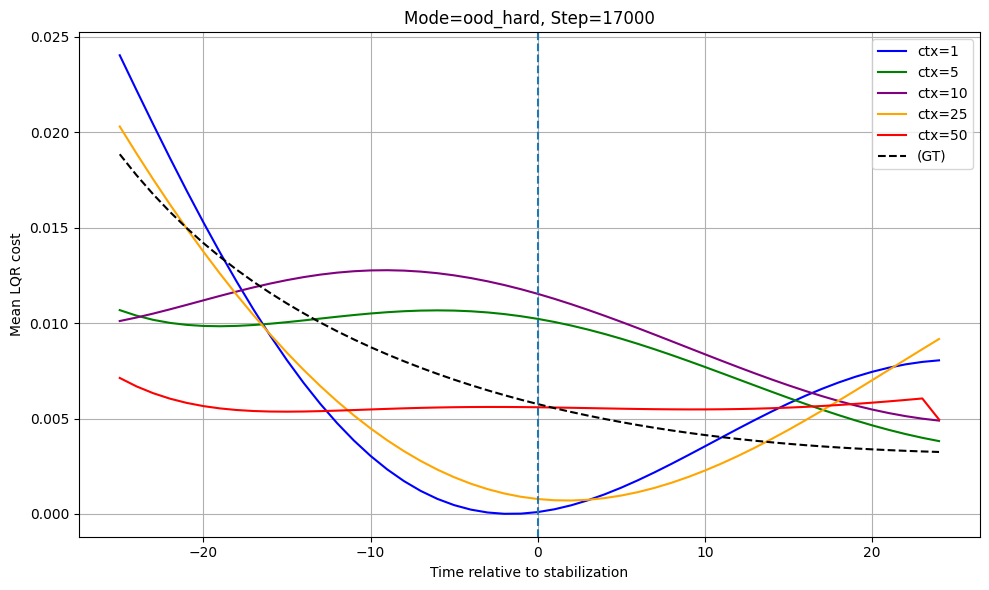

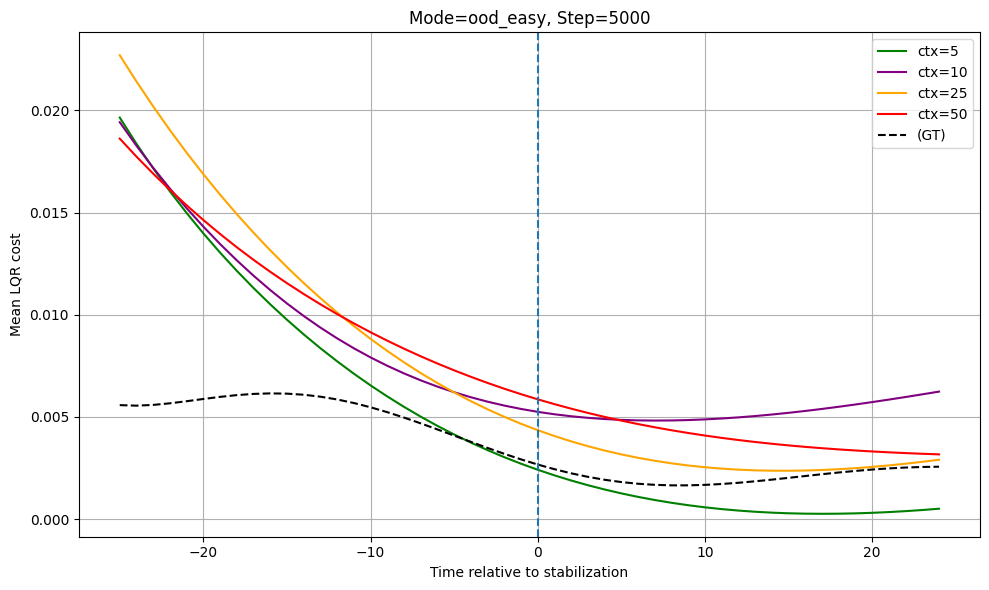

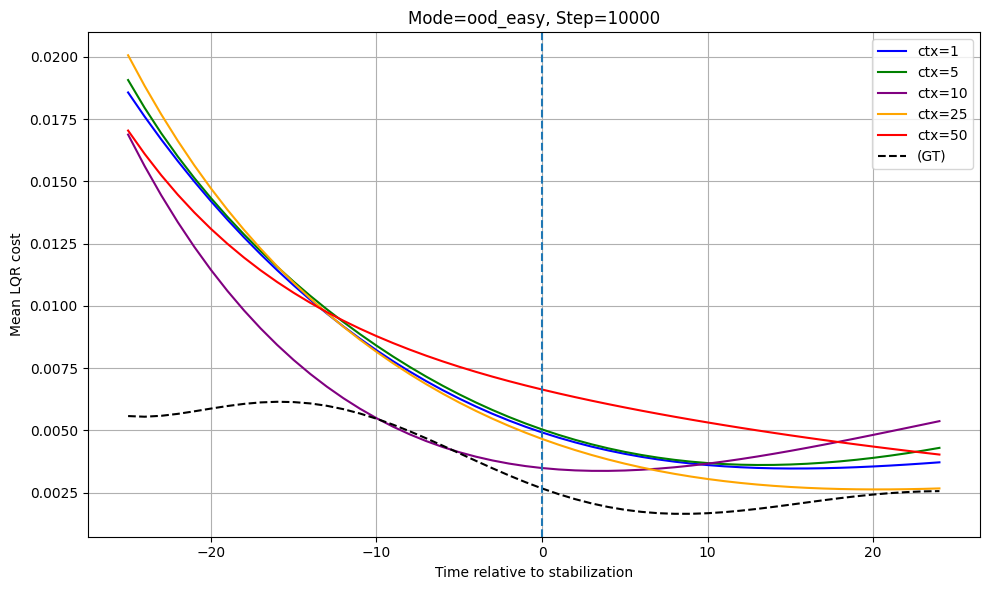

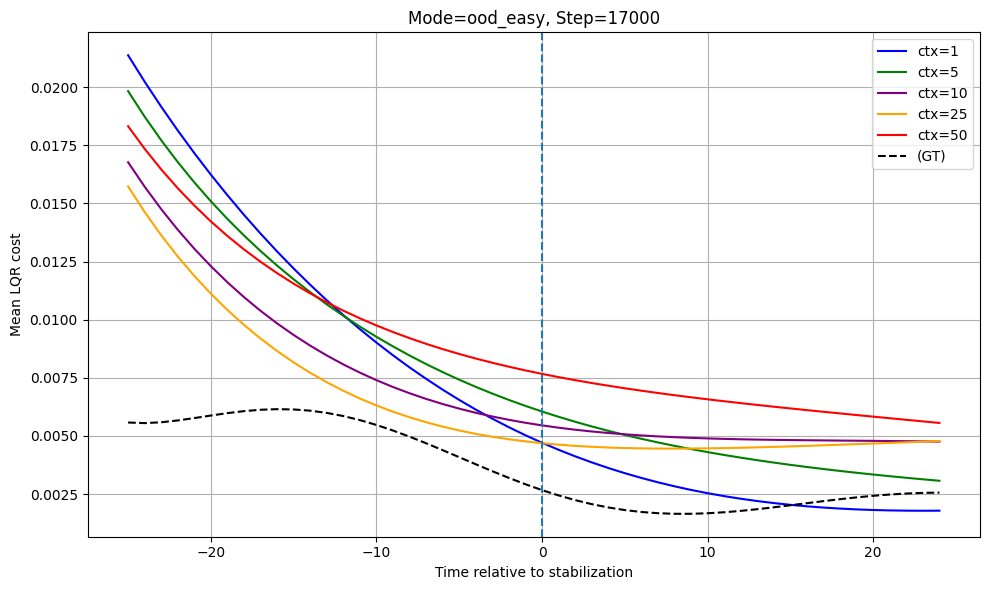

In [16]:
def aggregate_ragged(lqr_costs):
    max_length = max(len(cost) for cost in lqr_costs)

    mean_cost, std_cost, counts = [], [], []

    for t in range(max_length):
        vals = [cost[t] for cost in lqr_costs if len(cost) > t]

        if len(vals) == 0:
            mean_cost.append(np.nan)
            std_cost.append(np.nan)
            counts.append(0)

        else:
            vals = np.array(vals)
            mean_cost.append(np.mean(vals))
            std_cost.append(np.std(vals))
            counts.append(len(vals))
    return np.array(mean_cost), np.array(std_cost), np.array(counts)

# Plot mean LQR cost over time with error bars for each step and mode
import matplotlib.pyplot as plt

# for mode in modes:
#     plt.figure(figsize=(10, 6))
#     for stp in steps_list2:
#         lqr_costs = all_costs[mode][stp]
#         print(f"len(lqr_costs) for Step {stp}, Mode {mode}: {len(lqr_costs)}")
#         if len(lqr_costs) == 0:
#             continue
#         mean_cost, std_cost, counts = aggregate_ragged(lqr_costs)
#         mean_minus_std = mean_cost - std_cost
#         if np.any(mean_minus_std < 0):
#             # set std_cost to be zero
#             where_zero = mean_minus_std < 0
#             mean_minus_std[where_zero] = 0
#         time_steps = np.arange(len(mean_cost))
#         plt.plot(time_steps, mean_cost, label=f'Step {stp}', marker='o')
#         plt.fill_between(time_steps, mean_minus_std, mean_cost + std_cost, alpha=0.2)
#     plt.title(f'Cartpole: Mean LQR Cost during Stabilization Windows (Mode {mode})')
#     plt.xlabel('Time Steps since Stabilization')
#     plt.ylabel('Mean LQR Cost')
#     plt.legend()
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()


import matplotlib.pyplot as plt
color_dict = {
    1: "blue",
    5: "green",
    10: "purple",
    25: "orange",
    50: "red"
}
for mode in modes:
    for stp in steps_list2:
        plt.figure(figsize=(10, 6))

        ctx_dict = all_costs[mode][stp]
        ctx_dict_gt = all_costs_gt[mode][stp]

        for ctx in sorted(ctx_dict.keys()):
            lqr_costs = ctx_dict[ctx]
            lqr_costs_gt = ctx_dict_gt[ctx]        

            print(f"Mode {mode}, Step {stp}, Context {ctx}, N={len(lqr_costs)}")

            if len(lqr_costs) == 0:
                continue
            if len(lqr_costs_gt) == 0:
                continue

            mean_cost, std_cost, counts = aggregate_ragged(lqr_costs)
            mean_cost_gt, std_cost_gt, counts_gt = aggregate_ragged(lqr_costs_gt)

            # avoid negative shading
            lower = np.maximum(mean_cost - std_cost, 0)
            lower_gt = np.maximum(mean_cost_gt - std_cost_gt, 0)

            time_steps = np.arange(len(mean_cost))
            t = time_steps - len(mean_cost) // 2  # align stabilization
            t_gt = time_steps - len(mean_cost_gt) // 2  # align stabilization

            plt.plot(t, mean_cost, label=f'ctx={ctx}', color=color_dict.get(ctx, 'black'))
            # plt.fill_between(t, lower, mean_cost + std_cost, alpha=0.2, color=color_dict.get(ctx, 'black'))

            if ctx == 50:
                plt.plot(t_gt, mean_cost_gt, label=f'(GT)', linestyle='--', color='black')
                # plt.fill_between(t_gt, lower_gt, mean_cost_gt + std_cost_gt, alpha=0.2, color=color_dict.get(ctx, 'black'))
        
        print(f"-"*50)

        plt.axvline(0, linestyle='--')
        # plt.yscale('log')
        plt.title(f'Mode={mode}, Step={stp}')
        plt.xlabel('Time relative to stabilization')
        plt.ylabel('Mean LQR cost')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        # plt.show()

Global y-axis limits: ymin=6.751875276706545e-07, ymax=0.02404163955749286


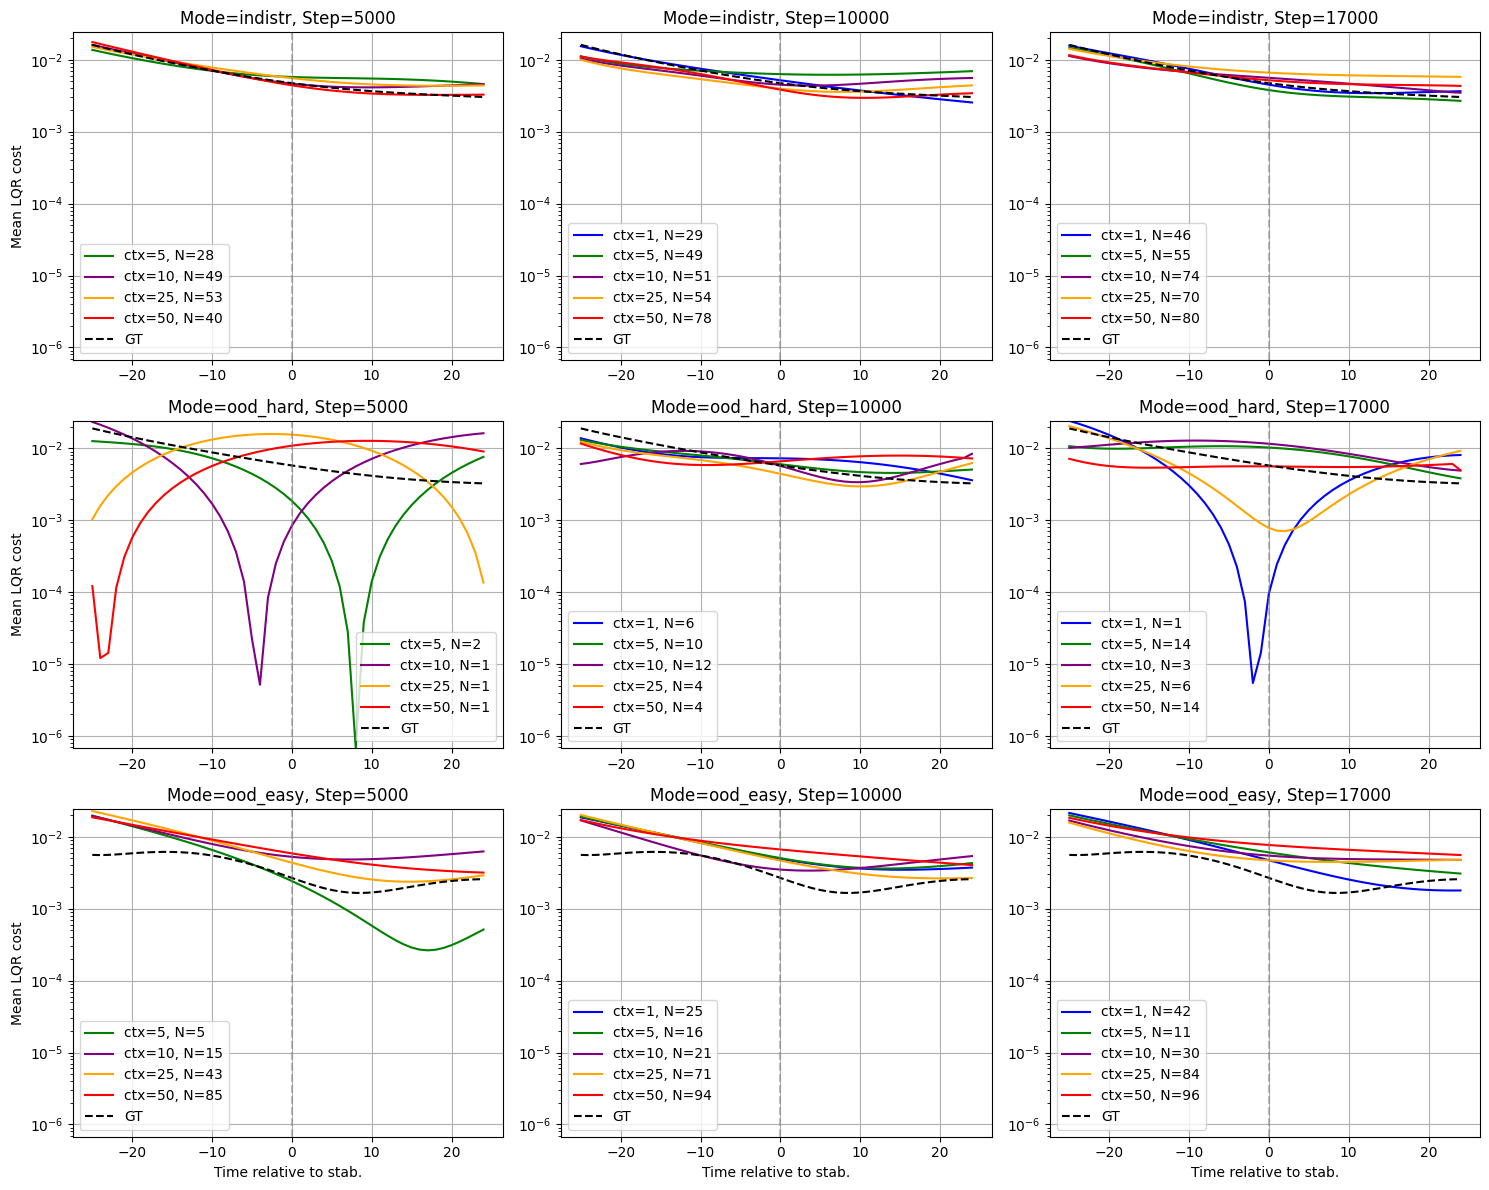

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Define your grid dimensions
n_rows = len(modes)
n_cols = len(steps_list2)

# Create one large figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=False)

# Ensure axes is always a 2D array even if rows/cols = 1
if n_rows == 1: axes = np.expand_dims(axes, 0)
if n_cols == 1: axes = np.expand_dims(axes, 1)

color_dict = {1: "blue", 5: "green", 10: "purple", 25: "orange", 50: "red"}
global_ymin = np.inf
global_ymax = -np.inf

for mode in modes:
    for stp in steps_list2:

        ctx_dict = all_costs[mode][stp]
        ctx_dict_gt = all_costs_gt[mode][stp]

        for ctx in sorted(ctx_dict.keys()):

            lqr_costs = ctx_dict[ctx]
            lqr_costs_gt = ctx_dict_gt[ctx]

            if len(lqr_costs) == 0 or len(lqr_costs_gt) == 0:
                continue

            mean_cost, std_cost, _ = aggregate_ragged(lqr_costs)
            mean_cost_gt, std_cost_gt, _ = aggregate_ragged(lqr_costs_gt)

            vals = np.concatenate([
                mean_cost[np.isfinite(mean_cost)],
                mean_cost_gt[np.isfinite(mean_cost_gt)]
            ])

            vals = vals[vals > 0]  # needed for log scale

            if len(vals) == 0:
                continue

            global_ymin = min(global_ymin, vals.min())
            global_ymax = max(global_ymax, vals.max())
print(f"Global y-axis limits: ymin={global_ymin}, ymax={global_ymax}")
for r, mode in enumerate(modes):
    for c, stp in enumerate(steps_list2):
        ax = axes[r, c]  # Select the specific subplot
        
        ctx_dict = all_costs[mode][stp]
        ctx_dict_gt = all_costs_gt[mode][stp]

        for ctx in sorted(ctx_dict.keys()):
            lqr_costs = ctx_dict[ctx]
            lqr_costs_gt = ctx_dict_gt[ctx]        

            if len(lqr_costs) == 0 or len(lqr_costs_gt) == 0:
                continue

            mean_cost, std_cost, _ = aggregate_ragged(lqr_costs)
            mean_cost_gt, std_cost_gt, _ = aggregate_ragged(lqr_costs_gt)

            lower = np.maximum(mean_cost - std_cost, 0)
            t = np.arange(len(mean_cost)) - len(mean_cost) // 2
            t_gt = np.arange(len(mean_cost_gt)) - len(mean_cost_gt) // 2

            # Plot on the specific axis 'ax'
            line_color = color_dict.get(ctx, 'black')
            ax.plot(t, mean_cost, label=f'ctx={ctx}, N={len(lqr_costs)}', color=line_color)
            # ax.fill_between(t, lower, mean_cost + std_cost, alpha=0.2, color=line_color)

            if ctx == 50:
                ax.plot(t_gt, mean_cost_gt, label='GT', linestyle='--', color='black')

        # Subplot formatting
        ax.axvline(0, linestyle='--', color='gray', alpha=0.5)
        ax.set_title(f'Mode={mode}, Step={stp}')
        ax.grid(True)
        
        # Only add labels to the outer edges to keep it clean
        if r == n_rows - 1: ax.set_xlabel('Time relative to stab.')
        if c == 0: ax.set_ylabel('Mean LQR cost')
        
        # Only show legend on the first plot or use a global legend
        # if r == 0 and c == 0:
        ax.legend()
        # log scale y axis
        ax.set_yscale('log')
        ax.set_ylim(global_ymin, global_ymax)

plt.tight_layout()
plt.show()
# # save figure png
# output_dir = "lqr_cost_plots_cartpole_temp_fixedmaybe"
# os.makedirs(output_dir, exist_ok=True)
# fig.savefig(os.path.join(output_dir, f'mean_lqr_cost_stabilization_windows_all_steps_modes_noxcost_no_ctrlcost_{window_size}.png'))

Saved paper-ready plot: stability_comparison_step5000_paper.png


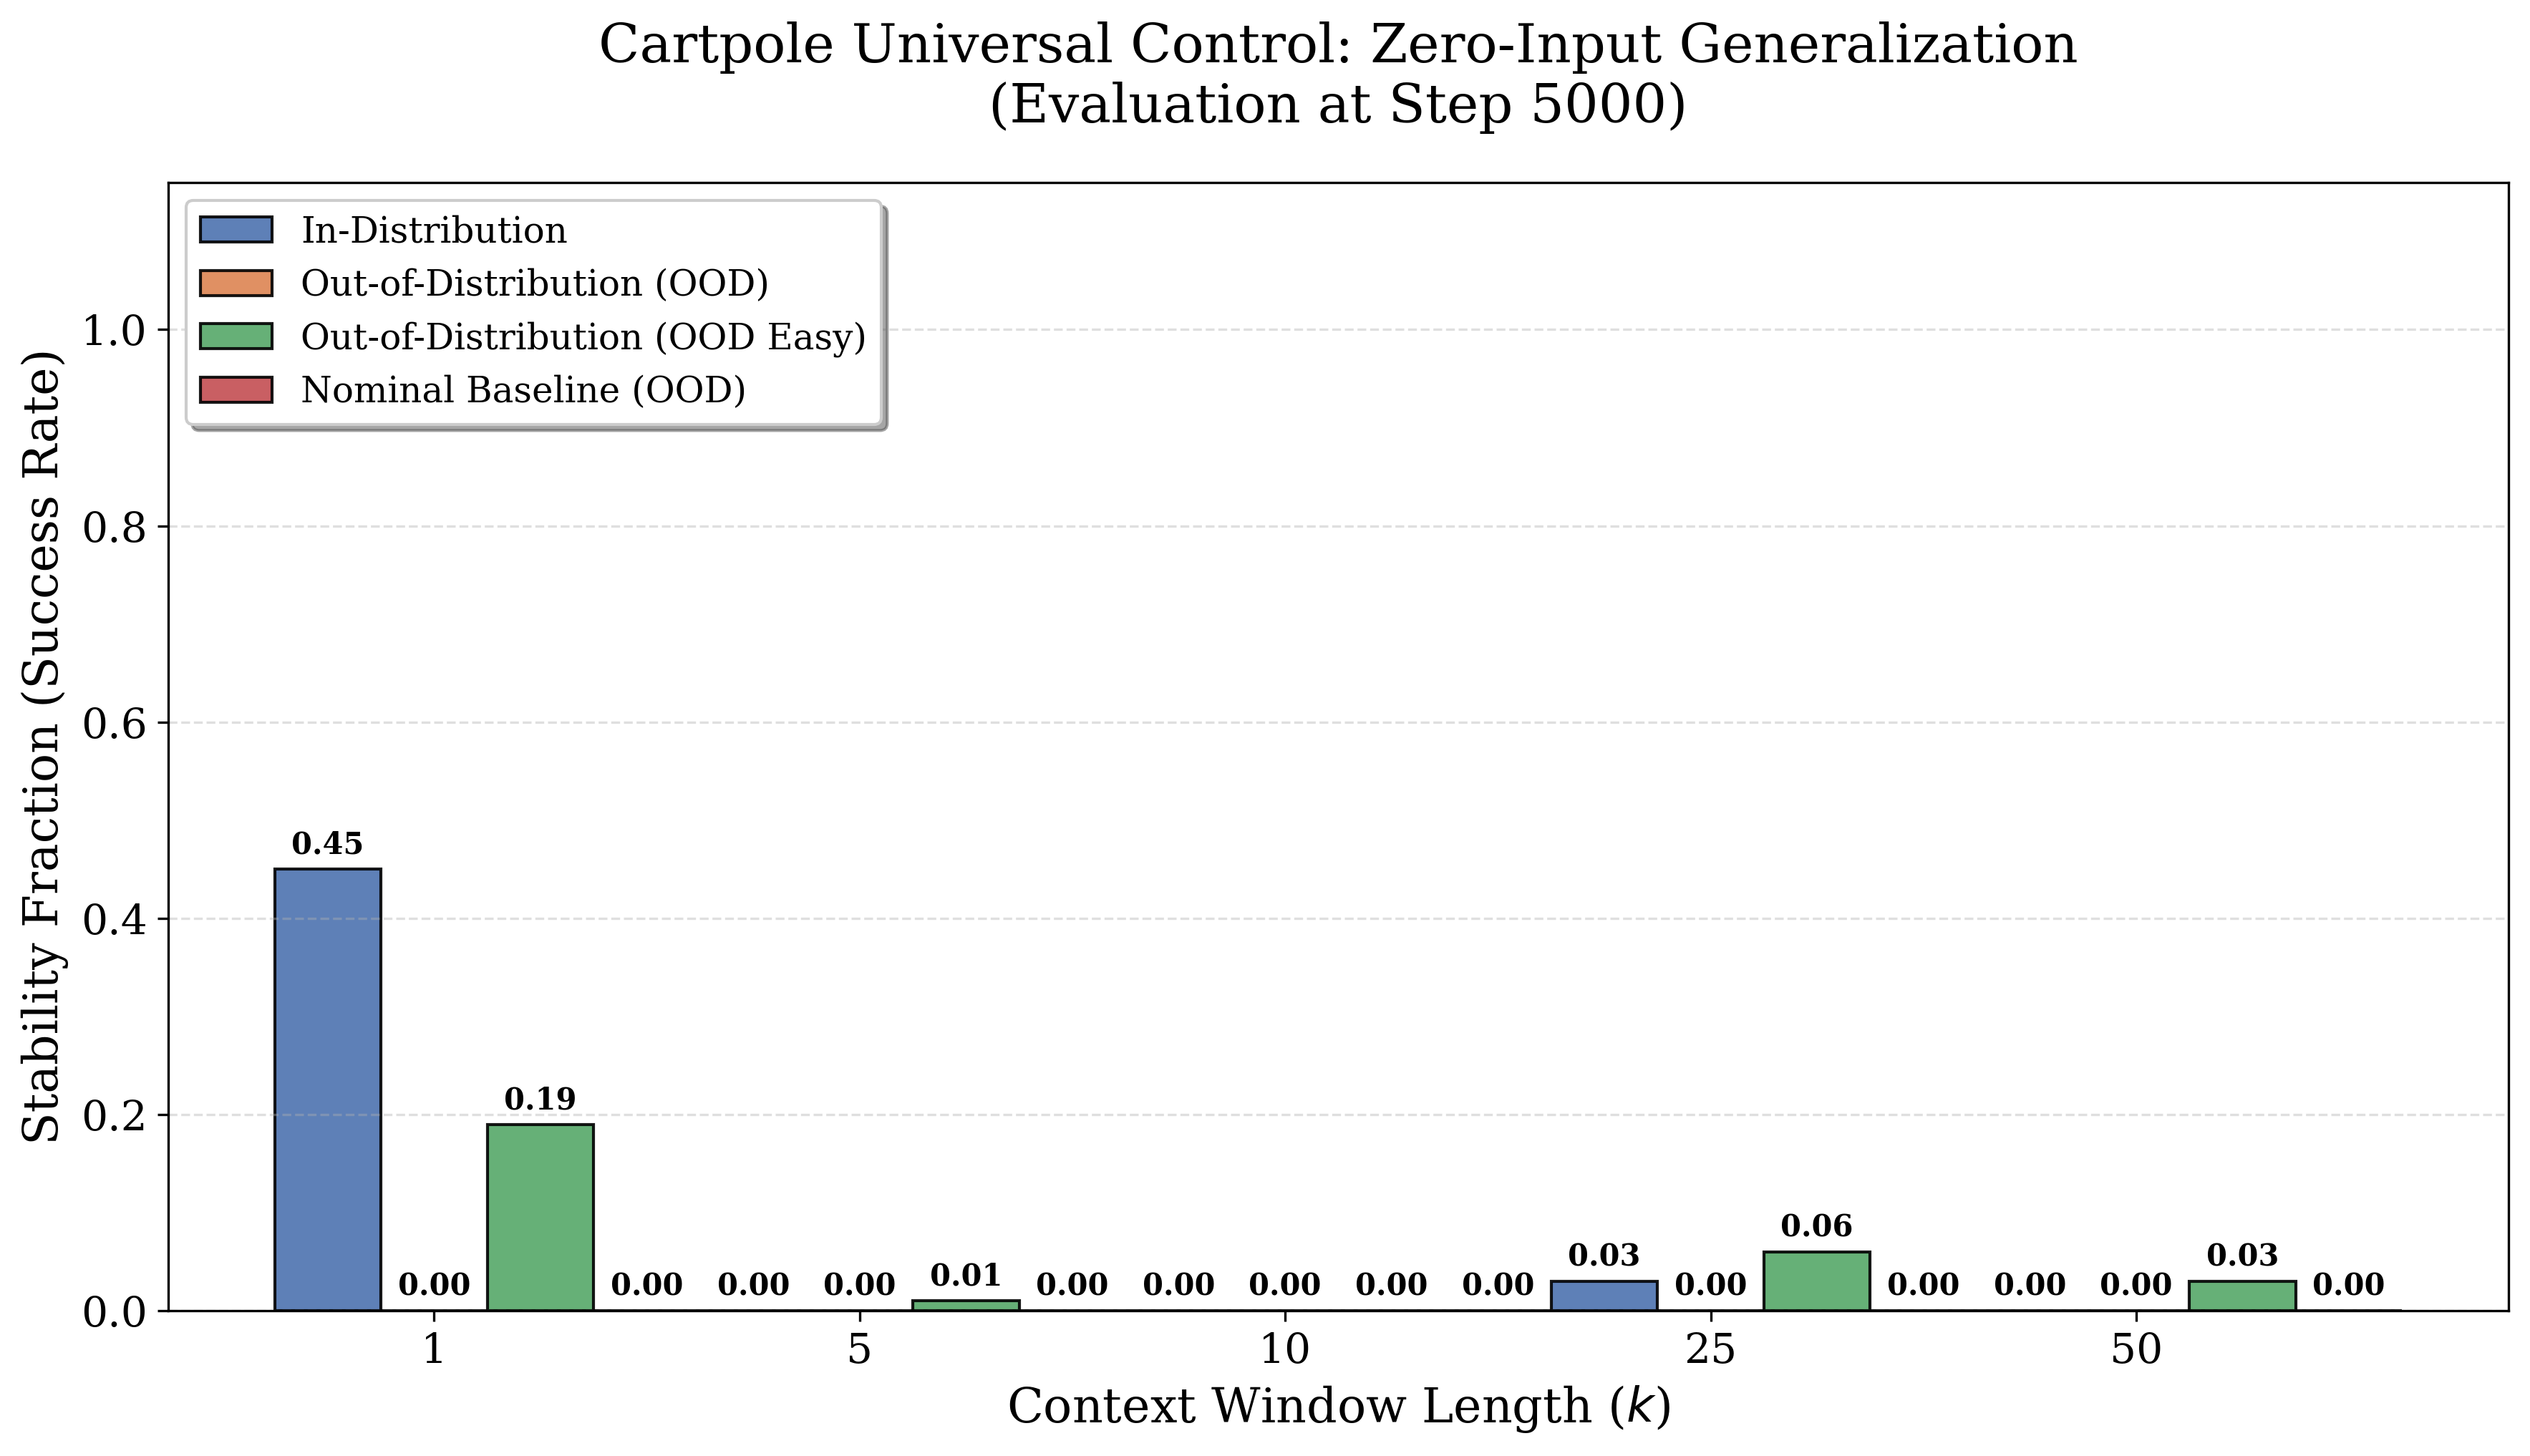

Saved paper-ready plot: stability_comparison_step10000_paper.png


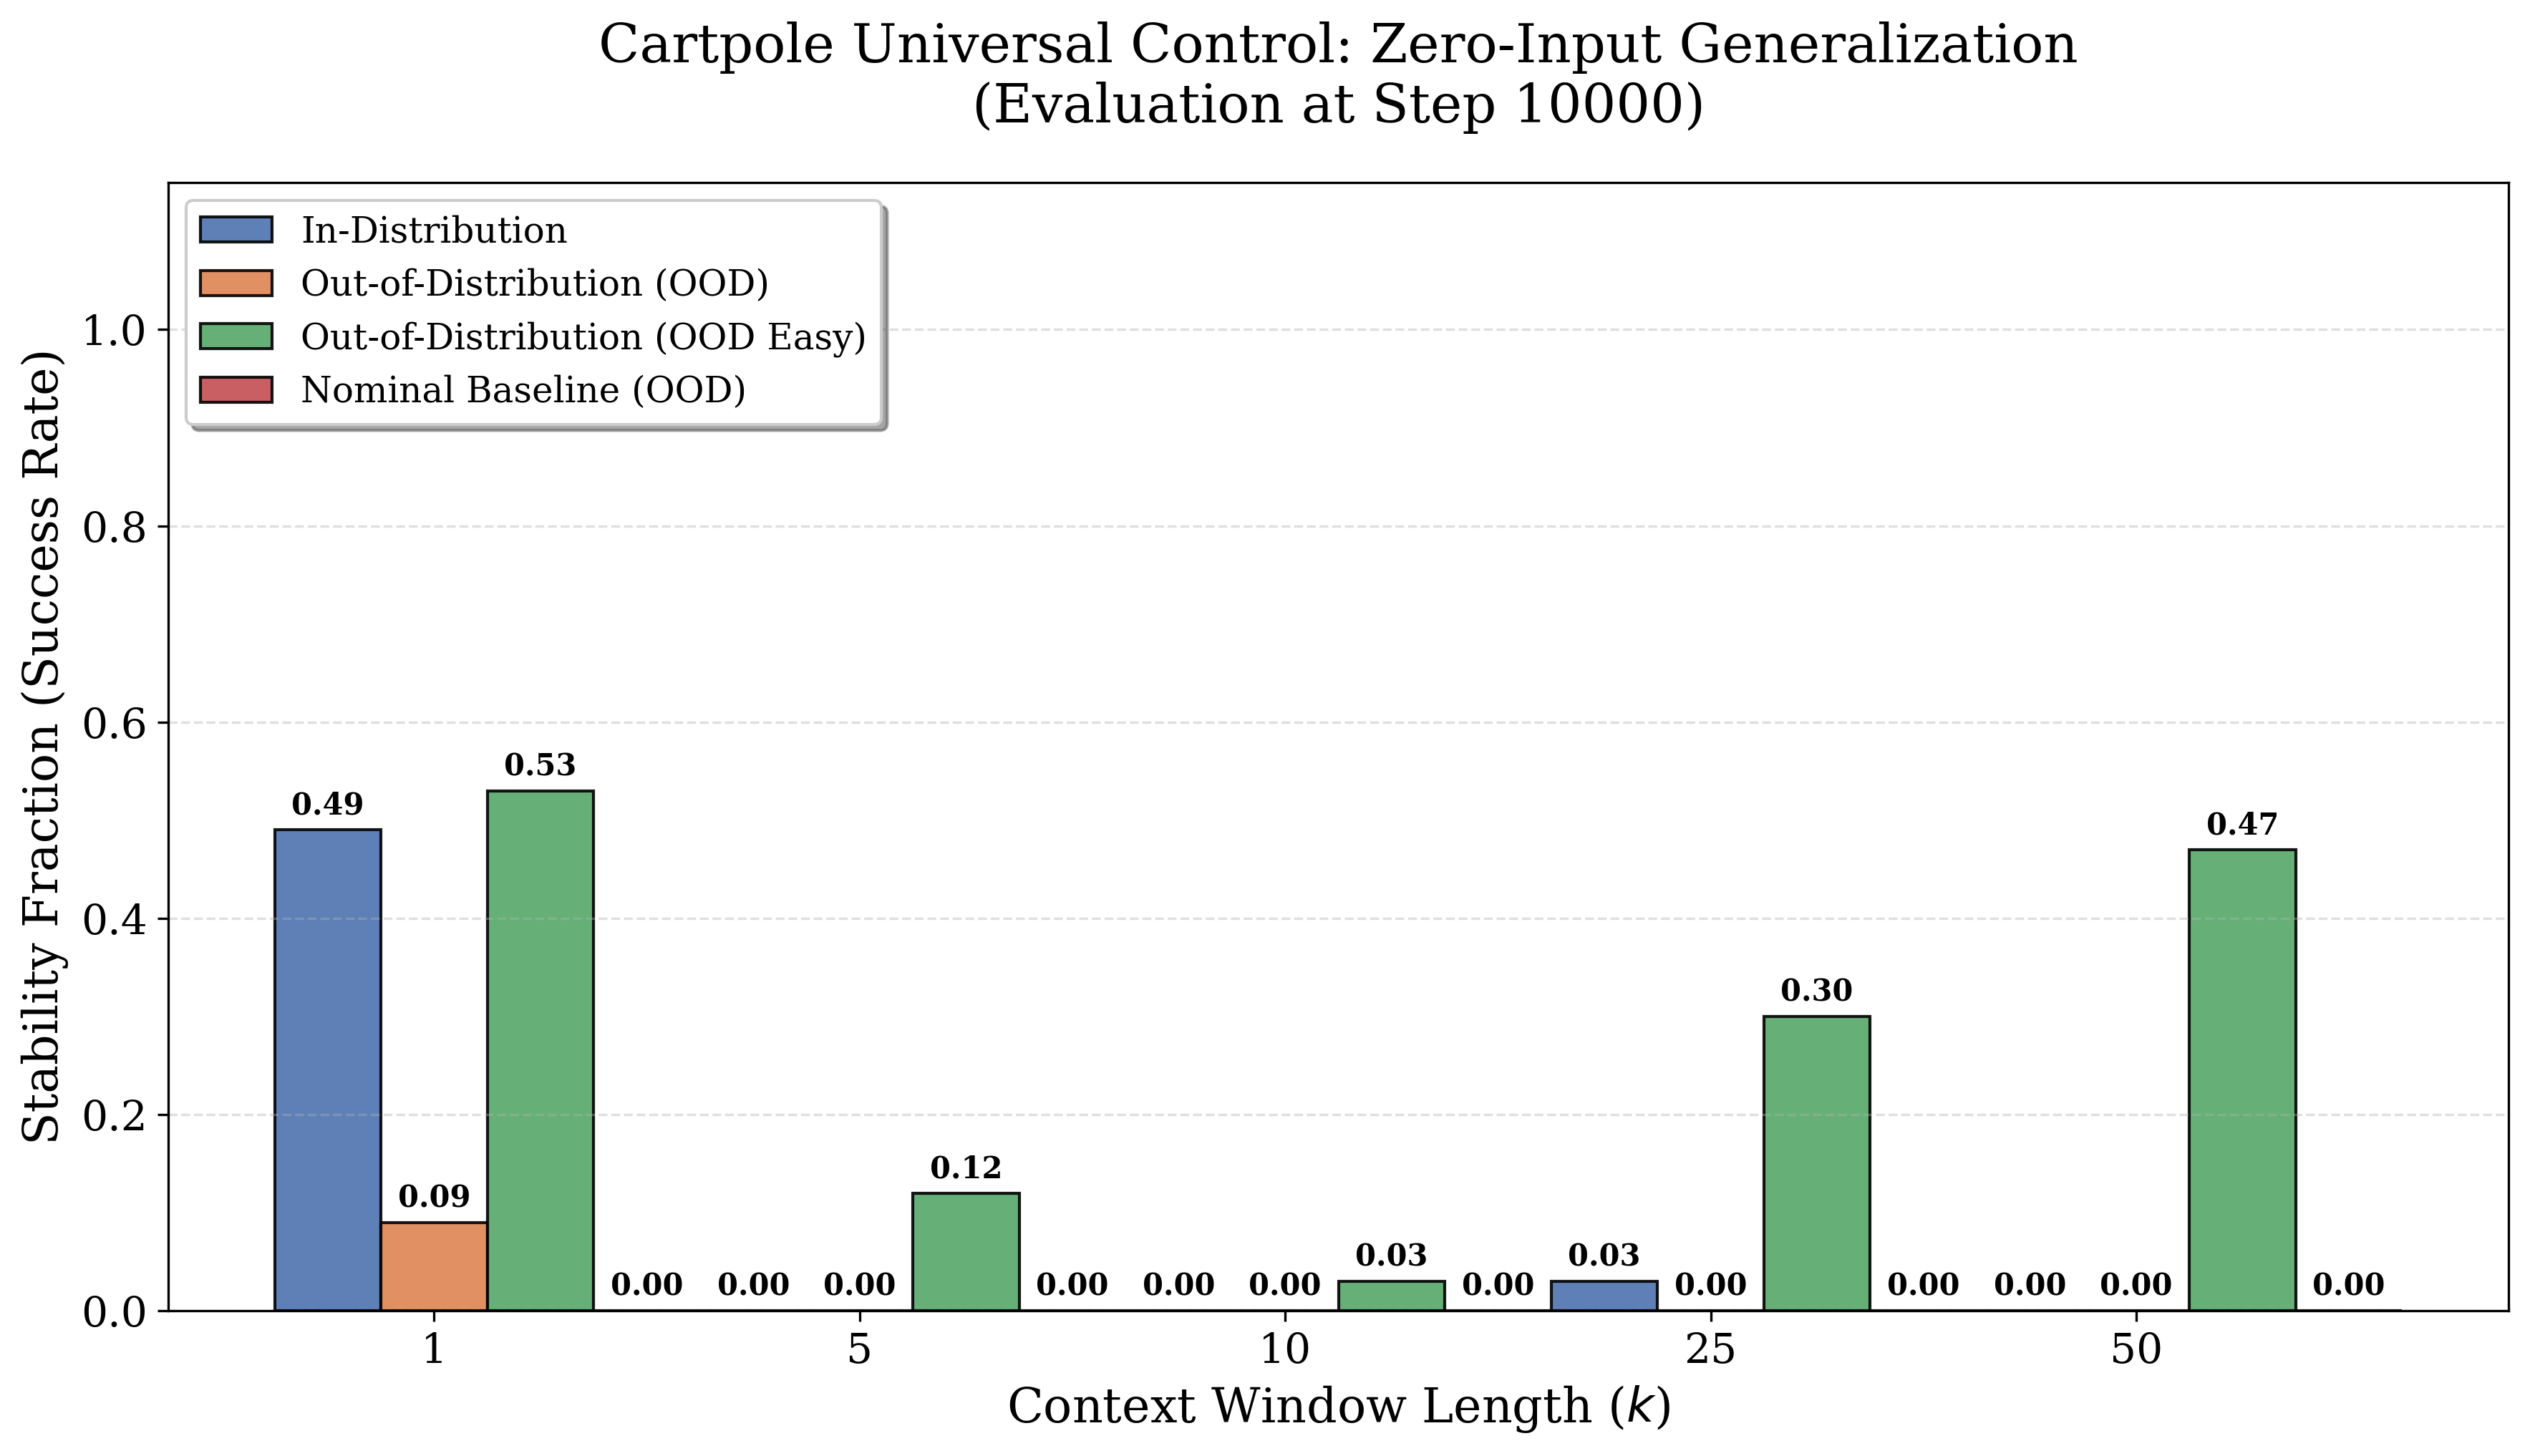

Saved paper-ready plot: stability_comparison_step17000_paper.png


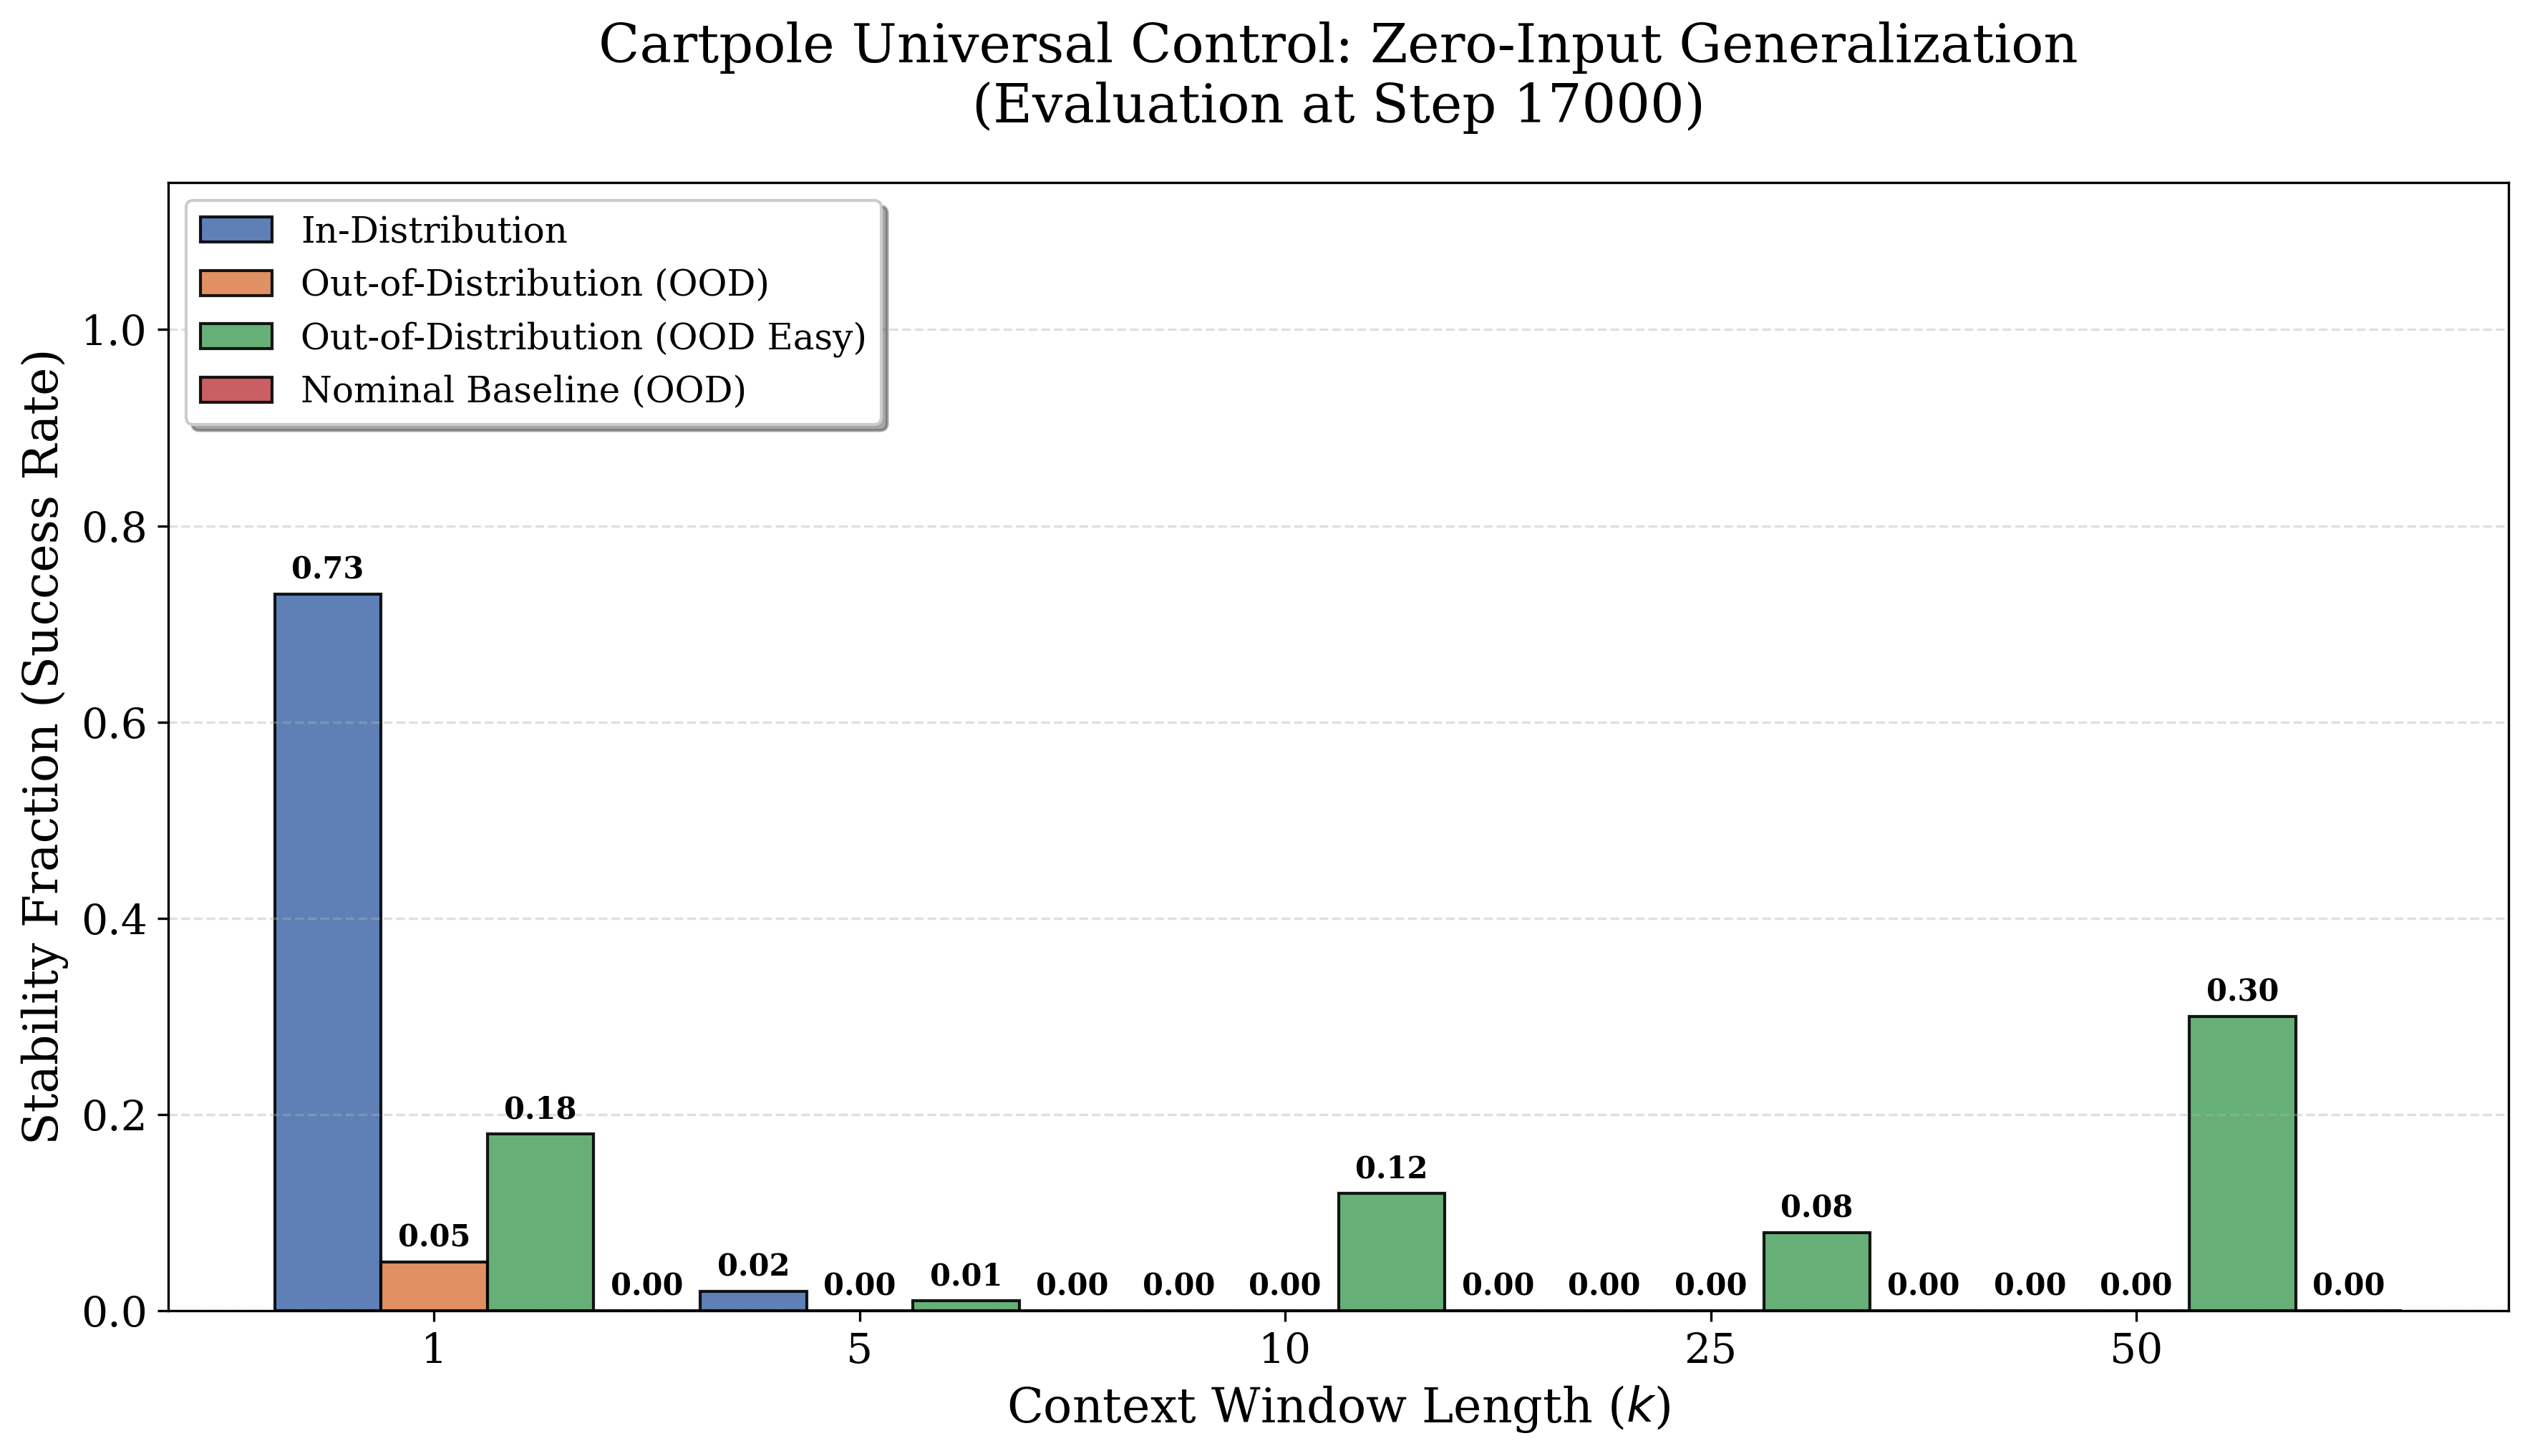

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# --- 1. SET PAPER-READY STYLING ---
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'font.family': 'serif',
    'figure.dpi': 300
})

# --- 2. PREPARE DATA ---
data2 = []
metric = 'stability_fraction'

for stp in steps_list2:
    for ctx in contexts:
        for mode in modes:
            val = results2[metric].get((stp, ctx, mode), 0.0)
            data2.append({
                'step': stp,
                'context': ctx,
                'mode': mode,
                'value': val
            })
        # Add Nominal Baseline (Hardcoded 0 as per your finding)
        data2.append({
            'step': stp,
            'context': ctx,
            'mode': 'nominal',
            'value': 0.0
        })

df_plot = pd.DataFrame(data2)
output_dir = "paper_plots_cartpole"
os.makedirs(output_dir, exist_ok=True)

# --- 3. PLOT GENERATION ---
for stp in steps_list2:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Filter and Sort
    step_data = df_plot[df_plot['step'] == stp]
    sorted_contexts = sorted(contexts)
    x = np.arange(len(sorted_contexts))
    width = 0.25  # Bar width
    
    # Define Categories and Colors
    # Blue: In-Distr, Orange: OOD, Red: Nominal (Failure)
    categories = [('indistr', 'In-Distribution', '#4C72B0'), 
                  ('ood_hard', 'Out-of-Distribution (OOD)', '#DD8452'), 
                  ('ood_easy', 'Out-of-Distribution (OOD Easy)', '#55A868'),
                  ('nominal', 'Nominal Baseline (OOD)', '#C44E52')]

    for i, (mode_key, label, color) in enumerate(categories):
        vals = []
        for ctx in sorted_contexts:
            v = step_data[(step_data['context'] == ctx) & (step_data['mode'] == mode_key)]['value'].values
            vals.append(v[0] if len(v) > 0 else 0)
        
        offset = (i - 1) * width
        bars = ax.bar(x + offset, vals, width, label=label, color=color, edgecolor='black', alpha=0.9)
        
        # Add value labels on top of bars
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Formatting for Reviewers
    ax.set_ylabel('Stability Fraction (Success Rate)')
    ax.set_xlabel(r'Context Window Length ($k$)')
    ax.set_title(f'Cartpole Universal Control: Zero-Input Generalization\n(Evaluation at Step {stp})', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(sorted_contexts)
    ax.set_ylim(0, 1.15)
    ax.legend(loc='upper left', frameon=True, shadow=True)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    file_name = f'stability_comparison_step{stp}_paper.png'
    # plt.savefig(os.path.join(output_dir, file_name))
    print(f"Saved paper-ready plot: {file_name}")
    plt.show()

Saved paper-ready plot: stability_comparison_step10000_paper.pdf
Saved paper-ready plot: stability_comparison_step17000_paper.pdf


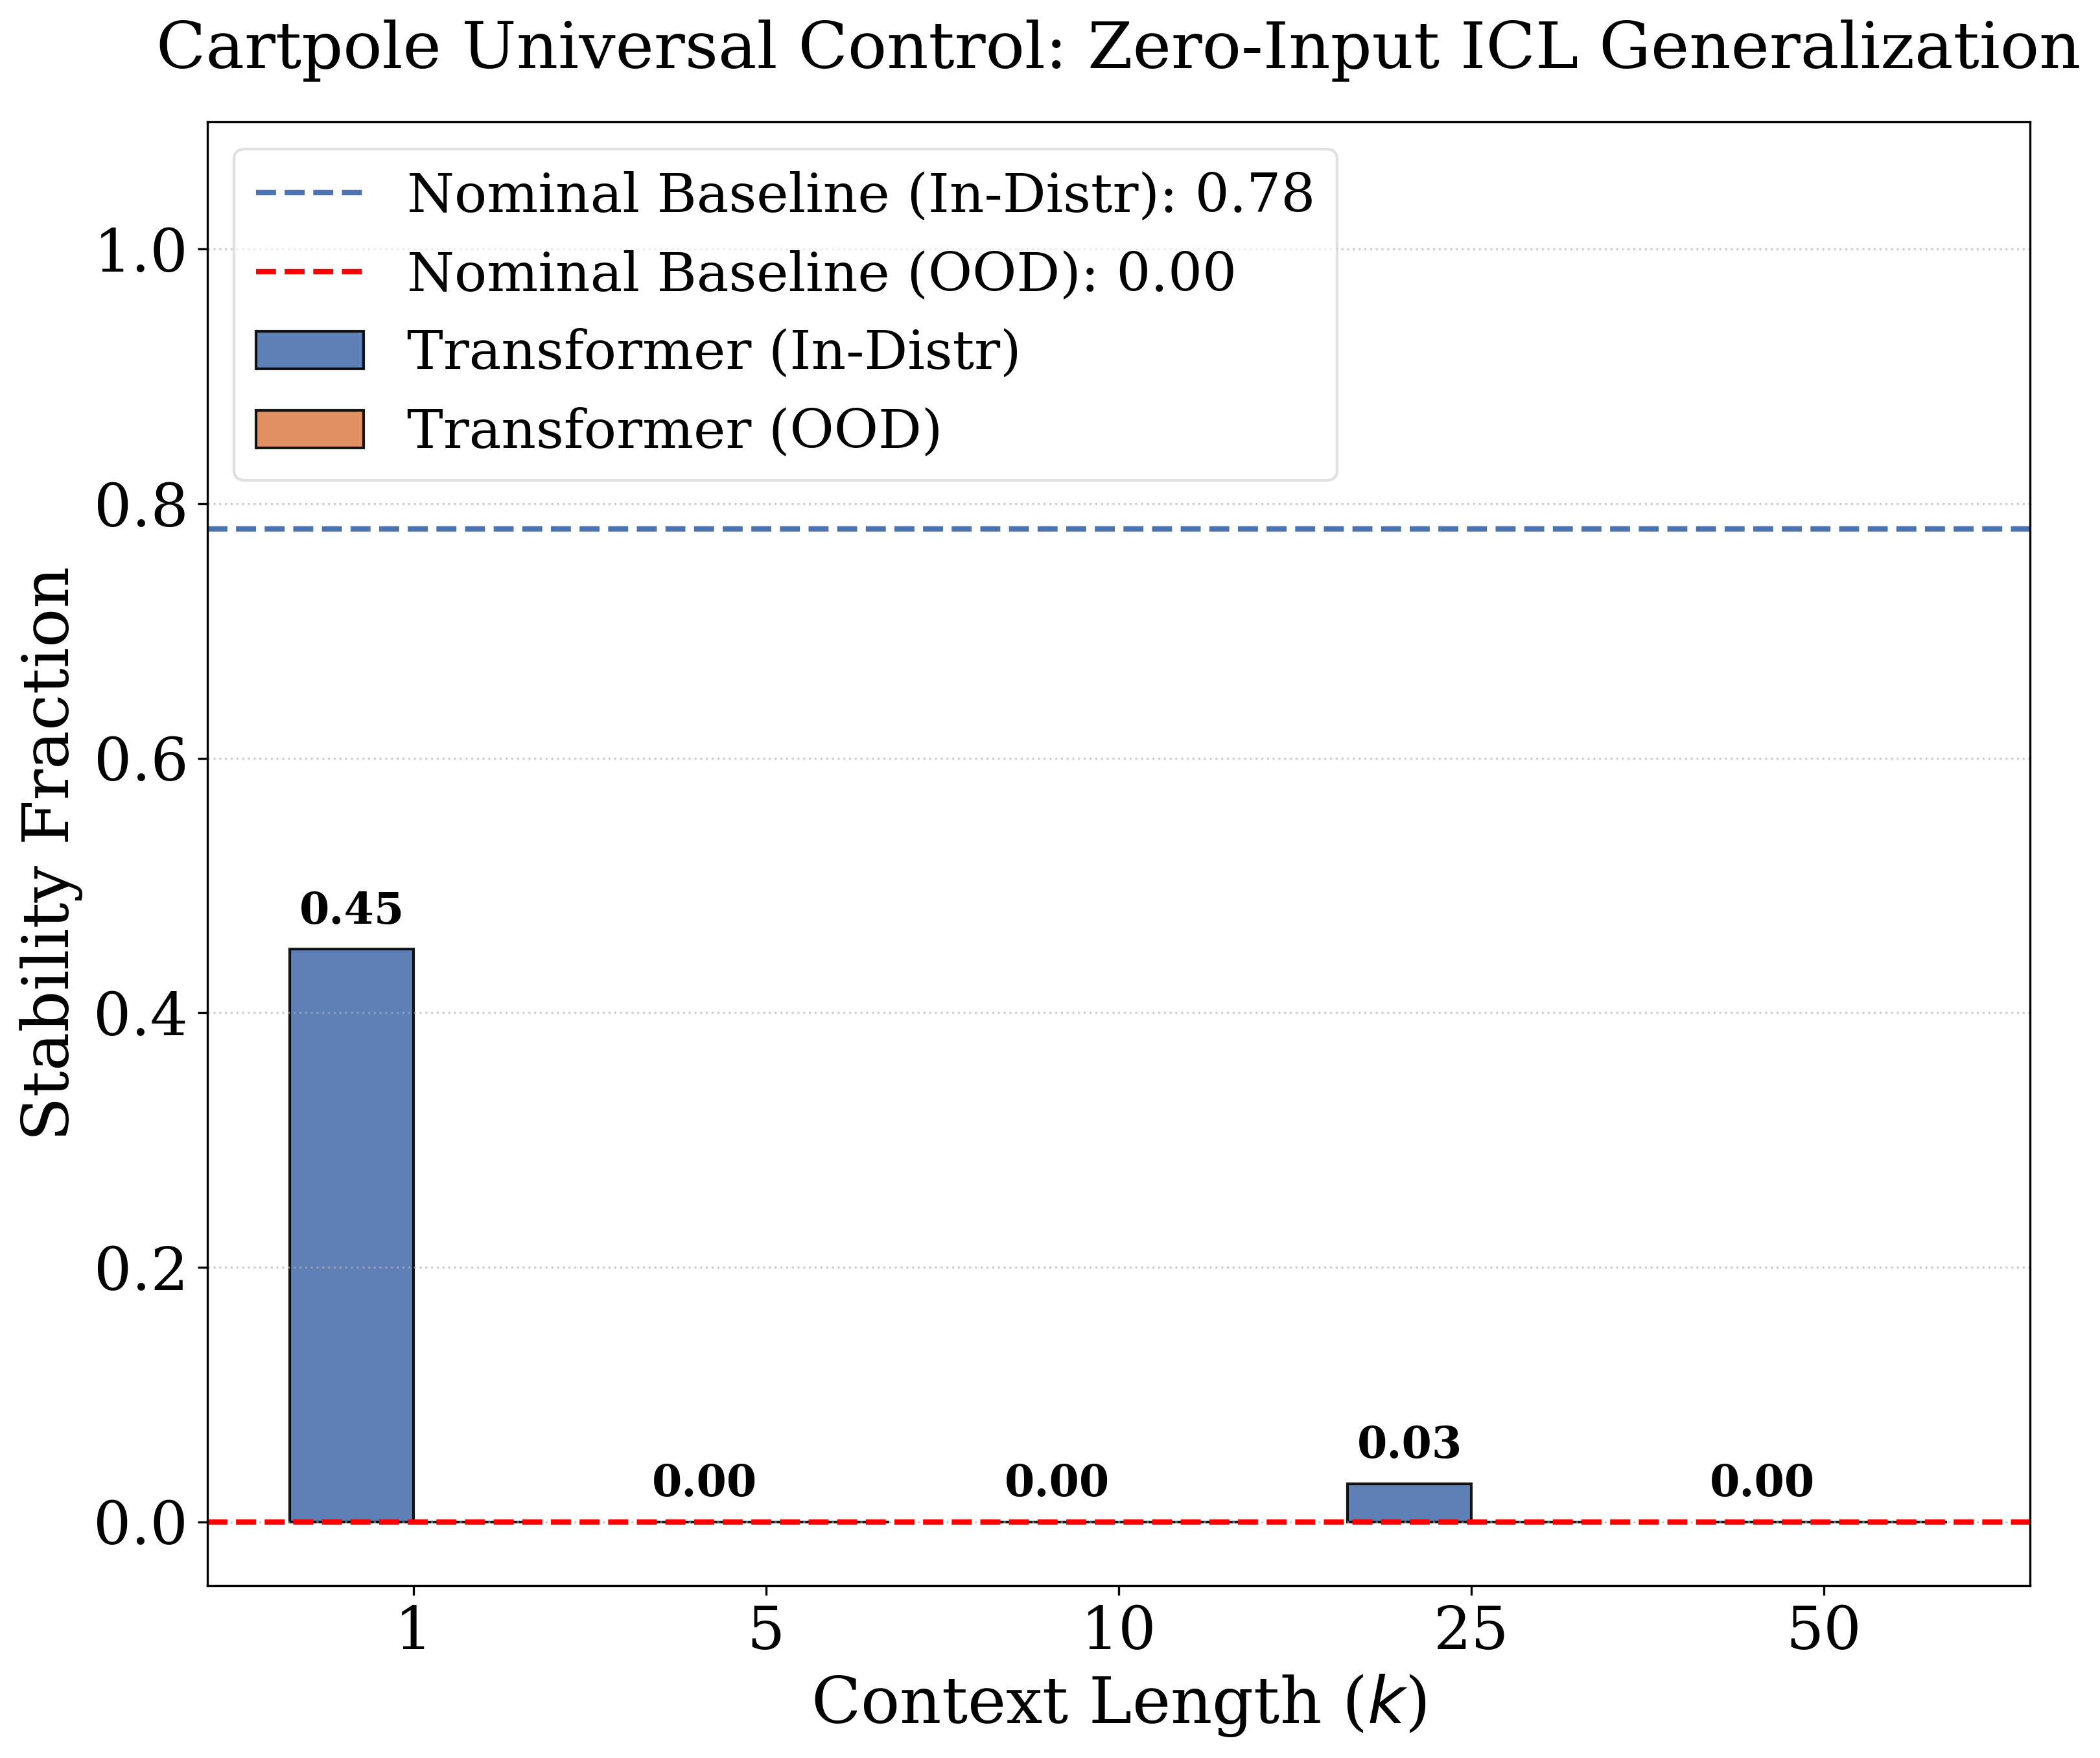

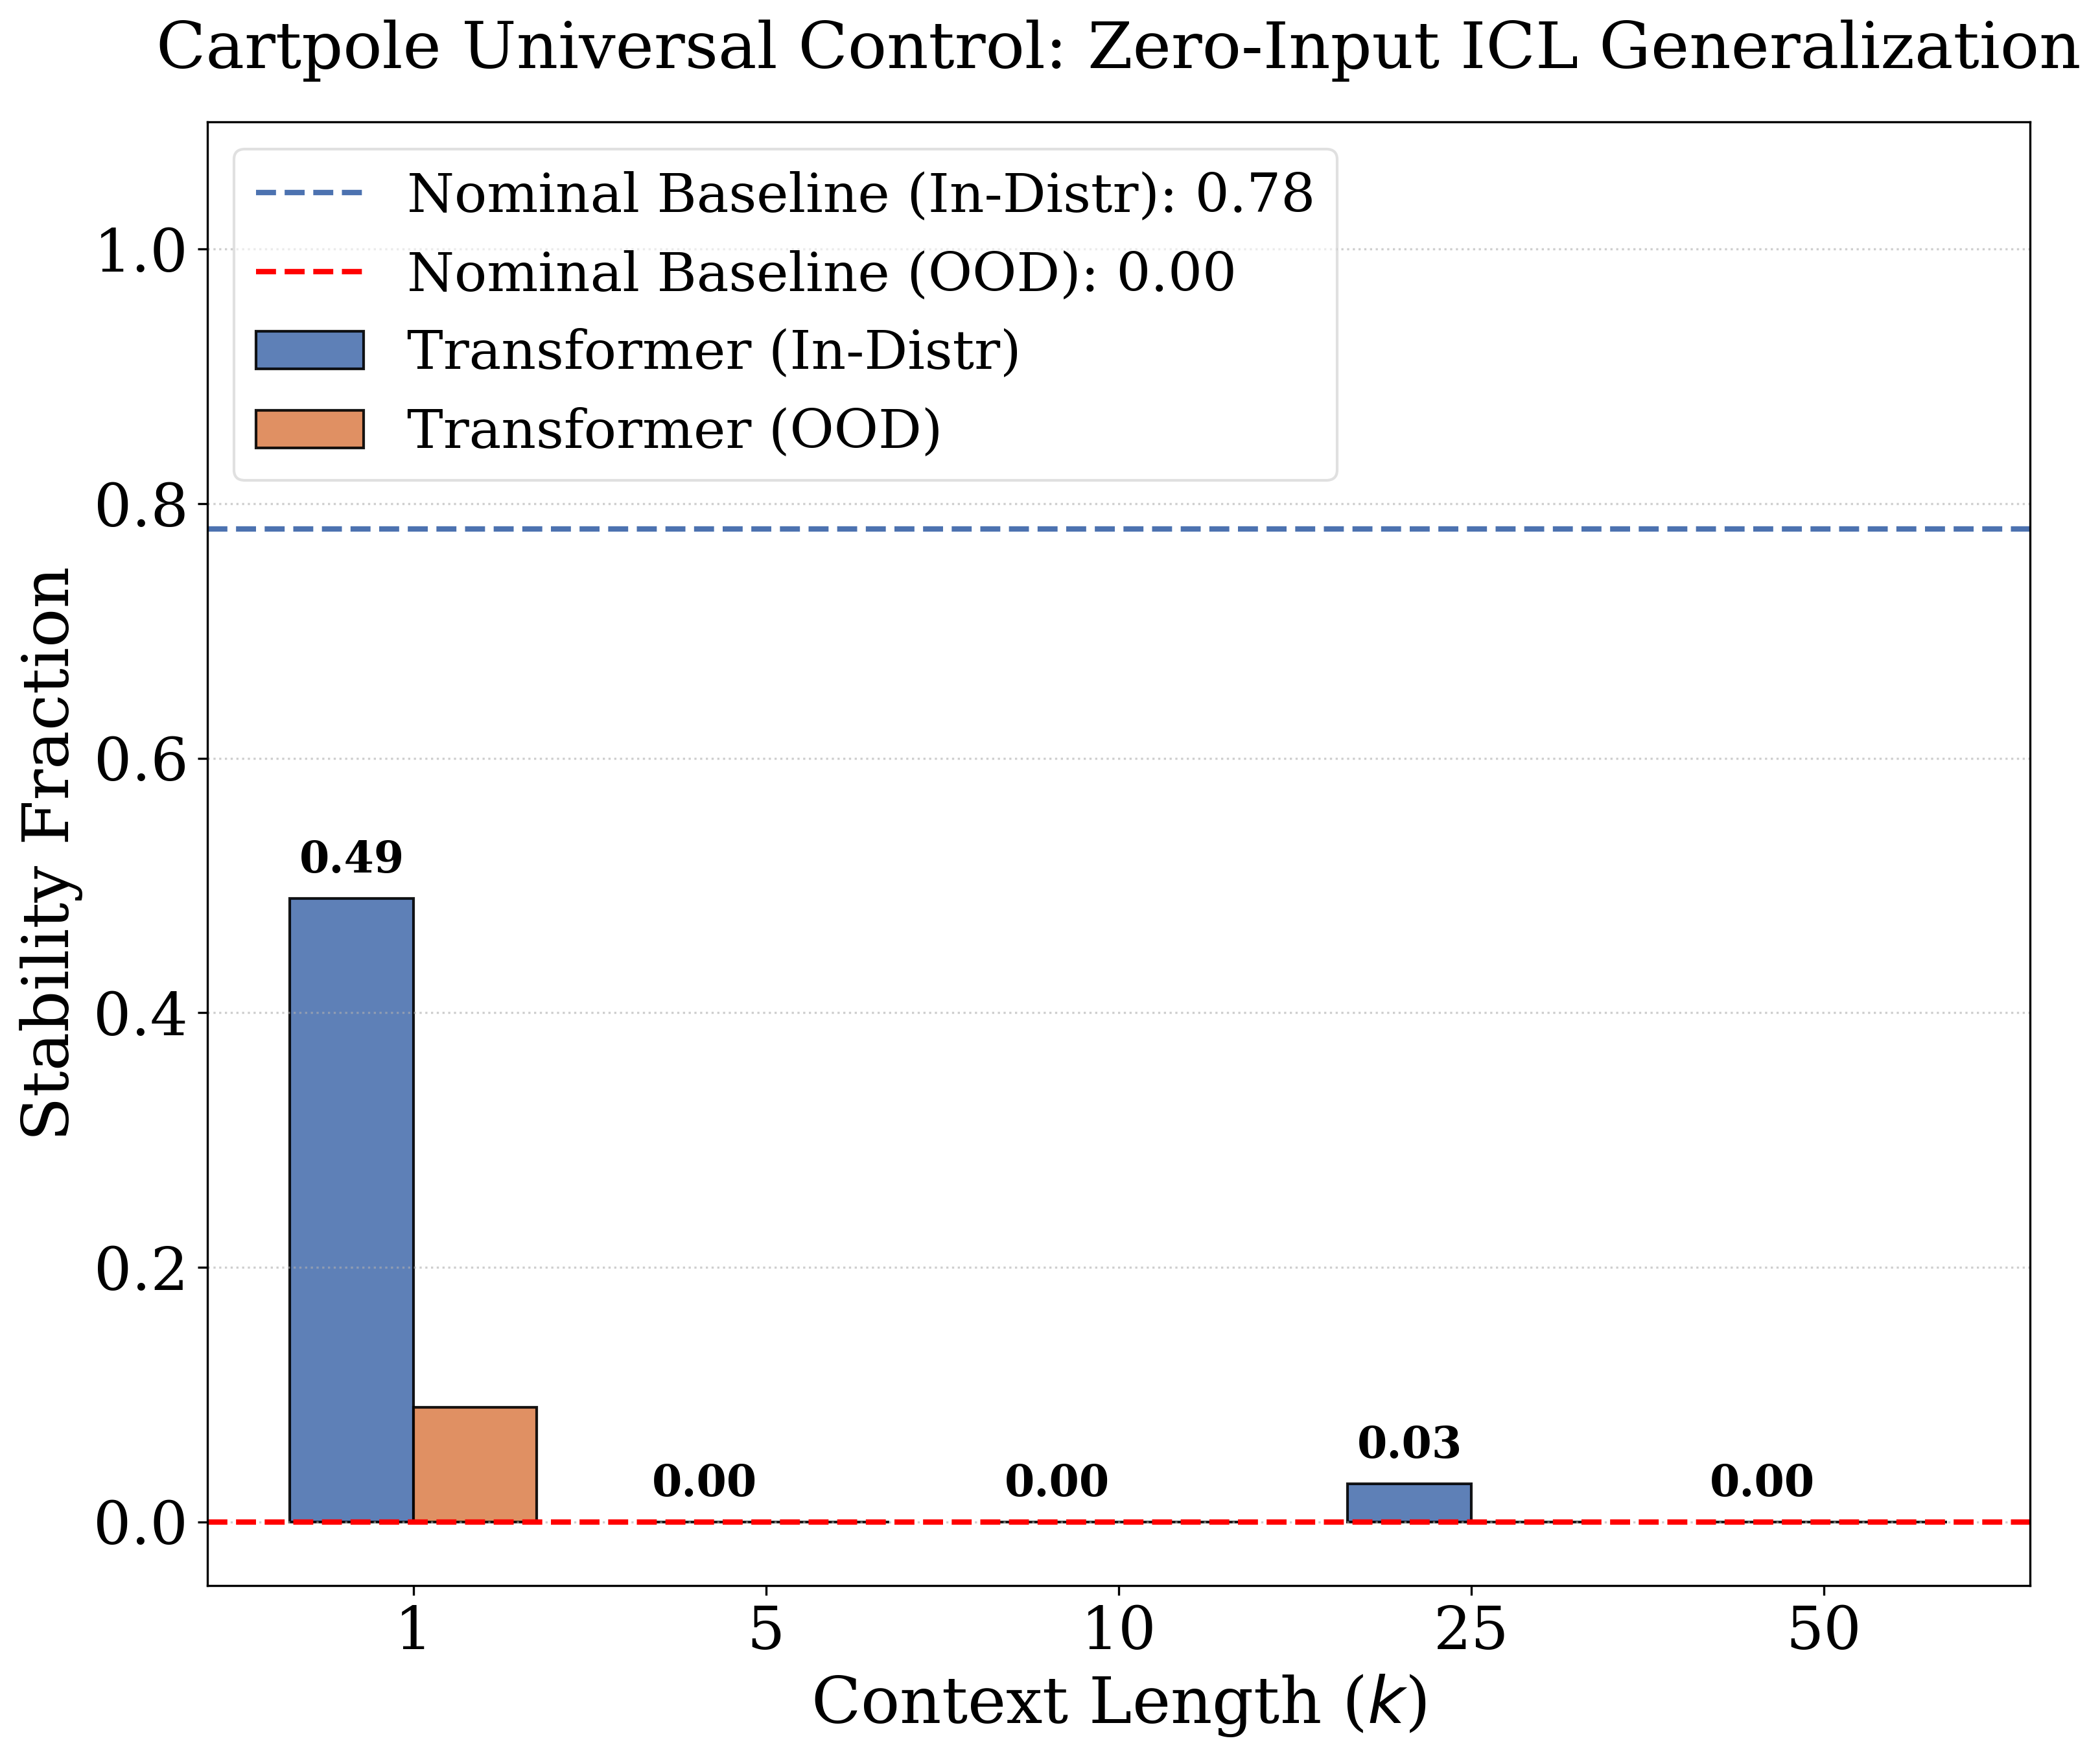

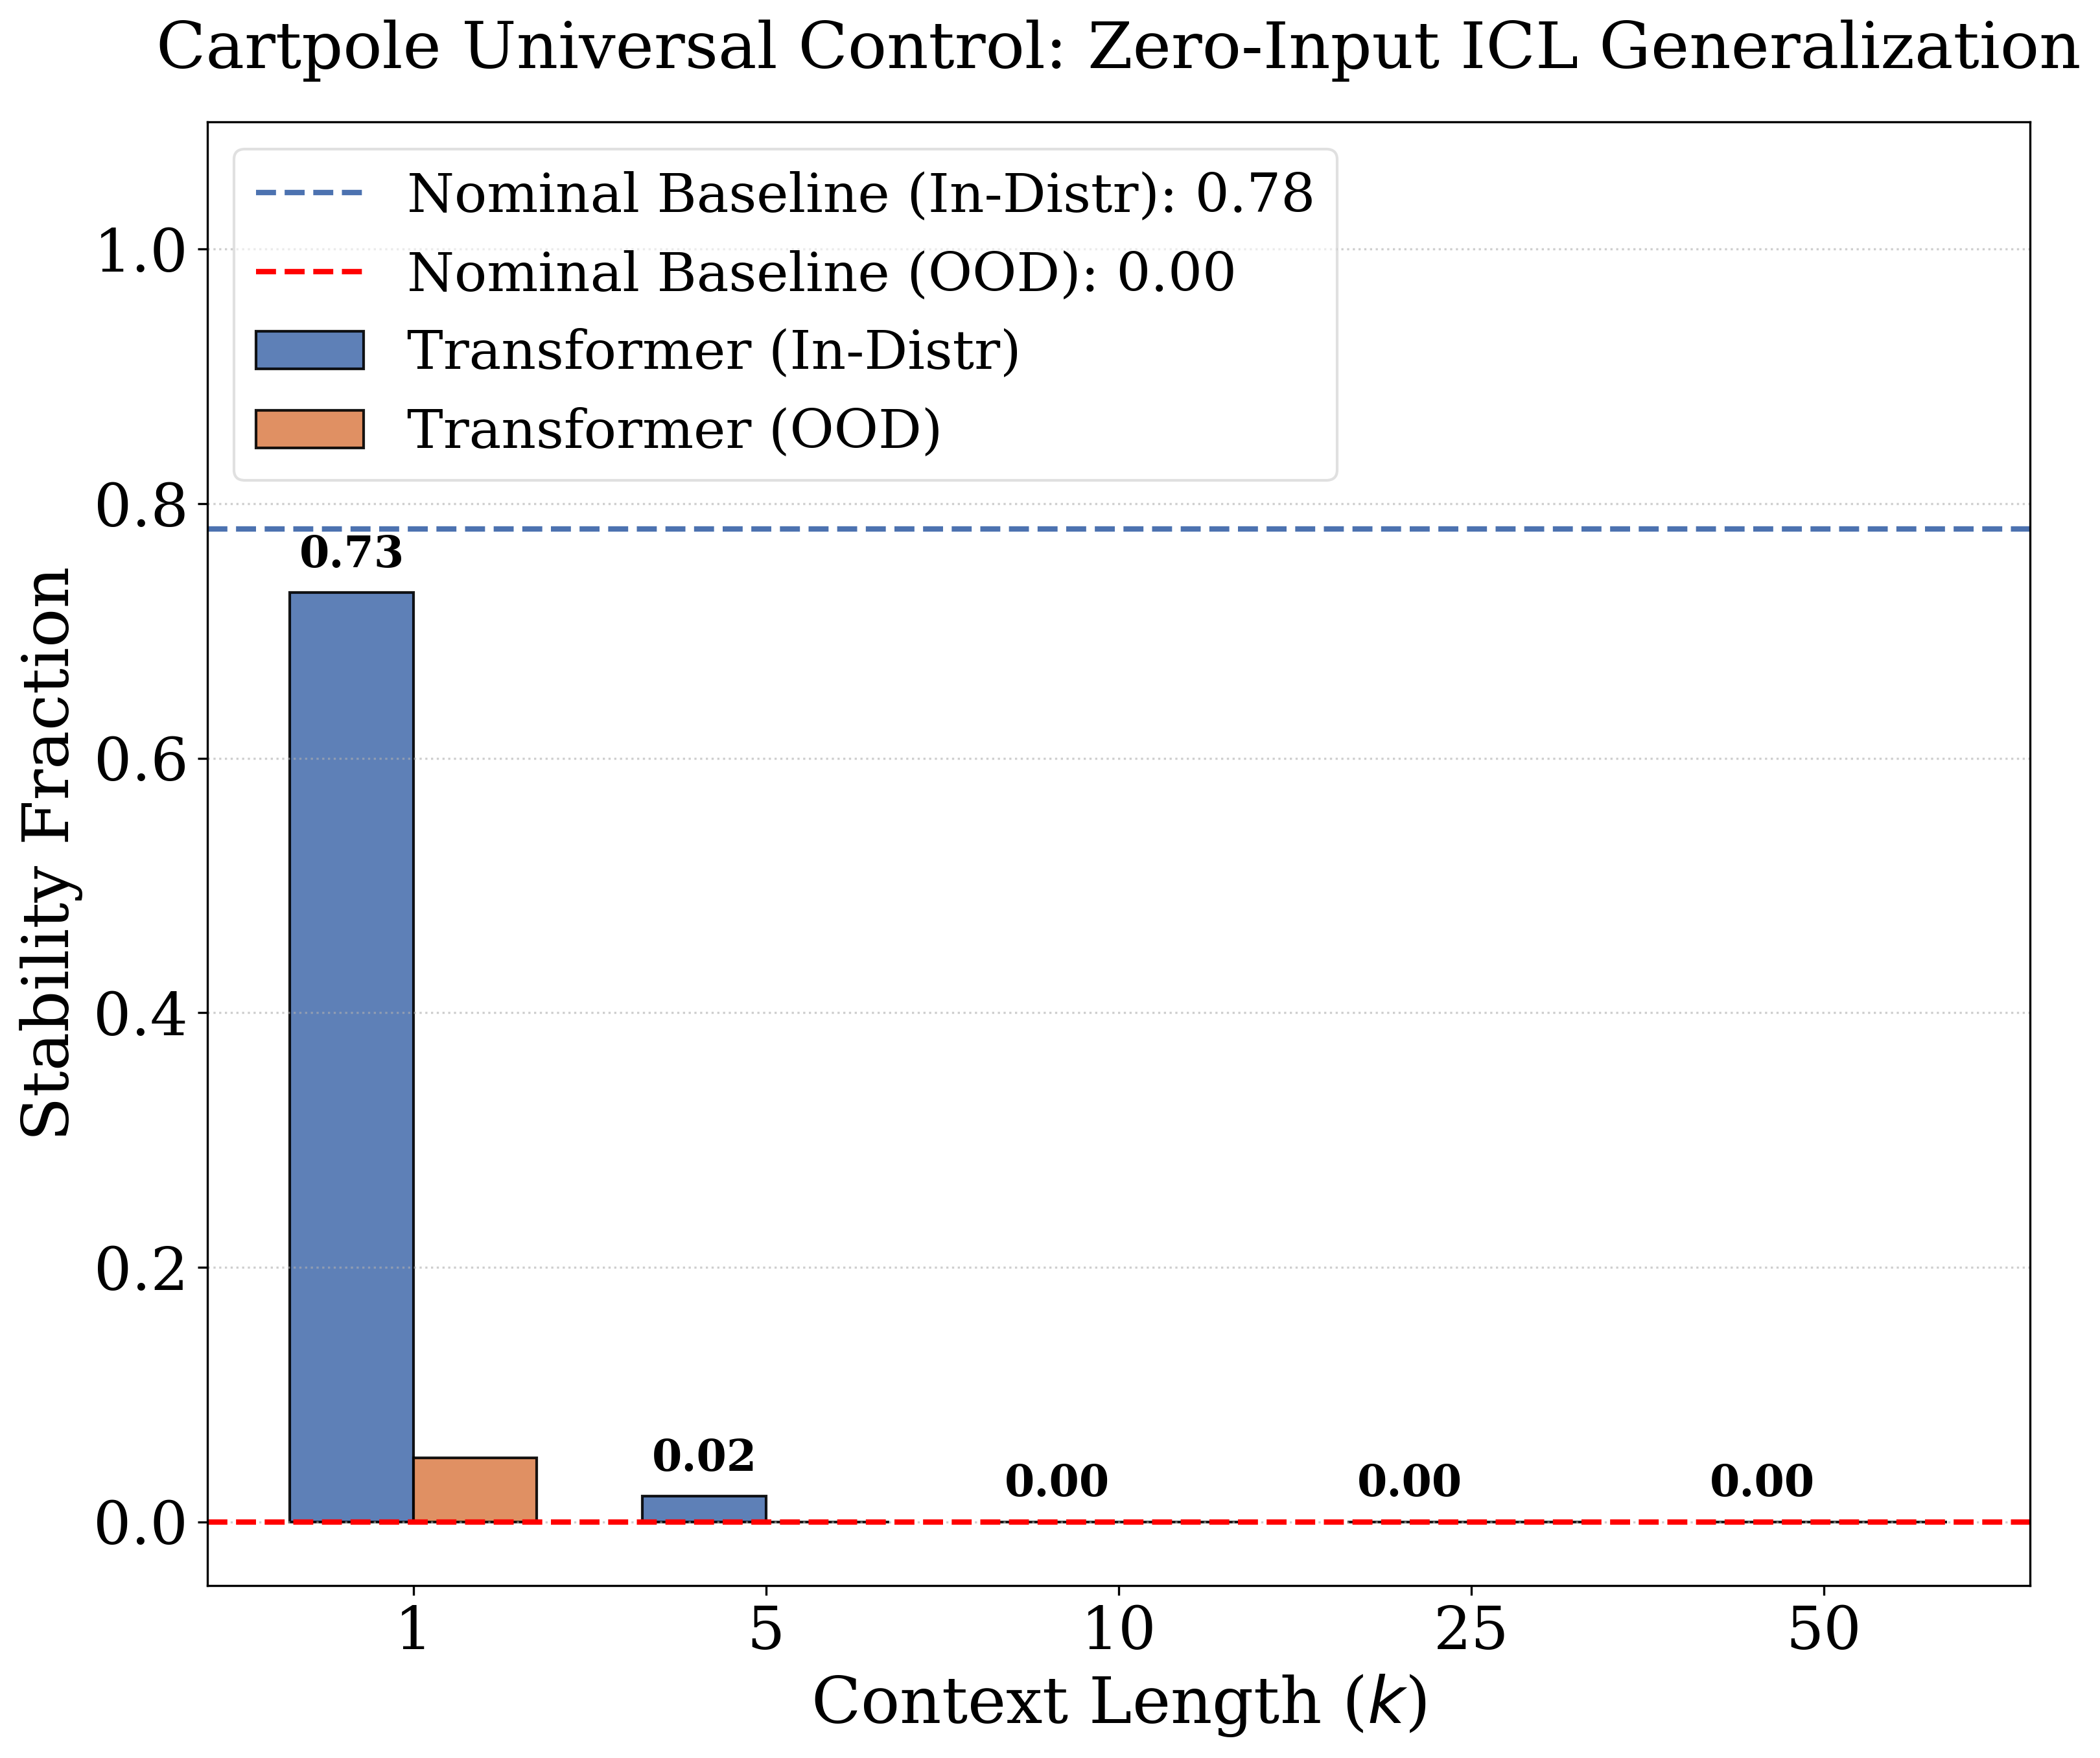

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# --- 1. SET PAPER-READY STYLING ---
plt.rcParams.update({
    'font.size': 22,
    'axes.labelsize': 24,
    'axes.titlesize': 24,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 20,
    'font.family': 'serif'
})

# --- 2. DATA PROCESSING ---
# Filter out the 'nominal' from the main grouped bars 
# and handle it as a separate scalar.
metric = 'stability_fraction'

for stp in steps_list2:
    fig, ax = plt.subplots(figsize=(11, 9.5))
    
    # Contexts for the X-axis
    sorted_contexts = sorted(contexts)
    x = np.arange(len(sorted_contexts))
    width = 0.35 
    
    # 3. PLOT TRANSFORMER DATA (In-Distr and OOD)
    # Filter data for this specific step
    step_data = df_plot[df_plot['step'] == stp]
    
    # In-Distribution Bars
    in_dist_vals = [step_data[(step_data['context'] == c) & (step_data['mode'] == 'indistr')]['value'].values[0] for c in sorted_contexts]
    ax.bar(x - width/2, in_dist_vals, width, label='Transformer (In-Distr)', color='#4C72B0', edgecolor='black', alpha=0.9)
    
    # OOD Bars
    ood_vals = [step_data[(step_data['context'] == c) & (step_data['mode'] == 'ood_hard')]['value'].values[0] for c in sorted_contexts]
    ax.bar(x + width/2, ood_vals, width, label='Transformer (OOD)', color='#DD8452', edgecolor='black', alpha=0.9)

    # 4. THE NOMINAL BASELINE (Reviewer 2 Defense)
    # Since it's 0.0, a horizontal line is hard to see. 
    # We plot it as a dashed line slightly above the axis for visibility, or at 0.
    # Note: These values come from evaluate_cartpole_nomctrlr.py results.
    nominal_val_indistr = 0.78
    ax.axhline(y=nominal_val_indistr, color='#4C72B0', linestyle='--', linewidth=2, label=f'Nominal Baseline (In-Distr): {nominal_val_indistr:.2f}')

    nominal_val = 0.0 
    ax.axhline(y=nominal_val, color='red', linestyle='--', linewidth=2, label=f'Nominal Baseline (OOD): {nominal_val:.2f}')
    
    # Add a text annotation near the axis to make the 0% "pop"
    # ax.text(len(sorted_contexts)-3, nominal_val + 0.02, 'Nominal Baseline = 0.0', color='red', 
    #         fontweight='bold', ha='right', va='bottom', fontsize=12)

    # ax.text(len(sorted_contexts)-3, nominal_val_indistr + 0.02, f'Nominal Baseline (In-Distr) = {nominal_val_indistr:.2f}', color='#4C72B0',
    #         fontweight='bold', ha='right', va='bottom', fontsize=12)

    # 5. FINAL POLISHING
    ax.set_ylabel('Stability Fraction')
    ax.set_xlabel(r'Context Length ($k$)')
    ax.set_title(f'Cartpole Universal Control: Zero-Input ICL Generalization', pad=20)
    
    ax.set_xticks(x)
    ax.set_xticklabels(sorted_contexts)
    ax.set_ylim(-0.05, 1.1) # Start slightly below 0 so the baseline line is visible
    
    # Put legend outside or in a clear spot
    ax.legend(loc='upper left', frameon=True, shadow=False, framealpha=0.6)
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    
    # Value labels for Transformer bars
    for i, v in enumerate(in_dist_vals):
        ax.text(i - width/2, v + 0.02, f'{v:.2f}', ha='center', fontsize=16, fontweight='bold')
    # for i, v in enumerate(ood_vals):
    #     ax.text(i + width/2, v + 0.02, f'{v:.2f}', ha='center', fontsize=16, fontweight='bold')

    plt.tight_layout()
    # plt.show()

    save_folder = "paper_plots_cartpole"
    os.makedirs(save_folder, exist_ok=True)
    if stp == 10000 or stp == 17000:
        # file_name = f'stability_comparison_step{stp}_paper.png'
        # file_name = f'stability_comparison_step{stp}_paper.pdf'
        # plt.savefig(os.path.join(save_folder, file_name))
        # save as pdf
        file_name = f'stability_comparison_step{stp}_paper.pdf'
        # plt.savefig(os.path.join(save_folder, file_name), format='pdf', bbox_inches='tight')
        print(f"Saved paper-ready plot: {file_name}")

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # 1. Setup Data (Example Fractions)
# N_labels = ['0', '10', '20', '50']
# # Converged Model Results
# conv_in   = [0.20, 0.60, 0.90, 0.98]
# conv_easy = [0.15, 0.45, 0.75, 0.85]
# conv_hard = [0.10, 0.30, 0.55, 0.65]
# # Early-Stopped Model Results
# early_in   = [0.05, 0.06, 0.07, 0.06]
# early_easy = [0.03, 0.04, 0.04, 0.03]
# early_hard = [0.02, 0.02, 0.02, 0.02]

# x = np.arange(len(N_labels))
# width = 0.14  # Narrower bars to fit 6 in a group

# fig, ax = plt.subplots(figsize=(10, 7))

# # Plotting Converged Group (Blues)
# ax.bar(x - 2.5*width, conv_in,   width, label='Conv: In-Distr', color='#08306b')
# ax.bar(x - 1.5*width, conv_easy, width, label='Conv: OOD Easy', color='#2171b5', hatch='//')
# ax.bar(x - 0.5*width, conv_hard, width, label='Conv: OOD Hard', color='#6baed6', hatch='///')

# # Plotting Early-Stopped Group (Greys)
# ax.bar(x + 0.5*width, early_in,   width, label='Early: In-Distr', color='#525252')
# ax.bar(x + 1.5*width, early_easy, width, label='Early: OOD Easy', color='#969696', hatch='\\\\')
# ax.bar(x + 2.5*width, early_hard, width, label='Early: OOD Hard', color='#d9d9d9', hatch='\\\\\\')

# # CDC/IEEE Professional Styling
# ax.set_ylabel('Stabilization Success Fraction', fontweight='bold')
# ax.set_xlabel('Unforced Response Context Length ($N$)', fontweight='bold')
# ax.set_title('Emergence of In-Context Stabilization and Robustness', fontsize=12)
# ax.set_xticks(x)
# ax.set_xticklabels(N_labels)
# ax.set_ylim(0, 1.15) # Room for legend

# # Put legend in two columns to save vertical space
# ax.legend(ncol=2, loc='upper left', fontsize='small', frameon=True)

# plt.grid(axis='y', linestyle='--', alpha=0.4)
# plt.tight_layout()
# # plt.savefig('6_group_results.pdf', dpi=300)
# plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np
# import os
# import matplotlib

# # --- 1. SET PAPER-READY STYLING ---
# matplotlib.rcParams['pdf.fonttype'] = 42 # Optional: For vector font support
# matplotlib.rcParams['ps.fonttype'] = 42
# plt.rcParams.update({
#     'font.size': 20, # Reduced size for 6-group charts
#     'axes.labelsize': 22,
#     'axes.titlesize': 22,
#     'xtick.labelsize': 20,
#     'ytick.labelsize': 20,
#     'legend.fontsize': 15, # Tight legend
#     'font.family': 'serif',
#     'axes.grid' : True, # Standard IEEE grid
#     'grid.alpha': 0.3
# })

# # --- 2. CONFIGURATION & MOCK DATA SETUP ---
# # Update with your actual steps/contexts
# stp_conv = 17000
# stp_early = 5000
# sorted_contexts = [1, 5, 10, 25, 50]

# # # --- 3. MOCK DATAFRAME GENERATION (Skip if loading real data) ---
# # # (Included to make the script runnable, replace with your df_plot)
# # data = []
# # for c in sorted_contexts:
# #     # Converged (Blues Family: Deep -> Medium -> Light)
# #     data.append({'context': c, 'step': stp_conv, 'mode': 'indistr',   'value': 0.15 + (c/100)}) # Increasing with context for demo
# #     data.append({'context': c, 'step': stp_conv, 'mode': 'ood_easy',  'value': 0.10 + (c/120)})
# #     data.append({'context': c, 'step': stp_conv, 'mode': 'ood_hard',  'value': 0.05 + (c/150)})
    
# #     # Early-Stopped (Greys Family: Dark -> Medium -> Light)
# #     data.append({'context': c, 'step': stp_early, 'mode': 'indistr',  'value': 0.03 + (c/500)})
# #     data.append({'context': c, 'step': stp_early, 'mode': 'ood_easy', 'value': 0.02 + (c/600)})
# #     data.append({'context': c, 'step': stp_early, 'mode': 'ood_hard', 'value': 0.01 + (c/700)})

# # df_plot = pd.DataFrame(data)

# # --- 3. DATA LOADING 
# data = []
# for stp in steps_list2:
#     for ctx in contexts:
#         for mode in modes:
#             val = results2[metric].get((stp, ctx, mode), 0.0)
#             data.append({
#                 'step': stp,
#                 'context': ctx,
#                 'mode': mode,
#                 'value': val
#             })
#         # Add Nominal Baseline (Hardcoded 0 as per your finding)
#         data.append({
#             'step': stp,
#             'context': ctx,
#             'mode': 'nominal',
#             'value': 0.0
#         })
# df_plot = pd.DataFrame(data)
# converged_easy_data = [0.25, 0.17, 0.22, 0.72, 0.96] # Actual values from results picke file


# # --- 4. PLOTTING INITIALIZATION ---
# fig, ax = plt.subplots(figsize=(14, 8)) # Wider aspect ratio for dense bars
# x = np.arange(len(sorted_contexts))
# width = 0.13 # Narrower width to fit 6 in a group

# # Helper to fetch data series from df
# # def get_vals(step, mode_str):
# #     vals = []
# #     for c in sorted_contexts:
# #         row = df_plot[(df_plot['step'] == step) & (df_plot['mode'] == mode_str) & (df_plot['context'] == c)]
# #         vals.append(row['value'].values[0] if not row.empty else 0.0)
# #     return vals

# # --- 5. DATA EXTRACTION ---
# # Converged Series
# conv_in    = get_vals(stp_conv, 'indistr')
# conv_easy  = get_vals(stp_conv, 'ood_easy')
# conv_hard  = get_vals(stp_conv, 'ood_hard')

# # Early Series
# early_in   = get_vals(stp_early, 'indistr')
# early_easy = get_vals(stp_early, 'ood_easy')
# early_hard = get_vals(stp_early, 'ood_hard')

# # --- 6. PLOTTING THE 6 GROUPS (SOLID COLORS) ---
# # Offsets: -2.5w, -1.5w, -0.5w, +0.5w, +1.5w, +2.5w
# # Converged Model (Blues)
# ax.bar(x - 2.5*width, conv_in,   width, label='Conv: In-Distr', color='#08306b', edgecolor='black')
# ax.bar(x - 1.5*width, conv_easy, width, label='Conv: OOD Easy', color='#2171b5', edgecolor='black')
# ax.bar(x - 0.5*width, conv_hard, width, label='Conv: OOD Hard', color='#6baed6', edgecolor='black')

# # Early Model (Greys)
# ax.bar(x + 0.5*width, early_in,   width, label='Early: In-Distr', color='#525252', edgecolor='black')
# ax.bar(x + 1.5*width, early_easy, width, label='Early: OOD Easy', color='#969696', edgecolor='black')
# ax.bar(x + 2.5*width, early_hard, width, label='Early: OOD Hard', color='#d9d9d9', edgecolor='black')

# # --- 7. POLISHING & EXTRAS ---
# ax.set_ylabel('Stability Fraction', fontweight='bold')
# ax.set_xlabel(r'Context Length ($N$)', fontweight='bold')
# ax.set_title(f'In-Context Generalization: Model Maturity vs. Distribution Difficulty', pad=15)

# ax.set_xticks(x)
# ax.set_xticklabels(sorted_contexts)
# ax.set_ylim(-0.02, 1.15) # Leave room for legend/labels
# ax.grid(axis='y', linestyle=':', alpha=0.4)

# # Put legend in two columns for 6 distinct bar types
# ax.legend(loc='upper left', ncol=2, frameon=True, fontsize=14, framealpha=0.6)

# # Add value labels (Selective or rotated for clutter)
# for i, v in enumerate(conv_in):
#     if v > 0.05:
#         ax.text(i - 2.5*width, v + 0.01, f'{v:.2f}', ha='center', fontsize=10, rotation=90)

# plt.tight_layout()

# save_folder = "paper_plots_cartpole"
# os.makedirs(save_folder, exist_ok=True)
# file_name = f'stability_comparison_6group_solid.pdf'
# # plt.savefig(os.path.join(save_folder, file_name), format='pdf', bbox_inches='tight')
# print(f"Saved 6-group solid plot: {file_name}")
# plt.show() # Optional for interactive verification

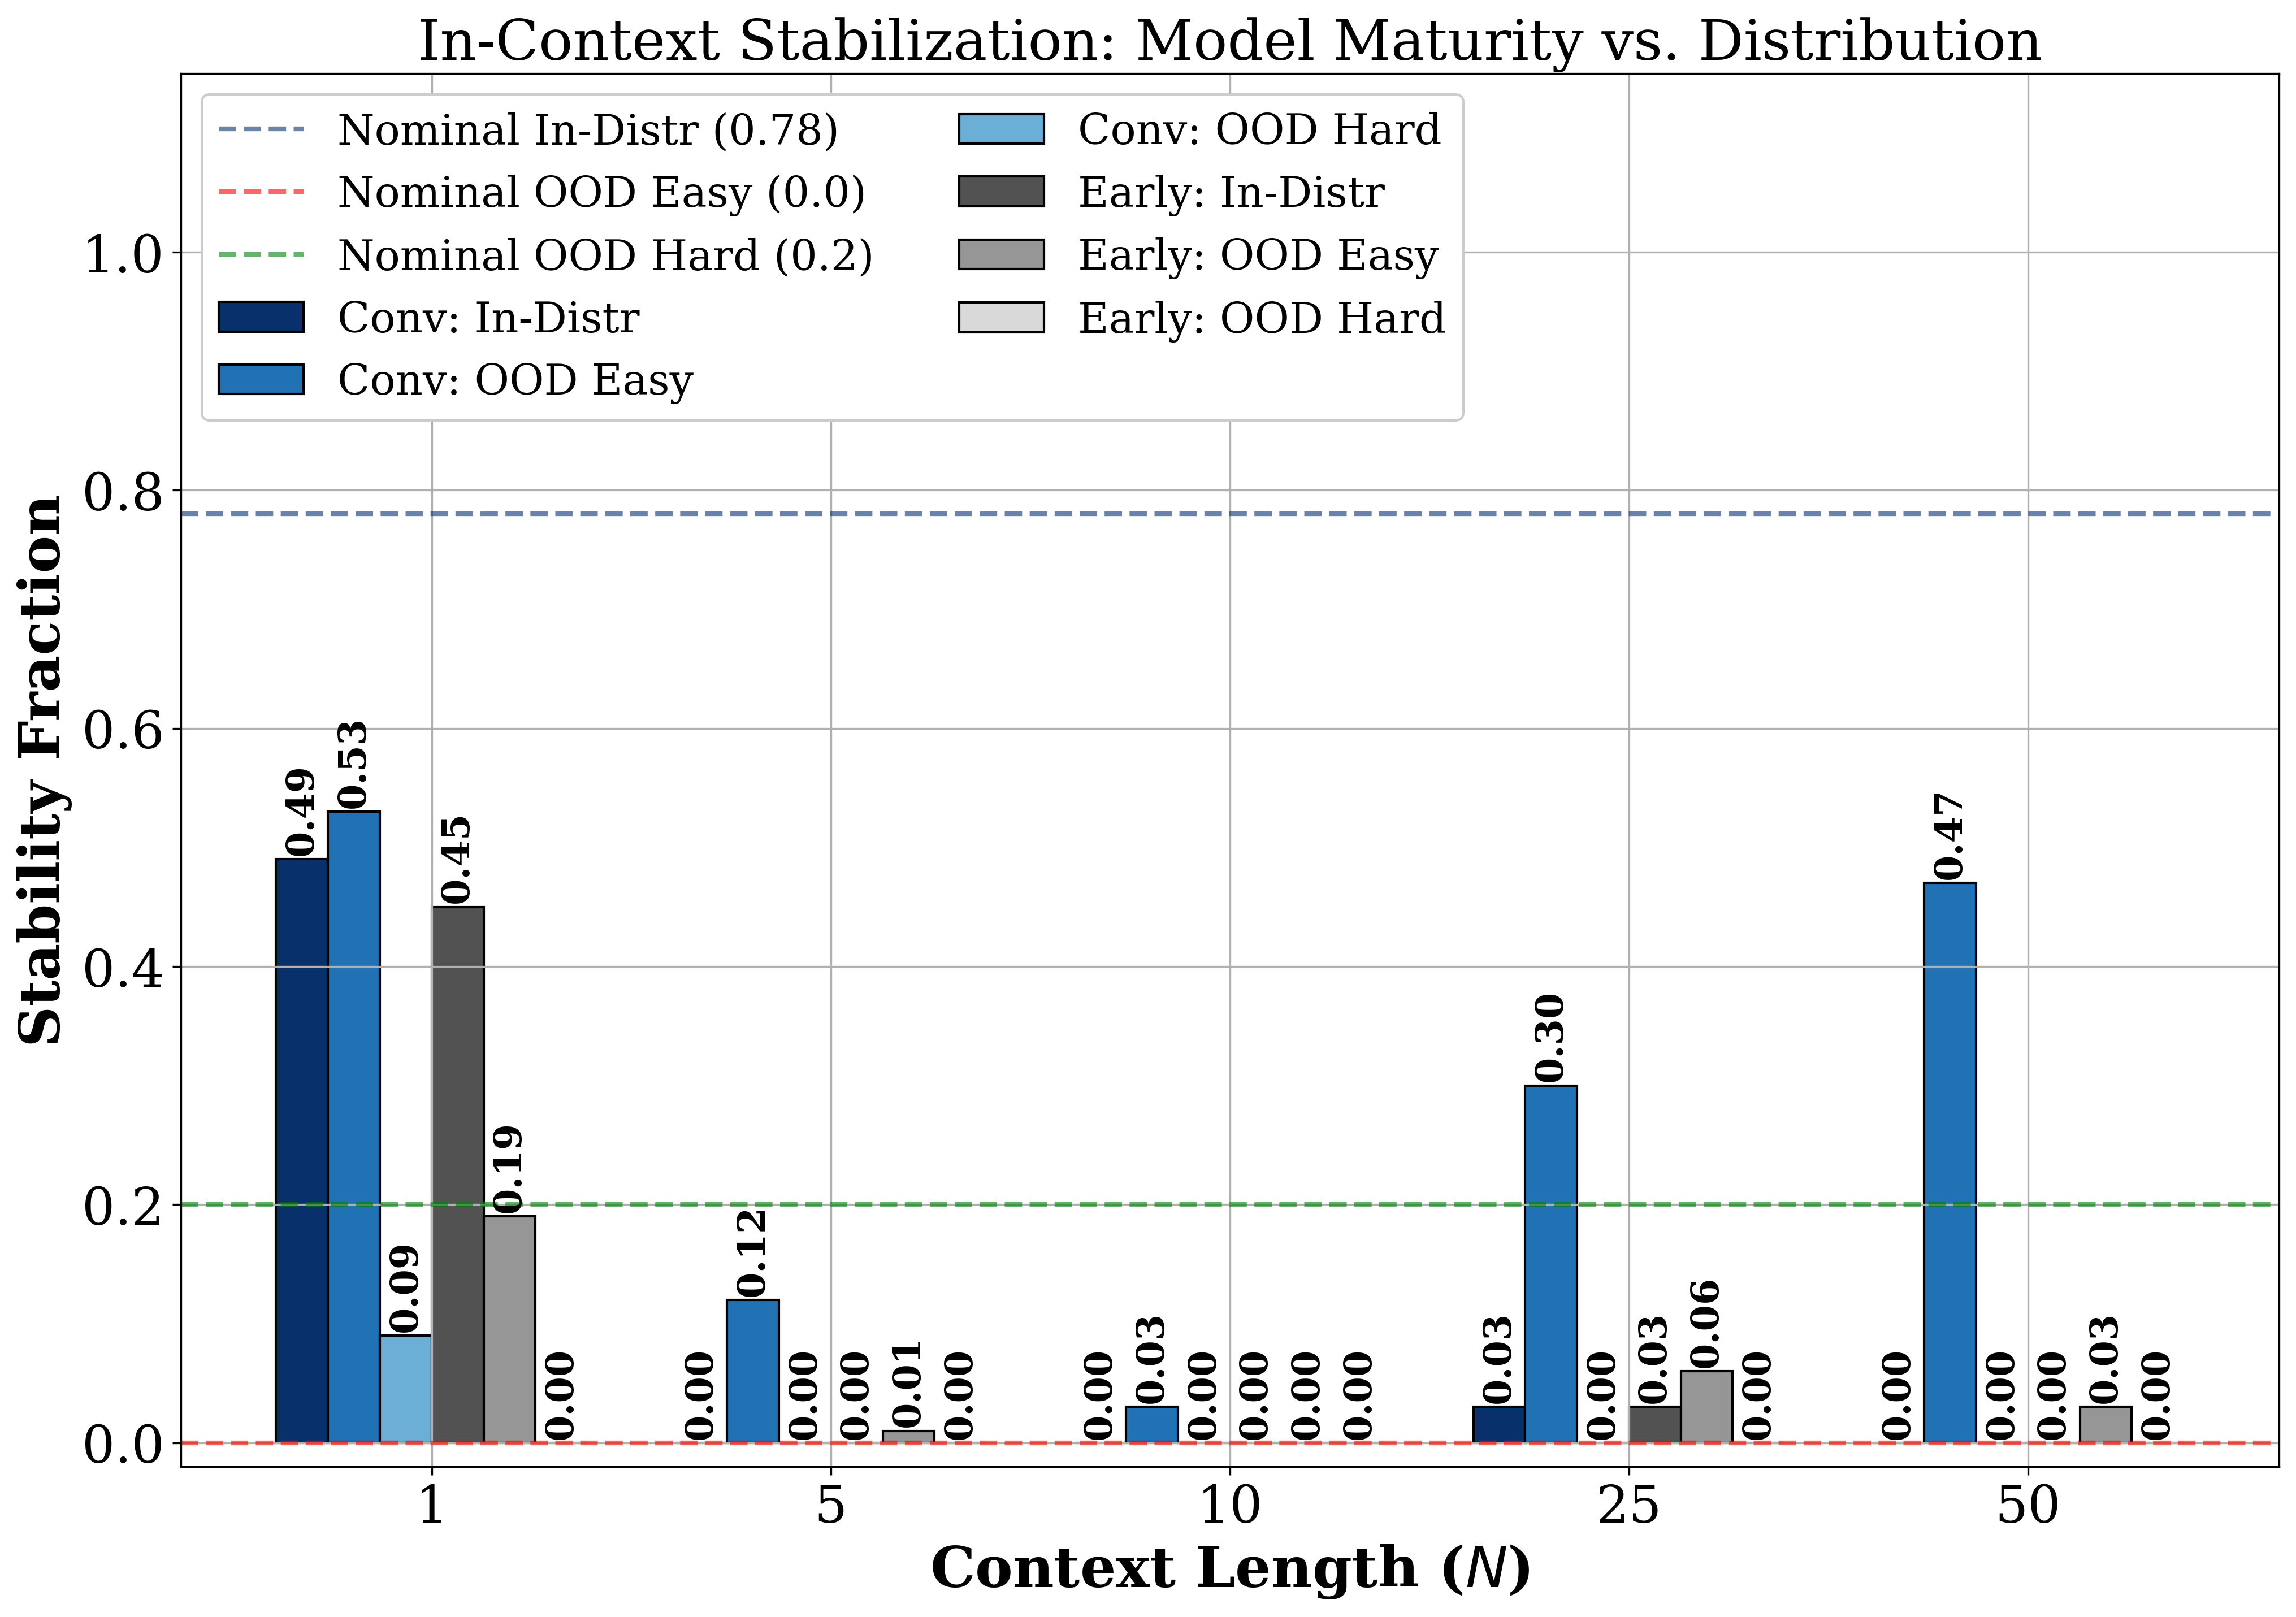

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import matplotlib

# --- 1. SET PAPER-READY STYLING ---
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams.update({
    'font.size': 22,
    'axes.labelsize': 24,
    'axes.titlesize': 24,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 18,
    'font.family': 'serif',
    'axes.grid' : True,
    'grid.alpha': 1.0
})

# --- 2. CONFIGURATION ---
# Assumes steps_list2 = [early_step, converged_step]
stp_early = steps_list2[0]  
stp_conv = steps_list2[1]   
sorted_contexts = [1, 5, 10, 25, 50]

# --- 3. DATA LOADING ---
data = []
for stp in steps_list2:
    for ctx in sorted_contexts:
        # Load from your results2 dictionary
        for mode in ['indistr', 'ood_hard', 'ood_easy']: #_easy', 'ood_hard']:
            val = results2[metric].get((stp, ctx, mode), 0.0)
            data.append({
                'step': stp,
                'context': ctx,
                'mode': mode,
                'value': val
            })
        # Add Nominal Baseline
        data.append({
            'step': stp,
            'context': ctx,
            'mode': 'nominal',
            'value': 0.0
        })

df_plot = pd.DataFrame(data)

# --- 4. MANUAL OVERRIDES / SPECIFIC LISTS ---
# Since you provided a specific list for converged_easy, we inject it here
# conv_easy_vals = [0.25, 0.17, 0.22, 0.72, 0.96] 

# --- 5. DATA EXTRACTION FOR PLOTTING ---
def get_vals(step, mode_str):
    # Special case for the manual list you provided
    # if step == stp_conv and mode_str == 'ood_easy':
        # return conv_easy_vals
    
    vals = []
    for c in sorted_contexts:
        row = df_plot[(df_plot['step'] == step) & (df_plot['mode'] == mode_str) & (df_plot['context'] == c)]
        vals.append(row['value'].values[0] if not row.empty else 0.0)
    return vals

# Extract the 6 Series
conv_in    = get_vals(stp_conv, 'indistr')
conv_easy  = get_vals(stp_conv, 'ood_easy')
conv_hard  = get_vals(stp_conv, 'ood_hard')

early_in   = get_vals(stp_early, 'indistr')
early_easy = get_vals(stp_early, 'ood_easy')
early_hard = get_vals(stp_early, 'ood_hard')

# --- 6. PLOTTING ---
fig, ax = plt.subplots(figsize=(14, 10))
x = np.arange(len(sorted_contexts))
width = 0.13 

# Converged Group (Blues: Deep -> Med -> Light)
ax.bar(x - 2.5*width, conv_in,   width, label='Conv: In-Distr', color='#08306b', edgecolor='black')
ax.bar(x - 1.5*width, conv_easy, width, label='Conv: OOD Easy', color='#2171b5', edgecolor='black')
ax.bar(x - 0.5*width, conv_hard, width, label='Conv: OOD Hard', color='#6baed6', edgecolor='black')

# Early-Stopped Group (Greys: Dark -> Med -> Light)
ax.bar(x + 0.5*width, early_in,   width, label='Early: In-Distr', color='#525252', edgecolor='black')
ax.bar(x + 1.5*width, early_easy, width, label='Early: OOD Easy', color='#969696', edgecolor='black')
ax.bar(x + 2.5*width, early_hard, width, label='Early: OOD Hard', color='#d9d9d9', edgecolor='black')

# --- 7. BASELINE ---
nom_in_val = 0.78
ax.axhline(y=nom_in_val, color='#08306b', linestyle='--', linewidth=2, alpha=0.6, label=f'Nominal In-Distr ({nom_in_val})')
nom_ood_val = 0.0
ax.axhline(y=nom_ood_val, color='red', linestyle='--', linewidth=2, alpha=0.6, label=f'Nominal OOD Easy ({nom_ood_val})')
nom_ood_hard_val = 0.2
ax.axhline(y=nom_ood_hard_val, color='green', linestyle='--', linewidth=2, alpha=0.6, label=f'Nominal OOD Hard ({nom_ood_hard_val})')
# --- 8. FINAL POLISHING ---
ax.set_ylabel('Stability Fraction', fontweight='bold')
ax.set_xlabel(r'Context Length ($N$)', fontweight='bold')
ax.set_title('In-Context Stabilization: Model Maturity vs. Distribution')

ax.set_xticks(x)
ax.set_xticklabels(sorted_contexts)
ax.set_ylim(-0.02, 1.15) 

ax.legend(loc='upper left', ncol=2, frameon=True, framealpha=1.0)

# Value labels for the Converged In-Distr series to show the "Target" performance
# for i, v in enumerate(conv_in):
#     ax.text(i - 2.5*width, v + 0.01, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold', rotation=90)

# Value labels for all bars (optional, can be cluttered)
for i, v in enumerate(conv_in):
    # if v > 0.0:
    ax.text(i - 2.5*width, v + 0.01, f'{v:.2f}', ha='center', fontsize=16, fontweight='bold', rotation=90)
for i, v in enumerate(conv_easy):
    # if v > 0.0:
    ax.text(i - 1.5*width, v + 0.01, f'{v:.2f}', ha='center', fontsize=16, fontweight='bold', rotation=90)
for i, v in enumerate(conv_hard):
    # if v > 0.0:
    ax.text(i - 0.5*width, v + 0.01, f'{v:.2f}', ha='center', fontsize=16, fontweight='bold', rotation=90)
for i, v in enumerate(early_in):
    # if v > 0.0:
    ax.text(i + 0.5*width, v + 0.01, f'{v:.2f}', ha='center', fontsize=16, fontweight='bold', rotation=90)
for i, v in enumerate(early_easy):
    # if v > 0.0:
    ax.text(i + 1.5*width, v + 0.01, f'{v:.2f}', ha='center', fontsize=16, fontweight='bold', rotation=90)
for i, v in enumerate(early_hard):
    # if v > 0.0:
    ax.text(i + 2.5*width, v + 0.01, f'{v:.2f}', ha='center', fontsize=16, fontweight='bold', rotation=90)


plt.tight_layout()
# save_path = "paper_plots_cartpole/stability_6group_final.pdf"
# os.makedirs("paper_plots_cartpole", exist_ok=True)
# plt.savefig(save_path, bbox_inches='tight')
# print(f"Plot saved to {save_path}")
plt.show()

Split plot saved to test_plots_cartpole/stability_comparison_split_nozerodyntrain_zerodyninf.pdf


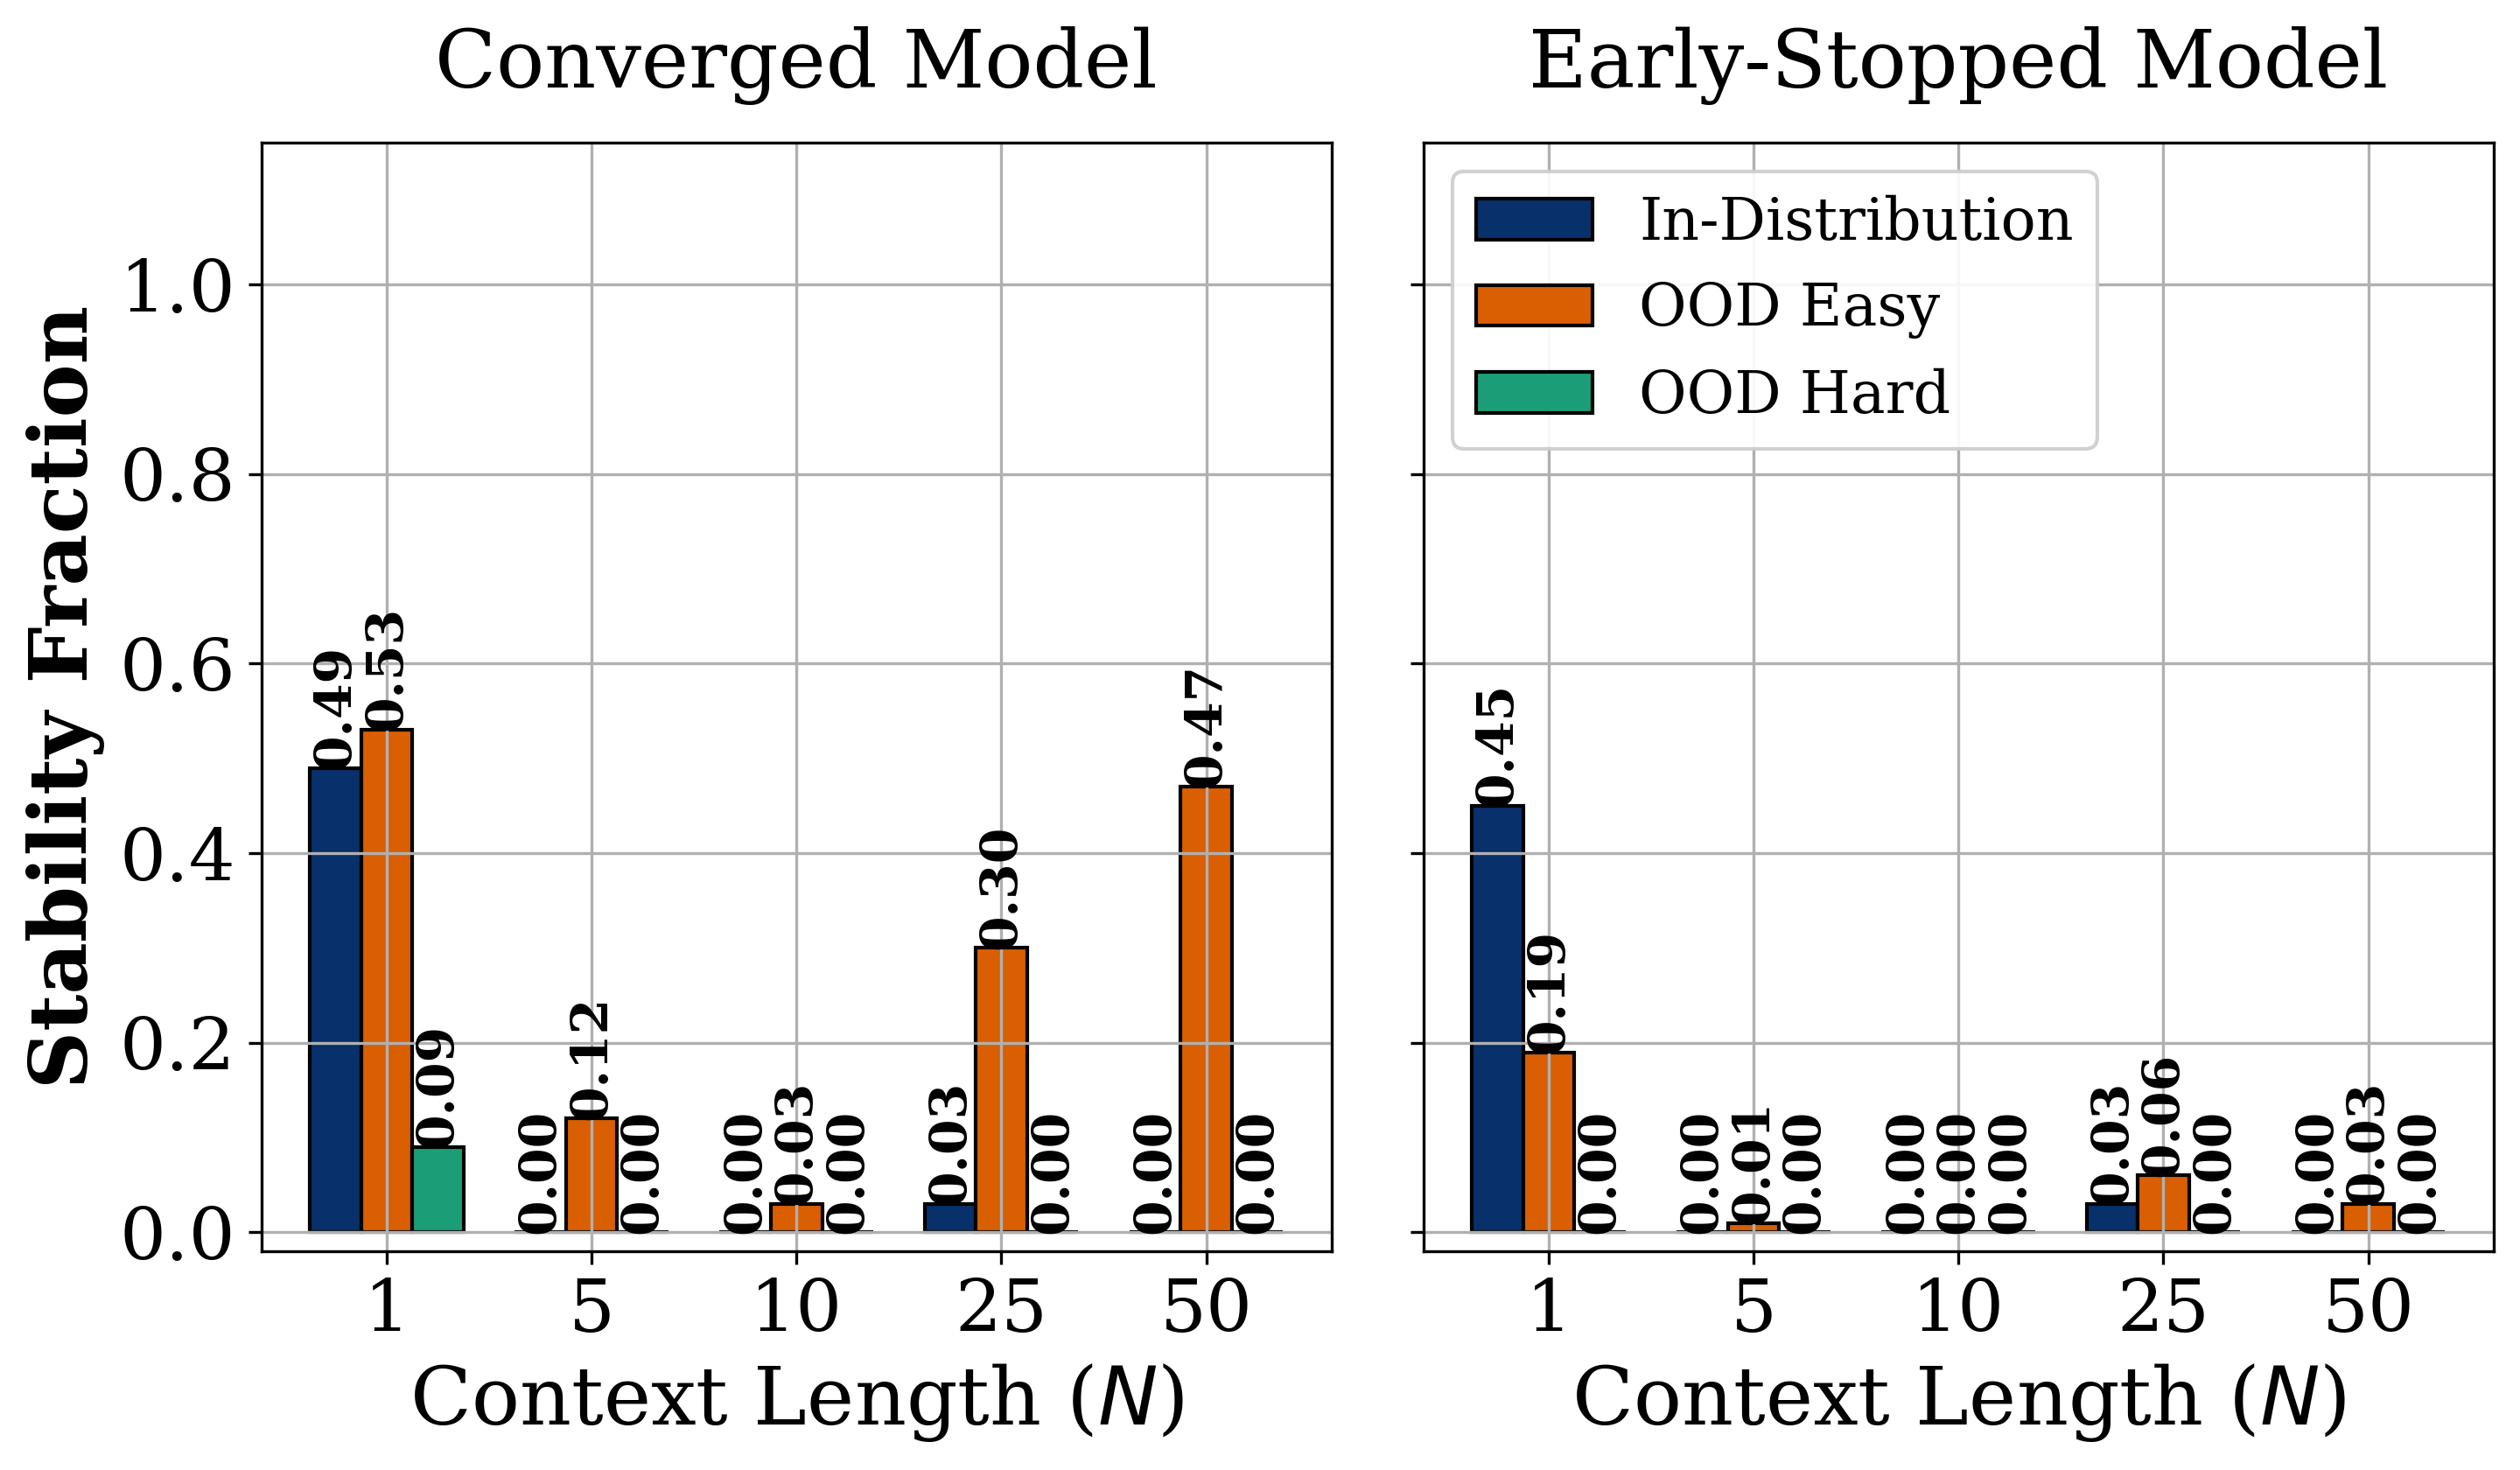

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import matplotlib

# --- 1. SET PAPER-READY STYLING ---
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 22,
    'axes.titlesize': 22,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 16,
    'font.family': 'serif',
    'axes.grid' : True,
    'grid.alpha': 1.0
})
# plt.rcParams.update({
#     'font.size': 22,
#     'axes.labelsize': 24,
#     'axes.titlesize': 24,
#     'xtick.labelsize': 22,
#     'ytick.labelsize': 22,
#     'legend.fontsize': 18,
#     'font.family': 'serif',
#     'axes.grid' : True,
#     'grid.alpha': 0.3
# })

# --- 2. CONFIGURATION ---
# Assumes steps_list2 = [early_step, converged_step]
stp_early = steps_list2[0]  
stp_conv = steps_list2[1]   
sorted_contexts = [1, 5, 10, 25, 50]
modes = ['indistr', 'ood_easy', 'ood_hard']

# High-contrast color palette
# Using standard professional colorblind-friendly colors
colors = {
    'indistr': '#08306b', # Deep Blue
    'ood_easy': '#d95f02', # Burnt Orange
    'ood_hard': '#1b9e77'  # Forest Green
}

# --- 3. DATA LOADING ---
data = []
for stp in steps_list2:
    for ctx in sorted_contexts:
        for mode in modes:
            val = results2['stability_fraction'].get((stp, ctx, mode), 0.0)
            data.append({'step': stp, 'context': ctx, 'mode': mode, 'value': val})

df_plot = pd.DataFrame(data)

# --- 4. PLOTTING ---
# We create a side-by-side subplot. Together they match the original 14x10 size.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
x = np.arange(len(sorted_contexts))
width = 0.25 

def plot_model(ax, step, title):
    # Extract data
    in_dist = [df_plot[(df_plot['step'] == step) & (df_plot['mode'] == 'indistr') & (df_plot['context'] == c)]['value'].values[0] for c in sorted_contexts]
    easy_ood = [df_plot[(df_plot['step'] == step) & (df_plot['mode'] == 'ood_easy') & (df_plot['context'] == c)]['value'].values[0] for c in sorted_contexts]
    hard_ood = [df_plot[(df_plot['step'] == step) & (df_plot['mode'] == 'ood_hard') & (df_plot['context'] == c)]['value'].values[0] for c in sorted_contexts]

    # Plot Bars
    ax.bar(x - width, in_dist,  width, label='In-Distribution', color=colors['indistr'], edgecolor='black')
    ax.bar(x,         easy_ood, width, label='OOD Easy',      color=colors['ood_easy'], edgecolor='black')
    ax.bar(x + width, hard_ood, width, label='OOD Hard',      color=colors['ood_hard'], edgecolor='black')

    # Value Labels
    for i, v in enumerate(in_dist):
        ax.text(i - width, v + 0.01, f'{v:.2f}', ha='center', fontsize=14, fontweight='bold', rotation=90)
    for i, v in enumerate(easy_ood):
        ax.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=14, fontweight='bold', rotation=90)
    for i, v in enumerate(hard_ood):
        ax.text(i + width, v + 0.01, f'{v:.2f}', ha='center', fontsize=14, fontweight='bold', rotation=90)

    # Baselines
    # ax.axhline(y=0.78, color=colors['indistr'], linestyle='--', linewidth=2, alpha=0.5)
    # ax.axhline(y=0.00, color=colors['ood_easy'], linestyle='--', linewidth=2, alpha=0.5)
    # ax.axhline(y=0.20, color=colors['ood_hard'], linestyle='--', linewidth=2, alpha=0.5)

    ax.set_title(title, pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(sorted_contexts)
    ax.set_xlabel(r'Context Length ($N$)')
    ax.set_ylim(-0.02, 1.15)

# Execute plotting
plot_model(ax1, stp_conv, 'Converged Model')
plot_model(ax2, stp_early, 'Early-Stopped Model')

ax1.set_ylabel('Stability Fraction', fontweight='bold')
ax2.legend(loc='upper left', frameon=True, framealpha=0.9)

plt.tight_layout()
# save_path = "paper_plots_cartpole/stability_comparison_split.pdf"
save_path = "test_plots_cartpole/stability_comparison_split_nozerodyntrain_zerodyninf.pdf"
# os.makedirs("paper_plots_cartpole", exist_ok=True)
os.makedirs("test_plots_cartpole", exist_ok=True)
plt.savefig(save_path, bbox_inches='tight')
print(f"Split plot saved to {save_path}")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import matplotlib

# --- 1. SET PAPER-READY STYLING ---
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# plt.rcParams.update({
#     'font.size': 20,
#     'axes.labelsize': 22,
#     'axes.titlesize': 22,
#     'xtick.labelsize': 20,
#     'ytick.labelsize': 20,
#     'legend.fontsize': 16,
#     'font.family': 'serif',
#     'axes.grid' : True,
#     'grid.alpha': 0.3
# })
plt.rcParams.update({
    'font.size': 22,
    'axes.labelsize': 24,
    'axes.titlesize': 24,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 18,
    'font.family': 'serif',
    'axes.grid' : True,
    # 'grid.alpha': 1.0
})

# --- 2. CONFIGURATION ---
stp_early = steps_list2[0]  
stp_conv = steps_list2[1]   
sorted_contexts = [1, 5, 10, 25, 50]
modes = ['indistr', 'ood_easy', 'ood_hard']

colors = {
    'indistr': '#08306b', # Deep Blue
    'ood_easy': '#d95f02', # Burnt Orange
    'ood_hard': '#1b9e77'  # Forest Green
}

# --- 3. DATA LOADING ---
data = []
for stp in steps_list2:
    for ctx in sorted_contexts:
        for mode in modes:
            val = results2['stability_fraction'].get((stp, ctx, mode), 0.0)
            data.append({'step': stp, 'context': ctx, 'mode': mode, 'value': val})

df_plot = pd.DataFrame(data)

# --- 4. PLOTTING FUNCTION ---
def generate_individual_plot(step, title, filename):
    # Standard IEEE single-column width is roughly 3.5 inches, 
    # but for a clear plot with labels, 8x6 or 7x6 works well.
    fig, ax = plt.subplots(figsize=(8, 6))
    x = np.arange(len(sorted_contexts))
    width = 0.25 

    # Extract data
    in_dist = [df_plot[(df_plot['step'] == step) & (df_plot['mode'] == 'indistr') & (df_plot['context'] == c)]['value'].values[0] for c in sorted_contexts]
    easy_ood = [df_plot[(df_plot['step'] == step) & (df_plot['mode'] == 'ood_easy') & (df_plot['context'] == c)]['value'].values[0] for c in sorted_contexts]
    hard_ood = [df_plot[(df_plot['step'] == step) & (df_plot['mode'] == 'ood_hard') & (df_plot['context'] == c)]['value'].values[0] for c in sorted_contexts]

    # Plot Bars
    ax.bar(x - width, in_dist,  width, label='In-Distr', color=colors['indistr'], edgecolor='black')
    ax.bar(x,         easy_ood, width, label='OOD Easy', color=colors['ood_easy'], edgecolor='black')
    ax.bar(x + width, hard_ood, width, label='OOD Hard', color=colors['ood_hard'], edgecolor='black')

    # Value Labels
    for i, v in enumerate(in_dist):
        ax.text(i - width, v + 0.01, f'{v:.2f}', ha='center', fontsize=14, fontweight='bold', rotation=90)
    for i, v in enumerate(easy_ood):
        ax.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=14, fontweight='bold', rotation=90)
    for i, v in enumerate(hard_ood):
        ax.text(i + width, v + 0.01, f'{v:.2f}', ha='center', fontsize=14, fontweight='bold', rotation=90)

    # Baselines (Dashed lines)
    ax.axhline(y=0.78, color=colors['indistr'], linestyle='--', linewidth=2, alpha=0.5)
    ax.axhline(y=0.00, color=colors['ood_easy'], linestyle='--', linewidth=2, alpha=0.5)
    ax.axhline(y=0.20, color=colors['ood_hard'], linestyle='--', linewidth=2, alpha=0.5)

    ax.set_title(title, pad=15)
    ax.set_ylabel('Stability Fraction', fontweight='bold')
    ax.set_xlabel(r'Context Length ($N$)')
    ax.set_xticks(x)
    ax.set_xticklabels(sorted_contexts)
    ax.set_ylim(-0.02, 1.15)
    
    ax.legend(loc='upper left', frameon=True, framealpha=1.0, fontsize=18)
    
    plt.tight_layout()
    
    # plt.show()
    save_folder = "paper_plots_cartpole"
    os.makedirs(save_folder, exist_ok=True)
    plt.savefig(os.path.join(save_folder, filename), bbox_inches='tight')
    #save png
    plt.savefig(os.path.join(save_folder, filename.replace('.pdf', '.png')), bbox_inches='tight', dpi=300)
    
    plt.close() # Close to save memory
    print(f"Saved: {filename}")

# --- 5. EXECUTION ---
generate_individual_plot(stp_conv, 'Cartpole Late Checkpoint', 'stability_converged.pdf')
generate_individual_plot(stp_early, 'Cartpole Early Checkpoint', 'stability_early.pdf')

In [ ]:
# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np
# import os
# import matplotlib

# # --- 1. SET PAPER-READY STYLING ---
# matplotlib.rcParams['pdf.fonttype'] = 42
# matplotlib.rcParams['ps.fonttype'] = 42
# plt.rcParams.update({
#     'font.size': 18,
#     'axes.labelsize': 20,
#     'axes.titlesize': 20,
#     'xtick.labelsize': 18,
#     'ytick.labelsize': 18,
#     'legend.fontsize': 14,
#     'font.family': 'serif',
#     'axes.grid' : True,
#     'grid.alpha': 0.3
# })

# # --- 2. CONFIGURATION ---
# stp_early = steps_list2[0]  
# stp_conv = steps_list2[1]   
# sorted_contexts = [1, 5, 10, 25, 50]
# modes = ['indistr', 'ood_easy', 'ood_hard']

# colors = {
#     'indistr': '#08306b', 
#     'ood_easy': '#d95f02', 
#     'ood_hard': '#1b9e77'  
# }

# # --- 3. DATA LOADING ---
# data = []
# for stp in steps_list2:
#     for ctx in sorted_contexts:
#         for mode in modes:
#             val = results2['stability_fraction'].get((stp, ctx, mode), 0.0)
#             data.append({'step': stp, 'context': ctx, 'mode': mode, 'value': val})

# df_plot = pd.DataFrame(data)

# # --- 4. PLOTTING ---
# # Vertical stack (2 rows, 1 column). 
# # Adjust figsize so it fits nicely in a single column of an IEEE paper.
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)
# y = np.arange(len(sorted_contexts))
# height = 0.25 

# def plot_model_h(ax, step, title):
#     # Extract data
#     in_dist = [df_plot[(df_plot['step'] == step) & (df_plot['mode'] == 'indistr') & (df_plot['context'] == c)]['value'].values[0] for c in sorted_contexts]
#     easy_ood = [df_plot[(df_plot['step'] == step) & (df_plot['mode'] == 'ood_easy') & (df_plot['context'] == c)]['value'].values[0] for c in sorted_contexts]
#     hard_ood = [df_plot[(df_plot['step'] == step) & (df_plot['mode'] == 'ood_hard') & (df_plot['context'] == c)]['value'].values[0] for c in sorted_contexts]

#     # Plot Horizontal Bars
#     ax.barh(y + height, in_dist,  height, label='In-Distribution', color=colors['indistr'], edgecolor='black')
#     ax.barh(y,          easy_ood, height, label='OOD Easy',      color=colors['ood_easy'], edgecolor='black')
#     ax.barh(y - height, hard_ood, height, label='OOD Hard',      color=colors['ood_hard'], edgecolor='black')

#     # Value Labels (Placed to the right of the bar)
#     for i, v in enumerate(in_dist):
#         ax.text(v + 0.01, i + height, f'{v:.2f}', va='center', fontsize=14, fontweight='bold')
#     for i, v in enumerate(easy_ood):
#         ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=14, fontweight='bold')
#     for i, v in enumerate(hard_ood):
#         ax.text(v + 0.01, i - height, f'{v:.2f}', va='center', fontsize=14, fontweight='bold')

#     # Vertical Baselines
#     ax.axvline(x=0.78, color=colors['indistr'], linestyle='--', linewidth=2, alpha=0.5)
#     ax.axvline(x=0.00, color=colors['ood_easy'], linestyle='--', linewidth=2, alpha=0.5)
#     ax.axvline(x=0.20, color=colors['ood_hard'], linestyle='--', linewidth=2, alpha=0.5)

#     ax.set_title(title, pad=10)
#     ax.set_yticks(y)
#     ax.set_yticklabels(sorted_contexts)
#     ax.set_ylabel(r'Context Length ($N$)')
#     ax.set_xlim(-0.02, 1.15) # Leave room for text labels on the right

# # Execute plotting
# plot_model_h(ax1, stp_conv, 'Converged Model (Final Performance)')
# plot_model_h(ax2, stp_early, 'Early-Stopped Model (Initial Training)')

# ax2.set_xlabel('Stability Fraction', fontweight='bold')
# ax1.legend(loc='lower right', frameon=True, framealpha=0.9)

# plt.tight_layout()
# save_path = "paper_plots_cartpole/stability_horizontal_stack.pdf"
# os.makedirs("paper_plots_cartpole", exist_ok=True)
# plt.savefig(save_path, bbox_inches='tight')
# print(f"Horizontal stacked plot saved to {save_path}")